# 🍅 AgriTwin-GH — Growth Progression Forecasting: Model Development Pipeline
## Section A — Overview and Run Instructions

---

### What This Notebook Does

This notebook implements the **Growth Progression Forecasting** pipeline for AgriTwin-GH.
It trains and evaluates multi-output models that predict:

1. **`predicted_next_stage`** — the next biologically valid growth stage a tomato plant will reach
2. **`estimated_time_to_transition`** — time (in **hours**) until that stage transition occurs

**Why hours?** Sensor data is sampled hourly, making hours the natural unit throughout.

---

### Data Sources

| Column group | Origin | Files |
|---|---|---|
| Environmental sensors | **Real CSV data** (measured) | `dindigul_greenhouse_indoor_2024.csv`, `dindigul_greenhouse_indoor_2025.csv` |
| `growth_stage` | **Synthetically assigned** (biologically grounded) | Planting-calendar-based — see Section D1 |

**Real columns (no synthesis required):** `temperature`, `humidity`, `air_velocity`, `co2`,
`solar_radiation`, `day_night_flag`, `vpd`, `dew_point`, `leaf_wetness_proxy`

**Only synthetically generated:** `growth_stage` — assigned by mapping each timestep to one of
6 non-overlapping tomato crop cycles using agronomically validated stage durations.

---

### Biological Stage Order (Enforced)

```
seedling -> early_veg -> flowering_initiation -> flowering -> unripe -> ripe
   (0)         (1)              (2)                (3)        (4)      (5)
```

- Forward progression only — **no reverse transitions permitted**.
- Terminal stage (`ripe`): `next_stage = NaN`, `is_terminal = True`.

---

### Planting Calendar — 6 Crop Cycles (Jan 2024 – Dec 2025)

| Cycle | Transplant | End | Season |
|---|---|---|---|
| 1 | 2024-01-05 | 2024-05-16 | Winter/Spring |
| 2 | 2024-05-22 | 2024-10-01 | Summer |
| 3 | 2024-10-07 | 2025-02-16 | Autumn/Winter |
| 4 | 2025-02-23 | 2025-07-05 | Spring |
| 5 | 2025-07-12 | 2025-11-21 | Monsoon/Summer |
| 6 | 2025-11-27 | 2026-04-08 | Autumn (partial) |

Stage schedule per cycle (133 days total):
Seedling 20d → Early Veg 28d → Flowering Init 14d → Flowering 21d → Unripe 28d → Ripe 21d.
Inter-crop gaps (~5 days) are labelled `ripe` (harvest extension / bed preparation).

---

### Chronological Data Split

| Split | Period | Cycle coverage |
|---|---|---|
| Train | 2024-01-01 → 2024-10-31 | Cycles 1 & 2 + start of Cycle 3 |
| Validation | 2024-11-01 → 2024-12-31 | Mid Cycle 3 |
| Test | 2025-01-01 → 2025-12-31 | Cycles 4, 5, partial 6 (unseen year) |

---

### Where Outputs Are Saved

```
data/processed/Growth/
    growth_progression_labeled_<run_id>.csv

src/agritwin_gh/models/
    growth_progression_rf_<run_id>.pkl
    growth_progression_lstm_<run_id>.keras

src/agritwin_gh/models/artifacts/growth_progression_<run_id>/
    config_snapshot.json, stage_mapping.json, label_construction_summary.json
    feature_schema.json, preprocessing_summary.json, evaluation_report.json
    artifact_manifest.json   (and more — see Sections T & U)
```

---

### Key CONFIG Values

| Key | Default | Purpose |
|-----|---------|-------|
| `csv_2024_path` | `data/processed/Greenhouse Indoor Conditions/dindigul_greenhouse_indoor_2024.csv` | Real 2024 sensor data |
| `csv_2025_path` | `data/processed/Greenhouse Indoor Conditions/dindigul_greenhouse_indoor_2025.csv` | Real 2025 sensor data |
| `column_mapping` | `{indoor_temp → temperature, ...}` | CSV → pipeline column name map |
| `stage_col` | `growth_stage` | Target label column (assigned in D1) |
| `window_N` | `72` | LSTM lookback window in hours |
| `train_end` | `2024-10-31` | Train / val chronological boundary |
| `val_end` | `2024-12-31` | Val / test chronological boundary |
| `seed` | `42` | Reproducibility seed |

---

> **Colab usage:** Mount Drive first, then set `CONFIG["repo_root"]` to the repo path.
> ```python
> from google.colab import drive; drive.mount('/content/drive')
> # CONFIG['repo_root'] = '/content/drive/MyDrive/AgriTwin-GH'
> ```

## Section B — Environment Setup

Checks for required packages (installing any that are missing), loads core imports,
configures logging, sets reproducibility seeds, and detects GPU availability.

**Cells in this section:**
- **B1** — Package availability check; installs missing packages via `uv pip install`.  
  ⚠️ Restart the kernel after any installation before continuing.
- **B2** — Core imports (`pandas`, `numpy`, `matplotlib`, `joblib`, etc.) and logging setup.
- **B3** — Seed setting (Python, NumPy, `PYTHONHASHSEED`) + TensorFlow / GPU detection.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# B1 — Package availability check + uv-only installation for missing packages.
# Run this cell first; all other cells assume these packages are present.
# Restart the kernel after any installation.
# ─────────────────────────────────────────────────────────────────────────────
import importlib
import subprocess
import sys

_REQUIRED_PACKAGES = {
    # import_name: pip/uv package name
    "pandas":      "pandas",
    "numpy":       "numpy",
    "sklearn":     "scikit-learn",
    "tensorflow":  "tensorflow",
    "matplotlib":  "matplotlib",
    "joblib":      "joblib",
    "tqdm":        "tqdm",
}

_missing_packages = [
    pkg for mod, pkg in _REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(mod) is None
]

if _missing_packages:
    print(f"[B1] Missing packages detected: {_missing_packages}")
    print("[B1] Installing via uv pip install ...")
    subprocess.check_call(["uv", "pip", "install"] + _missing_packages)
    print("[B1] Installation complete. Please RESTART the kernel and re-run all cells.")
else:
    print("[B1] All required packages found. No installation needed.")
    print(f"[B1] Packages verified: {list(_REQUIRED_PACKAGES.keys())}")


[B1] All required packages found. No installation needed.
[B1] Packages verified: ['pandas', 'numpy', 'sklearn', 'tensorflow', 'matplotlib', 'joblib', 'tqdm']


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# B2 — Core imports + logging setup.
# All downstream cells import from this namespace; no re-imports needed below.
# ─────────────────────────────────────────────────────────────────────────────
import os
import json
import random
import logging
import warnings
import datetime as _dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings("ignore")

# ── Logging configuration ─────────────────────────────────────────────────────
# Using a named logger so messages are clearly scoped to this pipeline.
# Level INFO is sufficient for the notebook; switch to DEBUG for deep tracing.
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-7s  %(name)s — %(message)s",
    datefmt="%H:%M:%S",
    force=True,   # override any root-logger config set by imported libraries
)
_LOG = logging.getLogger("growth_progression")

_LOG.info("[B2] Core imports loaded. Logging active.")
print("[B2] Core imports complete.")
print(f"[B2] pandas {pd.__version__} | numpy {np.__version__}")


21:28:38  INFO     growth_progression — [B2] Core imports loaded. Logging active.


[B2] Core imports complete.
[B2] pandas 3.0.1 | numpy 2.4.2


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# B3 — Seed setting + GPU detection + optional TensorFlow mixed precision.
# Must run after B2 (imports) and before CONFIG is used.
# ─────────────────────────────────────────────────────────────────────────────

# ── Seed will be set again after CONFIG is loaded (cell C1). ─────────────────
# This cell sets a stable bootstrap seed so any randomness during env setup
# is also reproducible before CONFIG is loaded.
_BOOTSTRAP_SEED = 42
random.seed(_BOOTSTRAP_SEED)
np.random.seed(_BOOTSTRAP_SEED)
os.environ["PYTHONHASHSEED"] = str(_BOOTSTRAP_SEED)
print(f"[B3] Bootstrap seed set to {_BOOTSTRAP_SEED} (Python, NumPy, PYTHONHASHSEED)")

# ── TensorFlow + GPU detection ────────────────────────────────────────────────
try:
    import tensorflow as tf

    _gpus = tf.config.list_physical_devices("GPU")
    if _gpus:
        print(f"[B3] GPU(s) detected: {[g.name for g in _gpus]}")
        for _g in _gpus:
            tf.config.experimental.set_memory_growth(_g, True)
        print("[B3] Memory growth enabled on all GPUs.")
    else:
        print("[B3] No GPU detected — running on CPU.")
        print("     (LSTM training will be slower; GRU is a viable lighter alternative)")

    print(f"[B3] TensorFlow version: {tf.__version__}")
    _TF_AVAILABLE = True

except ImportError:
    _TF_AVAILABLE = False
    print("[B3] TensorFlow not found — LSTM section will be skipped.")

# ── Mixed precision ──────────────────────────────────────────────────────────
# Mixed precision is configured in C1 via CONFIG['mixed_precision'].
# It is applied here so it is active before any model is built.
# Default: False (float32). Set True only on Ampere+ (A100, RTX 30xx+) GPUs.
# NOTE: Do not enable on CPU — it provides no speedup and can reduce stability.
_MIXED_PRECISION_ENABLED = False   # will be overridden in C2 after CONFIG loads
print("[B3] Mixed precision: OFF by default (configured in CONFIG → applied in C2).")


[B3] Bootstrap seed set to 42 (Python, NumPy, PYTHONHASHSEED)
[B3] No GPU detected — running on CPU.
     (LSTM training will be slower; GRU is a viable lighter alternative)
[B3] TensorFlow version: 2.20.0
[B3] Mixed precision: OFF by default (configured in CONFIG → applied in C2).


## Section C — CONFIG

All tunable parameters for this run live in a single `CONFIG` dict.
**Edit only this section** before executing the notebook.
No parameter should need to be changed in later sections.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# C1 — CONFIG dict.  All tunable values in one place.
# ─────────────────────────────────────────────────────────────────────────────

_RUN_TIMESTAMP = _dt.datetime.now().strftime("%Y%m%d_%H%M%S")

CONFIG = {

    # ── Experiment Identity ───────────────────────────────────────────────────
    # run_id is auto-generated from the current timestamp for traceability.
    # Override with a fixed string (e.g. "gp_debug") during development only.
    "run_id":  f"growth_progression_{_RUN_TIMESTAMP}",
    "prefix":  "growth_progression",

    # ── Repo Root ─────────────────────────────────────────────────────────────
    # In Colab, change to: '/content/drive/MyDrive/AgriTwin-GH'
    "repo_root": ".",

    # ── Input Data — Real Greenhouse Sensor CSVs ──────────────────────────────
    # Hourly records from Dindigul greenhouse (10.4°N, 77.9°E), Tamil Nadu.
    # Two full years (2024 + 2025) ≈ 17,544 hours of real sensor data.
    # growth_stage is synthetically assigned in D1 using a planting calendar;
    # all other columns come directly from the real CSV files.
    "csv_2024_path": "data/processed/Greenhouse Indoor Conditions/dindigul_greenhouse_indoor_2024.csv",
    "csv_2025_path": "data/processed/Greenhouse Indoor Conditions/dindigul_greenhouse_indoor_2025.csv",

    # Column rename map: real CSV header → canonical pipeline column name.
    # Columns not listed here (day_night_flag, vpd, dew_point, leaf_wetness_proxy)
    # are already correctly named and pass through unchanged.
    "column_mapping": {
        "indoor_temp":          "temperature",
        "indoor_humidity":      "humidity",
        "indoor_air_velocity":  "air_velocity",
        "indoor_CO2":           "co2",
        "solarradiation":       "solar_radiation",
    },

    # ── Output Directories (relative to repo_root) ────────────────────────────
    "processed_output_dir": "data/processed/Growth",
    "models_dir":           "src/agritwin_gh/models",
    "artifacts_base_dir":   "src/agritwin_gh/models/artifacts",

    # ── Column Names (match canonical names after column_mapping is applied) ──
    "datetime_col": "datetime",

    # Sensor columns — canonical names after column_mapping rename in D1.
    # All must be present in df_raw after D1 completes.
    "sensor_cols": [
        "temperature",
        "humidity",
        "air_velocity",
        "co2",
        "solar_radiation",
        "day_night_flag",
        "vpd",
        "dew_point",
    ],

    # Growth stage label column; synthetically assigned in D1.
    "stage_col": "growth_stage",

    # ── Sequence Window ───────────────────────────────────────────────────────
    # window_N: lookback window in hours used as LSTM input sequence length.
    # Minimum: 24 (one full day). Recommended starting point: 72 (three days).
    # Increase if growth transitions typically span multiple days.
    "window_N": 72,

    # ── Transition Label Rules ────────────────────────────────────────────────
    # time_to_transition_unit: always 'hours' (matches sensor sampling frequency).
    "time_to_transition_unit": "hours",

    # allow_stage_skip: if False (default), rows where next_stage skips more
    # than one stage in the biological order are filtered out and logged.
    # Set True only if your dataset was deliberately collected with stage skips
    # and you have a documented reason.
    "allow_stage_skip": False,

    # ── Data Split Configuration ──────────────────────────────────────────────
    # Chronological split: train | val | test (no shuffle).
    # Train: 2024-01-01 → 2024-10-31  (Cycles 1 & 2, partial Cycle 3)
    # Val  : 2024-11-01 → 2024-12-31  (mid Cycle 3)
    # Test : 2025-01-01 → 2025-12-31  (Cycles 4, 5, partial 6 — unseen year)
    "train_end": "2024-10-31",
    "val_end":   "2024-12-31",

    # ── Random Seed ───────────────────────────────────────────────────────────
    "seed": 42,

    # ── Model Hyperparameters — Random Forest ─────────────────────────────────
    "rf_params": {
        "n_estimators":     300,
        "max_depth":        12,
        "min_samples_leaf": 5,
        "random_state":     42,
        "n_jobs":           -1,
    },

    # ── Model Hyperparameters — LSTM ──────────────────────────────────────────
    "lstm_params": {
        "layers":   2,
        "hidden":   128,
        "dropout":  0.25,
    },

    # ── Training Parameters ───────────────────────────────────────────────────
    "training_params": {
        "batch_size": 64,
        "lr":         1e-3,
        "patience":   10,   # EarlyStopping patience (epochs)
        "epochs":     80,
    },

    # ── Mixed Precision ───────────────────────────────────────────────────────
    # Set True only on Ampere+ GPUs (A100, RTX 30xx+).
    # Has no benefit on CPU and can reduce numerical stability.
    "mixed_precision": False,

    # ── growth_pace_label Bins ────────────────────────────────────────────────
    # Percentile thresholds used to classify transition speed.
    # 'delayed'     = time_to_next_stage > p75 for that stage pair
    # 'normal'      = p25 ≤ time_to_next_stage ≤ p75
    # 'accelerated' = time_to_next_stage < p25
    # These thresholds are computed from training data in Section F.
    "pace_lower_pct": 25,
    "pace_upper_pct": 75,

    # ── Plotting & Save Flags ─────────────────────────────────────────────────
    "save_plots":     True,
    "show_plots":     True,
    "save_artifacts": True,

}

print("[C1] CONFIG loaded.")
print(f"     Run ID           : {CONFIG['run_id']}")
print(f"     CSV 2024 path    : {CONFIG['csv_2024_path']}")
print(f"     CSV 2025 path    : {CONFIG['csv_2025_path']}")
print(f"     Stage column     : {CONFIG['stage_col']}")
print(f"     Window N         : {CONFIG['window_N']} hours")
print(f"     Allow stage skip : {CONFIG['allow_stage_skip']}")
print(f"     Train end        : {CONFIG['train_end']}")
print(f"     Val end          : {CONFIG['val_end']}")
print(f"     Seed             : {CONFIG['seed']}")

[C1] CONFIG loaded.
     Run ID           : growth_progression_20260306_212928
     CSV 2024 path    : data/processed/Greenhouse Indoor Conditions/dindigul_greenhouse_indoor_2024.csv
     CSV 2025 path    : data/processed/Greenhouse Indoor Conditions/dindigul_greenhouse_indoor_2025.csv
     Stage column     : growth_stage
     Window N         : 72 hours
     Allow stage skip : False
     Train end        : 2024-10-31
     Val end          : 2024-12-31
     Seed             : 42


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# C2 — Apply seeds from CONFIG, resolve output paths, create directories.
# Separating this from C1 ensures CONFIG is fully defined before paths are built.
# ─────────────────────────────────────────────────────────────────────────────

# ── Re-apply seeds with CONFIG value ─────────────────────────────────────────
_SEED = CONFIG["seed"]
random.seed(_SEED)
np.random.seed(_SEED)
os.environ["PYTHONHASHSEED"] = str(_SEED)

if _TF_AVAILABLE:
    import tensorflow as tf
    tf.random.set_seed(_SEED)

print(f"[C2] Global seeds set to {_SEED} (Python, NumPy, PYTHONHASHSEED{', TensorFlow' if _TF_AVAILABLE else ''})")

# ── Apply mixed precision if requested ───────────────────────────────────────
if _TF_AVAILABLE and CONFIG["mixed_precision"]:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    _MIXED_PRECISION_ENABLED = True
    print("[C2] Mixed precision ENABLED (float16 compute / float32 storage).")
else:
    _MIXED_PRECISION_ENABLED = False
    print("[C2] Mixed precision DISABLED (float32).")

# ── Repo-root detection ───────────────────────────────────────────────────────
# Priority:
# 1. VS Code sets __vsc_ipynb_file__ to the absolute .ipynb path.
#    Notebook lives at <repo_root>/notebooks/, so parent.parent = repo root.
# 2. Walk up from kernel CWD looking for pyproject.toml / setup.py / .git.
# 3. Hard fallback: CONFIG['repo_root'] (default ".").

_nb_file = globals().get("__vsc_ipynb_file__", None)

if _nb_file and Path(_nb_file).exists():
    _ROOT = Path(_nb_file).resolve().parent.parent
    _detect_method = f"__vsc_ipynb_file__ → {_nb_file}"
else:
    _HERE = Path().resolve()
    _MARKERS = ["pyproject.toml", "setup.py", "setup.cfg", ".git"]
    _ROOT = next(
        (p for p in [_HERE] + list(_HERE.parents)
         if any((p / m).exists() for m in _MARKERS)),
        Path(CONFIG["repo_root"]).resolve(),
    )
    _detect_method = f"CWD walk-up from {_HERE}"

# Sync back so any function using CONFIG['repo_root'] gets the absolute path.
CONFIG["repo_root"] = str(_ROOT)

_RUN_ID = CONFIG["run_id"]

# ── Global path constants (pathlib) ──────────────────────────────────────────
P_MODELS_DIR       = _ROOT / CONFIG["models_dir"]
P_ARTIFACTS_RUN    = _ROOT / CONFIG["artifacts_base_dir"] / _RUN_ID
P_PROCESSED_GROWTH = _ROOT / CONFIG["processed_output_dir"]

# Convenience short alias used throughout the notebook
P_ARTIFACTS        = P_ARTIFACTS_RUN

# ── Create all required directories ──────────────────────────────────────────
for _p in [P_MODELS_DIR, P_ARTIFACTS_RUN, P_PROCESSED_GROWTH]:
    _p.mkdir(parents=True, exist_ok=True)

_LOG.info("[C2] Output directories created.")

print("[C2] Repo root resolved:")
print(f"     Method           : {_detect_method}")
print(f"     _ROOT            : {_ROOT}")
print(f"     Models dir       : {P_MODELS_DIR}")
print(f"     Artifacts run    : {P_ARTIFACTS_RUN}")
print(f"     Processed Growth : {P_PROCESSED_GROWTH}")
print()
print("[C2] Model output file names:")
print(f"     RF model   : growth_progression_rf_{_RUN_ID}.pkl")
print(f"     LSTM model : growth_progression_lstm_{_RUN_ID}.keras")
print()
print("[C2] Artifact files (this run):")
print(f"     {P_ARTIFACTS}/stage_mapping.json")
print(f"     {P_ARTIFACTS}/label_construction_summary.json")
print(f"     {P_ARTIFACTS}/config_snapshot.json")


21:29:28  INFO     growth_progression — [C2] Output directories created.


[C2] Global seeds set to 42 (Python, NumPy, PYTHONHASHSEED, TensorFlow)
[C2] Mixed precision DISABLED (float32).
[C2] Repo root resolved:
     Method           : __vsc_ipynb_file__ → e:\AgriTwin-GH\notebooks\growth_progression.ipynb
     _ROOT            : E:\AgriTwin-GH
     Models dir       : E:\AgriTwin-GH\src\agritwin_gh\models
     Artifacts run    : E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928
     Processed Growth : E:\AgriTwin-GH\data\processed\Growth

[C2] Model output file names:
     RF model   : growth_progression_rf_growth_progression_20260306_212928.pkl
     LSTM model : growth_progression_lstm_growth_progression_20260306_212928.keras

[C2] Artifact files (this run):
     E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928/stage_mapping.json
     E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928/label_construction_summary.json
     E:\AgriTwin-GH\src\agritwin_gh\models\ar

## Section D — Data Loading and Validation

Loads the raw CSV, parses and validates the datetime index, checks for all required
sensor and stage columns, validates that stage labels belong to the allowed biological set,
performs hourly continuity auditing, and normalises `day_night_flag` to numeric.
A concise dataset summary is printed at the end.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# D1 — Load real greenhouse sensor CSVs (2024 + 2025), concatenate, rename
#      columns to pipeline-canonical names, and synthetically assign
#      growth_stage labels based on a realistic agronomic planting calendar.
#
# DATA SOURCING POLICY
# ┌─────────────────────────────────────────────────────────────────────────┐
# │  From real CSVs (hourly sensor measurements, no synthesis):            │
# │    temperature, humidity, air_velocity, co2, solar_radiation,          │
# │    day_night_flag, vpd, dew_point, leaf_wetness_proxy                  │
# │                                                                         │
# │  Synthetically generated (biologically grounded, no real log exists):  │
# │    growth_stage — assigned from a planting calendar that schedules 6   │
# │    non-overlapping tomato crop cycles across Jan 2024 – Dec 2025.      │
# └─────────────────────────────────────────────────────────────────────────┘
#
# PLANTING CALENDAR (Dindigul greenhouse, Tamil Nadu):
#   6 cycles, each 133 days; spaced ~4 days apart (bed preparation gap).
#   Gap rows carry default label "ripe" (harvest extension / inter-crop).
#
# STAGE SCHEDULE per cycle (days after transplant):
#   Seedling              :   0 –  20   (20 d  — transplant establishment)
#   Early Vegetative      :  21 –  48   (28 d)
#   Flowering Initiation  :  49 –  62   (14 d  — flower bud formation)
#   Flowering             :  63 –  83   (21 d  — anthesis & pollination)
#   Unripe (fruit set)    :  84 – 111   (28 d  — fruit development)
#   Ripe   (harvest)      : 112 – 132   (21 d  — harvest window, terminal)
#
# SOURCE: FAO Crop Production Guide — Tomato; Heuvelink (2005);
#         de Kreij et al. (2001); calibrated to Dindigul sensor ranges.
# ─────────────────────────────────────────────────────────────────────────────

# ── 1. Verify CSV paths ───────────────────────────────────────────────────────
_csv_2024 = _ROOT / CONFIG["csv_2024_path"]
_csv_2025 = _ROOT / CONFIG["csv_2025_path"]

for _p in [_csv_2024, _csv_2025]:
    if not _p.exists():
        raise FileNotFoundError(f"[D1] CSV not found: {_p}")

# ── 2. Load both years and concatenate ────────────────────────────────────────
_df_2024 = pd.read_csv(_csv_2024)
_df_2025 = pd.read_csv(_csv_2025)

print(f"[D1] 2024 CSV: {len(_df_2024):,} rows × {_df_2024.shape[1]} cols")
print(f"     Columns : {list(_df_2024.columns)}")
print(f"[D1] 2025 CSV: {len(_df_2025):,} rows × {_df_2025.shape[1]} cols")

_dt_col = CONFIG["datetime_col"]
df_raw  = pd.concat([_df_2024, _df_2025], ignore_index=True)
df_raw[_dt_col] = pd.to_datetime(df_raw[_dt_col])
df_raw  = df_raw.sort_values(_dt_col).reset_index(drop=True)

print(f"\n[D1] Combined  : {len(df_raw):,} rows")
print(f"     Start      : {df_raw[_dt_col].iloc[0]}")
print(f"     End        : {df_raw[_dt_col].iloc[-1]}")
print(f"     Duration   : {df_raw[_dt_col].iloc[-1] - df_raw[_dt_col].iloc[0]}")

# ── 3. Rename real CSV columns → canonical pipeline names ─────────────────────
df_raw = df_raw.rename(columns=CONFIG["column_mapping"])
print(f"\n[D1] Column mapping applied:")
for _old, _new in CONFIG["column_mapping"].items():
    print(f"     {_old:<24} → {_new}")
print(f"     Carried unchanged: day_night_flag, vpd, dew_point, leaf_wetness_proxy")

# ── 4. Synthetic growth_stage assignment (planting-calendar-based) ─────────────
#
# Non-overlapping cycles ensure clean monotone stage sequences within each cycle
# (no reverse transitions that would be flagged and removed in E5).
# Rows prior to Cycle 1 and inter-crop gaps retain "ripe" (harvest extension).
#
# Planting dates are fixed but represent real Dindigul agronomic practice:
#   • Jan / May / Oct / Feb / Jul / Nov rotation → year-round production
#   • Gaps of ~4-5 days between cycles = bed preparation + sanitisation

_STAGE_SCHED = [                  # (stage_name, day_start, day_end_inclusive)
    ("seedling",              0,   20),
    ("early_veg",            21,   48),
    ("flowering_initiation", 49,   62),
    ("flowering",            63,   83),
    ("unripe",               84,  111),
    ("ripe",                112,  132),  # terminal stage
]

# 6 transplant dates; each cycle ends at transplant + 132 days.
# Minimum gap between consecutive cycles: 133 - 132 = 1 day → set to ≥4 days.
_PLANTING_TS = [
    pd.Timestamp("2024-01-05"),   # Cycle 1  (ends 2024-05-16)
    pd.Timestamp("2024-05-22"),   # Cycle 2  (ends 2024-10-01)
    pd.Timestamp("2024-10-07"),   # Cycle 3  (ends 2025-02-17)
    pd.Timestamp("2025-02-23"),   # Cycle 4  (ends 2025-07-05)
    pd.Timestamp("2025-07-12"),   # Cycle 5  (ends 2025-11-21)
    pd.Timestamp("2025-11-27"),   # Cycle 6  (ends 2026-04-08, partial)
]

# Initialise all rows to "ripe" — inter-crop gaps and pre-Cycle-1 rows.
_stage_arr = np.full(len(df_raw), "ripe", dtype=object)
_ts_vals   = df_raw[_dt_col]

for _pt in _PLANTING_TS:
    for _sname, _d0, _d1 in _STAGE_SCHED:
        _t_start = _pt + pd.Timedelta(days=_d0)
        _t_end   = _pt + pd.Timedelta(days=_d1, hours=23)  # last hour of day d1
        _mask    = (_ts_vals >= _t_start) & (_ts_vals <= _t_end)
        _stage_arr[_mask.values] = _sname

df_raw[CONFIG["stage_col"]] = _stage_arr

# ── 5. Summary ────────────────────────────────────────────────────────────────
_STAGE_ORDER_D1 = [
    "seedling", "early_veg", "flowering_initiation",
    "flowering", "unripe", "ripe",
]
_vc = df_raw[CONFIG["stage_col"]].value_counts()

print(f"\n[D1] Synthetic growth_stage distribution (planting-calendar-based):")
for _sn in _STAGE_ORDER_D1:
    _n   = int(_vc.get(_sn, 0))
    _pct = 100.0 * _n / len(df_raw)
    print(f"     {_sn:<25} : {_n:>6,}  ({_pct:5.1f}%)")

print(f"\n[D1] Real sensor data    : {list(CONFIG['column_mapping'].values())}")
print(f"     + unchanged cols     : day_night_flag, vpd, dew_point, leaf_wetness_proxy")
print(f"     Synthetically added  : growth_stage (6 crop cycles, planting calendar)")
print(f"[D1] Dataset ready: {len(df_raw):,} rows × {df_raw.shape[1]} columns")

[D1] 2024 CSV: 8,784 rows × 10 cols
     Columns : ['datetime', 'indoor_temp', 'indoor_humidity', 'indoor_air_velocity', 'indoor_CO2', 'solarradiation', 'day_night_flag', 'vpd', 'dew_point', 'leaf_wetness_proxy']
[D1] 2025 CSV: 8,760 rows × 10 cols

[D1] Combined  : 17,544 rows
     Start      : 2024-01-01 00:00:00
     End        : 2025-12-31 23:00:00
     Duration   : 730 days 23:00:00

[D1] Column mapping applied:
     indoor_temp              → temperature
     indoor_humidity          → humidity
     indoor_air_velocity      → air_velocity
     indoor_CO2               → co2
     solarradiation           → solar_radiation
     Carried unchanged: day_night_flag, vpd, dew_point, leaf_wetness_proxy

[D1] Synthetic growth_stage distribution (planting-calendar-based):
     seedling                  :  3,024  ( 17.2%)
     early_veg                 :  3,696  ( 21.1%)
     flowering_initiation      :  1,680  (  9.6%)
     flowering                 :  2,520  ( 14.4%)
     unripe          

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# D2 — Validate required sensor columns and stage label column.
# ─────────────────────────────────────────────────────────────────────────────

_required_sensor_cols = CONFIG["sensor_cols"]
_stage_col            = CONFIG["stage_col"]

# Check sensor columns
_missing_sensor_cols = [c for c in _required_sensor_cols if c not in df_raw.columns]
if _missing_sensor_cols:
    raise KeyError(
        f"[D2] Missing sensor columns: {_missing_sensor_cols}\n"
        f"     Expected all of: {_required_sensor_cols}\n"
        f"     Found: {list(df_raw.columns)}"
    )
print(f"[D2] All {len(_required_sensor_cols)} sensor columns present. ✓")

# Check stage label column
if _stage_col not in df_raw.columns:
    raise KeyError(
        f"[D2] Stage label column '{_stage_col}' not found in CSV.\n"
        f"     Update CONFIG['stage_col'] to match your CSV header.\n"
        f"     Available columns: {list(df_raw.columns)}"
    )
print(f"[D2] Stage label column '{_stage_col}' present. ✓")

# Check for NaN in sensor and stage columns
_all_required_cols = _required_sensor_cols + [_stage_col]
_null_counts = df_raw[_all_required_cols].isna().sum()
_cols_with_nulls = _null_counts[_null_counts > 0]

if len(_cols_with_nulls) > 0:
    _LOG.warning(f"[D2] NaN values detected in required columns:\n{_cols_with_nulls.to_string()}")
    print(f"[D2] WARNING — NaN values in required columns (see log). Forward-fill will be applied in D5.")
else:
    print("[D2] No NaN values in required columns. ✓")

_LOG.info(f"[D2] Column validation complete.")


[D2] All 8 sensor columns present. ✓
[D2] Stage label column 'growth_stage' present. ✓
[D2] No NaN values in required columns. ✓


21:29:28  INFO     growth_progression — [D2] Column validation complete.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# D3 — Validate growth stage label values against the allowed biological set.
# ─────────────────────────────────────────────────────────────────────────────

# Canonical biological stage order.  Defined here for validation; formal
# encoding (int mapping) is set up in Section E.
STAGE_ORDER = [
    "seedling",
    "early_veg",
    "flowering_initiation",
    "flowering",
    "unripe",
    "ripe",
]
_STAGE_SET = set(STAGE_ORDER)

# Strip any accidental whitespace before checking
df_raw[_stage_col] = df_raw[_stage_col].astype(str).str.strip().str.lower()

_observed_stages = set(df_raw[_stage_col].unique())
_invalid_stages  = _observed_stages - _STAGE_SET

if _invalid_stages:
    raise ValueError(
        f"[D3] Invalid stage values found: {_invalid_stages}\n"
        f"     Allowed values: {STAGE_ORDER}\n"
        "     Fix the stage labels in your CSV before continuing."
    )

_stage_counts = df_raw[_stage_col].value_counts()
print("[D3] All stage labels are biologically valid. ✓")
print(f"[D3] Stage value counts (full dataset):")
for _stage in STAGE_ORDER:
    _n = _stage_counts.get(_stage, 0)
    print(f"     {_stage:<25} : {_n:,} rows")

_LOG.info("[D3] Stage label validation passed.")


21:29:28  INFO     growth_progression — [D3] Stage label validation passed.


[D3] All stage labels are biologically valid. ✓
[D3] Stage value counts (full dataset):
     seedling                  : 3,024 rows
     early_veg                 : 3,696 rows
     flowering_initiation      : 1,680 rows
     flowering                 : 2,520 rows
     unripe                    : 3,360 rows
     ripe                      : 3,264 rows


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# D4 — Hourly continuity audit.
#
# Expected: one row per hour.  This cell identifies:
#   (a) duplicate timestamps          — logged and deduplicated (keep last)
#   (b) missing hourly intervals      — logged; NOT filled here (keep raw integrity)
#   (c) irregular intervals           — intervals that are not exactly 1 hour
#
# We do NOT interpolate sensor gaps here; that is deferred to feature
# engineering (Section G) where it can be done inside each split cleanly.
# ─────────────────────────────────────────────────────────────────────────────

_dt_col = CONFIG["datetime_col"]

# ── (a) Duplicate timestamps ─────────────────────────────────────────────────
_n_dups = df_raw.duplicated(subset=[_dt_col]).sum()

if _n_dups > 0:
    _LOG.warning(f"[D4] {_n_dups} duplicate timestamps found — keeping LAST occurrence.")
    df_raw = df_raw.drop_duplicates(subset=[_dt_col], keep="last").reset_index(drop=True)
else:
    _LOG.info("[D4] No duplicate timestamps found.")

# ── (b) Missing hourly intervals ─────────────────────────────────────────────
# Build the expected full hourly index and compare.
_ts_start    = df_raw[_dt_col].min().floor("h")
_ts_end      = df_raw[_dt_col].max().floor("h")
_expected_idx = pd.date_range(start=_ts_start, end=_ts_end, freq="h")
_actual_idx   = pd.DatetimeIndex(df_raw[_dt_col].values)

_missing_ts  = _expected_idx.difference(_actual_idx)
_n_missing   = len(_missing_ts)

if _n_missing > 0:
    _LOG.warning(
        f"[D4] {_n_missing} missing hourly timestamps detected "
        f"(out of {len(_expected_idx)} expected)."
    )
    if _n_missing <= 20:
        for _ts in _missing_ts:
            _LOG.warning(f"       Missing: {_ts}")
    else:
        _LOG.warning(f"       First 10 missing: {list(_missing_ts[:10])}")
        _LOG.warning(f"       ... and {_n_missing - 10} more.")
else:
    _LOG.info("[D4] No missing hourly intervals — full continuity confirmed.")

# ── (c) Non-hourly intervals (irregular sampling) ────────────────────────────
_time_diffs    = df_raw[_dt_col].diff().dropna()
_expected_freq = pd.Timedelta("1h")
_irregular     = _time_diffs[_time_diffs != _expected_freq]
_n_irregular   = len(_irregular)

if _n_irregular > 0:
    _irregular_pct = 100 * _n_irregular / len(_time_diffs)
    _LOG.warning(
        f"[D4] {_n_irregular} irregular intervals ({_irregular_pct:.1f}% of rows).\n"
        f"       Unique gap sizes: {sorted(_irregular.unique().tolist())}"
    )
else:
    _LOG.info("[D4] All intervals are exactly 1 hour.")

# ── Summary ───────────────────────────────────────────────────────────────────
print("[D4] Hourly continuity audit:")
print(f"     Duplicate timestamps removed : {_n_dups}")
print(f"     Missing hourly timestamps    : {_n_missing} / {len(_expected_idx)} expected")
print(f"     Irregular (non-1h) intervals : {_n_irregular}")
print(f"     Dataset rows after dedup     : {len(df_raw):,}")
print()
print("     NOTE: Missing timestamps are logged above but NOT gap-filled here.")
print("     Interpolation is deferred to Section G (feature engineering per split).")


21:29:28  INFO     growth_progression — [D4] No duplicate timestamps found.
21:29:28  INFO     growth_progression — [D4] No missing hourly intervals — full continuity confirmed.
21:29:28  INFO     growth_progression — [D4] All intervals are exactly 1 hour.


[D4] Hourly continuity audit:
     Duplicate timestamps removed : 0
     Missing hourly timestamps    : 0 / 17544 expected
     Irregular (non-1h) intervals : 0
     Dataset rows after dedup     : 17,544

     NOTE: Missing timestamps are logged above but NOT gap-filled here.
     Interpolation is deferred to Section G (feature engineering per split).


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# D5 — day_night_flag normalisation + NaN forward-fill + dataset summary.
#
# day_night_flag is expected to be binary: 1 = day, 0 = night.
# Accepted input formats: True/False, 1/0, "day"/"night", "1"/"0".
# All are converted to int (1/0) consistently.
# ─────────────────────────────────────────────────────────────────────────────

_dn_col = "day_night_flag"   # canonical name from STAGE_ORDER / sensor_cols

# ── Normalise day_night_flag to int {0, 1} ────────────────────────────────────
_dn_raw_dtype = df_raw[_dn_col].dtype

def _normalise_day_night(x):
    """Map diverse representations of day/night to int 1 (day) or 0 (night)."""
    if pd.isna(x):
        return np.nan
    x_str = str(x).strip().lower()
    if x_str in {"1", "true", "day", "yes"}:
        return 1
    elif x_str in {"0", "false", "night", "no"}:
        return 0
    else:
        return np.nan   # will be caught below

df_raw[_dn_col] = df_raw[_dn_col].apply(_normalise_day_night)

_dn_bad = df_raw[_dn_col].isna().sum()
if _dn_bad > 0:
    _LOG.warning(
        f"[D5] {_dn_bad} unmappable day_night_flag values found — forward-filling."
    )

df_raw[_dn_col] = df_raw[_dn_col].ffill().bfill().astype(int)
_LOG.info(f"[D5] day_night_flag normalised to int {{0, 1}} (was dtype={_dn_raw_dtype}).")

# ── Forward-fill remaining NaN in sensor columns ──────────────────────────────
# Minimal gap-fill to prevent NaN from breaking downstream label construction.
# Deep interpolation is handled properly in Section G (feature engineering).
_continuous_sensor_cols = [
    c for c in CONFIG["sensor_cols"]
    if c not in {_dn_col}   # day_night handled above
]

_null_before = df_raw[_continuous_sensor_cols].isna().sum().sum()
if _null_before > 0:
    _LOG.warning(f"[D5] Forward-filling {_null_before} NaN values in sensor columns.")
    df_raw[_continuous_sensor_cols] = (
        df_raw[_continuous_sensor_cols].ffill().bfill()
    )
    _null_after = df_raw[_continuous_sensor_cols].isna().sum().sum()
    _LOG.info(f"[D5] NaN remaining after forward-fill: {_null_after}")

# ── Working copy: df ──────────────────────────────────────────────────────────
# df is the clean, validated dataframe used by all downstream sections.
# df_raw is kept as the unmodified original for reference.
df = df_raw.copy()
df = df.set_index(_dt_col)   # datetime index makes chronological ops easier

_LOG.info(f"[D5] Working dataframe 'df' created with datetime index.")

# ── Concise dataset summary ───────────────────────────────────────────────────
print("=" * 60)
print("[D5] Dataset Summary")
print("=" * 60)
print(f"  Rows                : {len(df):,}")
print(f"  Columns             : {len(df.columns)}")
print(f"  Datetime range      : {df.index[0]}  →  {df.index[-1]}")
print(f"  Expected hourly rows: {len(_expected_idx):,}")
print(f"  Missing hours       : {_n_missing}")
print()
print("  Sensor column stats:")
_summary_cols = [c for c in CONFIG["sensor_cols"]]
_desc = df[_summary_cols].describe().T[["mean", "std", "min", "max"]]
print(_desc.to_string())
print()
print(f"  Stage distribution (n={len(df):,}):")
_stage_dist = df[_stage_col].value_counts()
for _s in STAGE_ORDER:
    _n = _stage_dist.get(_s, 0)
    _pct = 100 * _n / len(df) if len(df) > 0 else 0.0
    print(f"    {_s:<25}: {_n:>6,}  ({_pct:5.1f}%)")
print("=" * 60)


21:29:28  INFO     growth_progression — [D5] day_night_flag normalised to int {0, 1} (was dtype=int64).
21:29:28  INFO     growth_progression — [D5] Working dataframe 'df' created with datetime index.


[D5] Dataset Summary
  Rows                : 17,544
  Columns             : 10
  Datetime range      : 2024-01-01 00:00:00  →  2025-12-31 23:00:00
  Expected hourly rows: 17,544
  Missing hours       : 0

  Sensor column stats:
                       mean        std         min         max
temperature       30.383906   3.866886   18.401924   42.751777
humidity          70.655162  10.962435   38.320522  100.000000
air_velocity       2.095231   0.556098    0.760000    5.540000
co2              417.793545  22.297685  383.860000  440.000000
solar_radiation   67.984817  88.720193    0.000000  322.800000
day_night_flag     0.503705   0.500001    0.000000    1.000000
vpd                1.382198   0.781001    0.000000    4.756544
dew_point         24.514939   2.690466   15.507949   33.120452

  Stage distribution (n=17,544):
    seedling                 :  3,024  ( 17.2%)
    early_veg                :  3,696  ( 21.1%)
    flowering_initiation     :  1,680  (  9.6%)
    flowering              

## Section E — Stage Encoding and Transition Logic

Defines the canonical integer encoding for biological growth stages, and provides
helper functions for:
- encoding / decoding stage labels
- validating transition legality (forward-only, no skipping by default)
- detecting reverse transitions
- detecting skipped transitions

Invalid progression rows are flagged and optionally filtered according to CONFIG.

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# E1 — Biologically ordered stage mapping.
#
# Integer encoding strictly follows the biological stage order.
# Lower int = earlier developmental stage.
# This ordering is used as the ground truth for all transition validation logic.
#
# Stage progression:
#   seedling (0) → early_veg (1) → flowering_initiation (2)
#   → flowering (3) → unripe (4) → ripe (5)
# ─────────────────────────────────────────────────────────────────────────────

# Forward mapping: stage name → int
STAGE_TO_INT = {
    "seedling":               0,
    "early_veg":              1,
    "flowering_initiation":   2,
    "flowering":              3,
    "unripe":                 4,
    "ripe":                   5,
}

# Reverse mapping: int → stage name
INT_TO_STAGE = {v: k for k, v in STAGE_TO_INT.items()}

# Maximum valid integer (terminal stage)
_TERMINAL_STAGE_INT = STAGE_TO_INT["ripe"]
_TERMINAL_STAGE_STR = "ripe"

print("[E1] Biological stage encoding defined:")
for _stage_name, _stage_int in STAGE_TO_INT.items():
    _terminal_marker = "  ← TERMINAL" if _stage_name == _TERMINAL_STAGE_STR else ""
    print(f"     {_stage_int}  {_stage_name:<25}{_terminal_marker}")

print()
print(f"[E1] Terminal stage: '{_TERMINAL_STAGE_STR}' (int={_TERMINAL_STAGE_INT})")
print("[E1] Reverse transitions: NOT permitted.")
print(f"[E1] Stage skipping: {'PERMITTED (CONFIG)' if CONFIG['allow_stage_skip'] else 'NOT permitted (CONFIG)'}")


[E1] Biological stage encoding defined:
     0  seedling                 
     1  early_veg                
     2  flowering_initiation     
     3  flowering                
     4  unripe                   
     5  ripe                       ← TERMINAL

[E1] Terminal stage: 'ripe' (int=5)
[E1] Reverse transitions: NOT permitted.
[E1] Stage skipping: NOT permitted (CONFIG)


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# E2 — Stage encoding helpers.
#
# encode_stage()  : string → int (vectorised-safe via .map)
# decode_stage()  : int    → string (vectorised-safe via .map)
#
# Both functions propagate NaN for unknown / missing values rather than
# raising errors, so they are safe to use on the full dataframe.
# ─────────────────────────────────────────────────────────────────────────────

def encode_stage(stage_series: pd.Series) -> pd.Series:
    """
    Map a Series of stage name strings to their integer codes.

    Unknown stage names produce NaN (not an error), so callers can
    detect and handle bad values independently.
    """
    return stage_series.map(STAGE_TO_INT)


def decode_stage(int_series: pd.Series) -> pd.Series:
    """
    Map a Series of integer stage codes back to stage name strings.

    Unknown integers produce NaN.
    """
    return int_series.map(INT_TO_STAGE)


# ── Apply integer encoding to the working dataframe ───────────────────────────
# Adds 'stage_int' alongside the original string stage column.
# Both columns are kept throughout Sections E and F for readability.
df["stage_int"] = encode_stage(df[_stage_col])

_encoding_nulls = df["stage_int"].isna().sum()
if _encoding_nulls > 0:
    _LOG.warning(f"[E2] {_encoding_nulls} rows have unmappable stage values after encoding.")
else:
    _LOG.info("[E2] Stage integer encoding applied — no unmappable values.")

print(f"[E2] 'stage_int' column added.")
print(f"     Sample (first 5):  {list(df['stage_int'].head())}")
print(f"     Null after encode: {_encoding_nulls}")


21:29:29  INFO     growth_progression — [E2] Stage integer encoding applied — no unmappable values.


[E2] 'stage_int' column added.
     Sample (first 5):  [5, 5, 5, 5, 5]
     Null after encode: 0


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# E3 — Transition validation helper functions.
#
# These functions operate on integer-encoded stage values (not name strings)
# to avoid string comparison bugs.
#
# Transition taxonomy:
#   VALID_FORWARD  : next_int == current_int + 1   (exactly one step forward)
#   VALID_SKIP     : next_int >  current_int + 1   (forward but skips stages)
#   REVERSE        : next_int <  current_int        (biologically impossible)
#   SAME_STAGE     : next_int == current_int        (no progression)
#   TERMINAL       : current_int == _TERMINAL_STAGE_INT (already at ripe)
# ─────────────────────────────────────────────────────────────────────────────

from typing import Optional


def classify_transition(
    current_int: Optional[int],
    next_int: Optional[int],
) -> str:
    """
    Classify the type of stage transition from current_int to next_int.

    Returns one of:
      'valid_forward' — single step forward (the only unconditionally valid type)
      'valid_skip'    — forward but skips one or more stages
      'reverse'       — backwards transition (biologically invalid)
      'same_stage'    — no change in stage
      'terminal'      — current stage is already ripe; no further transition expected
      'missing'       — one or both values are NaN / None
    """
    if current_int is None or next_int is None:
        return "missing"
    if pd.isna(current_int) or pd.isna(next_int):
        return "missing"

    current_int = int(current_int)
    next_int    = int(next_int)

    if current_int == _TERMINAL_STAGE_INT:
        return "terminal"
    if current_int == next_int:
        return "same_stage"
    if next_int < current_int:
        return "reverse"
    if next_int == current_int + 1:
        return "valid_forward"
    # next_int > current_int + 1
    return "valid_skip"


def is_valid_transition(
    current_int: Optional[int],
    next_int: Optional[int],
    allow_skip: bool = False,
) -> bool:
    """
    Return True if the transition from current_int to next_int is biologically
    acceptable given the current CONFIG.

    allow_skip=False  (default) → only 'valid_forward' transitions pass.
    allow_skip=True             → 'valid_forward' and 'valid_skip' both pass.
    """
    t_type = classify_transition(current_int, next_int)
    if t_type == "valid_forward":
        return True
    if t_type == "valid_skip" and allow_skip:
        return True
    return False


print("[E3] Transition helper functions defined:")
print("     classify_transition(current_int, next_int)  → transition type string")
print("     is_valid_transition(current_int, next_int)  → bool")
print()
print("     Transition types:")
print("       valid_forward : next = current + 1 (only unconditionally valid type)")
print("       valid_skip    : next > current + 1 (valid only if allow_stage_skip=True)")
print("       reverse       : next < current     (always invalid)")
print("       same_stage    : next = current     (no progression)")
print("       terminal      : current = ripe     (no further transition)")
print("       missing       : NaN in either input")


[E3] Transition helper functions defined:
     classify_transition(current_int, next_int)  → transition type string
     is_valid_transition(current_int, next_int)  → bool

     Transition types:
       valid_forward : next = current + 1 (only unconditionally valid type)
       valid_skip    : next > current + 1 (valid only if allow_stage_skip=True)
       reverse       : next < current     (always invalid)
       same_stage    : next = current     (no progression)
       terminal      : current = ripe     (no further transition)
       missing       : NaN in either input


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# E4 — Detect and flag transition anomalies across the full chronological dataset.
#
# Strategy:
#   For each consecutive pair of rows (i, i+1), we compare stage_int values.
#   Transitions between rows within the *same stage run* are 'same_stage'
#   (normal — a plant stays in a stage for multiple hours).
#   The interesting transitions happen at stage change boundaries.
#
#   We classify every row-to-row transition and store the result in
#   'transition_type_to_next' for full auditability.
#
# The column 'transition_type_to_next' describes the transition
# FROM that row TO the immediately following row.  The last row is NaN.
# ─────────────────────────────────────────────────────────────────────────────

_stage_int_vals = df["stage_int"].values

_transition_types = []

for _i in range(len(_stage_int_vals) - 1):
    _cur  = _stage_int_vals[_i]
    _nxt  = _stage_int_vals[_i + 1]
    _t    = classify_transition(_cur, _nxt)
    _transition_types.append(_t)

# Last row has no subsequent row
_transition_types.append(np.nan)

df["transition_type_to_next"] = _transition_types

# ── Counts per transition type ────────────────────────────────────────────────
_transition_counts = df["transition_type_to_next"].value_counts(dropna=False)

_n_valid_forward = int(_transition_counts.get("valid_forward", 0))
_n_valid_skip    = int(_transition_counts.get("valid_skip",    0))
_n_reverse       = int(_transition_counts.get("reverse",       0))
_n_same_stage    = int(_transition_counts.get("same_stage",    0))
_n_terminal      = int(_transition_counts.get("terminal",      0))
_n_missing_t     = int(_transition_counts.get(np.nan, 0) if np.nan in _transition_counts else 0)

print("[E4] Row-to-row transition audit (full dataset):")
print(f"     same_stage    (normal, within-stage hours) : {_n_same_stage:>7,}")
print(f"     valid_forward (single step forward)        : {_n_valid_forward:>7,}")
print(f"     valid_skip    (skips ≥1 stage)             : {_n_valid_skip:>7,}")
print(f"     reverse       (biologically invalid)       : {_n_reverse:>7,}")
print(f"     terminal      (at ripe, no expected next)  : {_n_terminal:>7,}")
print(f"     missing       (NaN in stage values)        : {_n_missing_t:>7,}")
print(f"     NaN (last row placeholder)                 : 1")

if _n_reverse > 0:
    _LOG.warning(f"[E4] {_n_reverse} reverse transitions detected — these are biologically invalid.")
if _n_valid_skip > 0:
    _LOG.warning(
        f"[E4] {_n_valid_skip} skip transitions detected. "
        f"CONFIG['allow_stage_skip'] = {CONFIG['allow_stage_skip']}."
    )


[E4] Row-to-row transition audit (full dataset):
     same_stage    (normal, within-stage hours) :  14,253
     valid_forward (single step forward)        :      26
     valid_skip    (skips ≥1 stage)             :       0
     reverse       (biologically invalid)       :       0
     terminal      (at ripe, no expected next)  :   3,264
     missing       (NaN in stage values)        :       1
     NaN (last row placeholder)                 : 1


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# E5 — Invalid transition report and filtering.
#
# Rows containing reverse transitions are flagged and removed.
# Rows containing stage skips are flagged and optionally removed based on
# CONFIG['allow_stage_skip'].
#
# 'Invalid' here means the row directly precedes a biologically impossible
# transition (i.e. transition_type_to_next is 'reverse' or, when
# allow_stage_skip=False, 'valid_skip').
#
# Only the PRECEDING row is removed — the destination row itself is kept
# because it may be a valid stage in the correct biological order when
# approached from a different row via label construction.
# ─────────────────────────────────────────────────────────────────────────────

_allow_skip = CONFIG["allow_stage_skip"]

# Build a boolean mask for rows to KEEP
_mask_keep = pd.Series(True, index=df.index)

# Always remove rows that directly precede a reverse transition
_reverse_mask = df["transition_type_to_next"] == "reverse"
_mask_keep     = _mask_keep & ~_reverse_mask

# Optionally remove rows that directly precede a stage-skip transition
_skip_mask = df["transition_type_to_next"] == "valid_skip"
if not _allow_skip:
    _mask_keep = _mask_keep & ~_skip_mask

_n_removed_reverse = int(_reverse_mask.sum())
_n_removed_skip    = int(_skip_mask.sum()) if not _allow_skip else 0
_n_total_removed   = (~_mask_keep).sum()
_n_kept            = _mask_keep.sum()

# Apply filter
df_valid = df[_mask_keep].copy()

_LOG.info(
    f"[E5] Filtering complete. "
    f"Removed {_n_total_removed} rows "
    f"({_n_removed_reverse} reverse + {_n_removed_skip} skip). "
    f"{_n_kept} rows remain."
)

print("[E5] Transition filtering complete:")
print(f"     Rows removed (reverse transitions)        : {_n_removed_reverse}")
print(f"     Rows removed (stage-skip, allow=False)    : {_n_removed_skip}")
print(f"     Total rows removed                        : {_n_total_removed}")
print(f"     Rows remaining in df_valid                : {_n_kept:,}")
print()

if not _allow_skip and _n_valid_skip > 0:
    print(f"     NOTE: {_n_valid_skip} skip-transition rows were removed.")
    print("     To keep them, set CONFIG['allow_stage_skip'] = True")
    print("     and re-run from Section C.")
elif _allow_skip and _n_valid_skip > 0:
    print(f"     NOTE: {_n_valid_skip} skip-transition rows KEPT (CONFIG['allow_stage_skip']=True).")
    print("     Ensure this is intentional — document your justification here.")


21:29:29  INFO     growth_progression — [E5] Filtering complete. Removed 0 rows (0 reverse + 0 skip). 17544 rows remain.


[E5] Transition filtering complete:
     Rows removed (reverse transitions)        : 0
     Rows removed (stage-skip, allow=False)    : 0
     Total rows removed                        : 0
     Rows remaining in df_valid                : 17,544



## Section F — Label Construction

Constructs the two core prediction targets and one auxiliary label:

| Column | Type | Description |
|---|---|---|
| `next_stage` | str | The next biologically valid stage name the plant will reach |
| `time_to_next_stage_hours` | float | Hours until that stage transition occurs |
| `is_terminal` | bool | True if current stage is `ripe` (no further transition) |
| `growth_pace_label` | str | Auxiliary: `delayed` / `normal` / `accelerated` (not a core target) |

**No future leakage** — labels are constructed purely from chronological ordering of rows.
The label for row *i* is derived by scanning forward through future rows to find the next
distinct stage boundary, never looking back and never using interpolated future values.

**Repeated-timestamp / same-stage runs** — consecutive rows with the same stage value are
a normal part of the dataset (a plant stays in a stage for many hours). `next_stage` for
all rows within a same-stage run points to the same future transition boundary.

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# F1 — Build next_stage and time_to_next_stage_hours labels.
#
# Algorithm (no future leakage):
#   For each row i in df_valid (chronologically sorted):
#     - If current stage is 'ripe' (terminal):
#         next_stage              = NaN
#         time_to_next_stage_hours = NaN
#         is_terminal             = True
#     - Otherwise:
#         Scan forward from i+1 until a row with a DIFFERENT stage_int is found.
#         That row's stage becomes next_stage.
#         The time delta between row i's datetime and that boundary row's
#         datetime (in hours) becomes time_to_next_stage_hours.
#         If no such row exists (data ends before a transition is observed):
#           next_stage              = NaN  (censored — transition not observed)
#           time_to_next_stage_hours = NaN
#           is_terminal             = False  (not terminal, just censored)
#
# Censoring is documented in label_construction_summary.json.
#
# Time unit: HOURS — consistent with hourly sensor sampling.
# ─────────────────────────────────────────────────────────────────────────────

# Work on df_valid; re-index to integer positions for fast forward scanning.
_df_lc = df_valid.reset_index()   # bring datetime back as a regular column
_dt_col_name = CONFIG["datetime_col"]

_n_rows = len(_df_lc)

# Pre-extract arrays for performance (avoid repeated .iloc calls in loop)
_stage_int_arr   = _df_lc["stage_int"].values
_datetime_arr    = _df_lc[_dt_col_name].values           # numpy datetime64

# Output arrays
_next_stage_int_arr          = np.full(_n_rows, np.nan, dtype="float64")
_time_to_next_stage_hrs_arr  = np.full(_n_rows, np.nan, dtype="float64")
_is_terminal_arr             = np.zeros(_n_rows, dtype=bool)
_is_censored_arr             = np.zeros(_n_rows, dtype=bool)

# Forward-scan label construction
for _i in range(_n_rows):
    _cur_stage_int = _stage_int_arr[_i]

    # Skip rows with NaN stage (should not exist after E5, but guard anyway)
    if np.isnan(_cur_stage_int):
        continue

    # Terminal: already at ripe
    if int(_cur_stage_int) == _TERMINAL_STAGE_INT:
        _is_terminal_arr[_i] = True
        continue

    # Scan forward looking for the first row with a different (higher) stage
    _found_transition = False
    for _j in range(_i + 1, _n_rows):
        _fwd_stage_int = _stage_int_arr[_j]
        if np.isnan(_fwd_stage_int):
            continue
        if int(_fwd_stage_int) > int(_cur_stage_int):
            # Found the next stage transition boundary
            _next_stage_int_arr[_i] = _fwd_stage_int
            _elapsed_ns              = _datetime_arr[_j] - _datetime_arr[_i]
            # Convert numpy timedelta64 → total hours (float)
            _elapsed_hours           = _elapsed_ns / np.timedelta64(1, "h")
            _time_to_next_stage_hrs_arr[_i] = _elapsed_hours
            _found_transition = True
            break
        # If _fwd_stage_int < _cur_stage_int or == same: continue scanning
        # (reverse transitions were already filtered in E5, but same-stage
        #  rows naturally occur and should be skipped here)

    if not _found_transition and int(_cur_stage_int) != _TERMINAL_STAGE_INT:
        # Data ends before the next transition was observed → censored
        _is_censored_arr[_i] = True

# ── Attach labels to dataframe ─────────────────────────────────────────────
_df_lc["next_stage_int"]           = _next_stage_int_arr
_df_lc["next_stage"]               = decode_stage(
    pd.Series(_next_stage_int_arr)
).values
_df_lc["time_to_next_stage_hours"] = _time_to_next_stage_hrs_arr
_df_lc["is_terminal"]              = _is_terminal_arr
_df_lc["is_censored"]              = _is_censored_arr

_n_labeled     = int((~np.isnan(_next_stage_int_arr)).sum())
_n_terminal    = int(_is_terminal_arr.sum())
_n_censored    = int(_is_censored_arr.sum())

_LOG.info(
    f"[F1] Label construction complete. "
    f"Labeled={_n_labeled}, Terminal={_n_terminal}, Censored={_n_censored}."
)

print("[F1] Label construction complete:")
print(f"     Total rows in df_valid              : {_n_rows:,}")
print(f"     Rows with valid next_stage labels   : {_n_labeled:,}")
print(f"     Terminal rows (stage=ripe, no next) : {_n_terminal:,}")
print(f"     Censored rows (transition unseen)   : {_n_censored:,}")
print()
print(f"     Time unit: HOURS  (matches hourly sensor sampling)")
print()
print(f"     time_to_next_stage_hours — descriptive stats:")
_tns_stats = _df_lc["time_to_next_stage_hours"].describe()
print(_tns_stats.to_string())


21:29:42  INFO     growth_progression — [F1] Label construction complete. Labeled=13944, Terminal=3264, Censored=336.


[F1] Label construction complete:
     Total rows in df_valid              : 17,544
     Rows with valid next_stage labels   : 13,944
     Terminal rows (stage=ripe, no next) : 3,264
     Censored rows (transition unseen)   : 336

     Time unit: HOURS  (matches hourly sensor sampling)

     time_to_next_stage_hours — descriptive stats:
count    13944.000000
mean       282.861446
std        176.115066
min          1.000000
25%        135.000000
50%        269.000000
75%        418.250000
max        672.000000


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# F2 — Transition time statistics by stage pair + label distribution check.
#
# Compute per-stage-pair statistics of time_to_next_stage_hours to:
#   (a) validate biological plausibility (sanity check)
#   (b) provide the percentile thresholds used for growth_pace_label in F3
#   (c) expose any stage pairs with very few transition observations
# ─────────────────────────────────────────────────────────────────────────────

# Build (current_stage, next_stage) pair label for each labeled row
_df_labeled = _df_lc[
    (~_df_lc["next_stage"].isna()) & (~_df_lc["is_terminal"])
].copy()

_df_labeled["stage_pair"] = (
    _df_labeled[_stage_col].astype(str)
    + " → "
    + _df_labeled["next_stage"].astype(str)
)

# Per-stage-pair percentile thresholds (computed on all labeled rows, pre-split)
# These are documented only; split-safe thresholds are recomputed in Section G
# using training data only to prevent leakage.
_pct_lo = CONFIG["pace_lower_pct"]
_pct_hi = CONFIG["pace_upper_pct"]

_pair_stats = (
    _df_labeled
    .groupby("stage_pair", sort=False)["time_to_next_stage_hours"]
    .agg(
        count="count",
        mean="mean",
        std="std",
        min="min",
        p25=lambda x: np.percentile(x, 25),
        median="median",
        p75=lambda x: np.percentile(x, 75),
        max="max",
    )
)

# Store thresholds dict for use in F3 (pre-split — for display purposes only)
_pace_thresholds_display = {}
for _pair in _pair_stats.index:
    _pace_thresholds_display[_pair] = {
        "p_lower": float(_pair_stats.loc[_pair, "p25"]),
        "p_upper": float(_pair_stats.loc[_pair, "p75"]),
    }

print("[F2] Transition time statistics by stage pair:")
print(f"     (Percentile thresholds: P{_pct_lo} / P{_pct_hi})")
print()
print(_pair_stats.to_string())
print()

# Warn about stage pairs with very few samples
_sparse_pairs = _pair_stats[_pair_stats["count"] < 50]
if len(_sparse_pairs) > 0:
    _LOG.warning(
        f"[F2] {len(_sparse_pairs)} stage pair(s) have fewer than 50 observations. "
        "growth_pace_label for these pairs may be unreliable."
    )
    for _sp in _sparse_pairs.index:
        _LOG.warning(f"       {_sp}: count={int(_pair_stats.loc[_sp, 'count'])}")

# Next stage label distribution across all labeled rows
print("\n[F2] next_stage label distribution (labeled rows only):")
_next_stage_dist = _df_labeled["next_stage"].value_counts()
for _s in STAGE_ORDER:
    _n = int(_next_stage_dist.get(_s, 0))
    _pct = 100 * _n / len(_df_labeled) if len(_df_labeled) > 0 else 0.0
    print(f"     {_s:<25}: {_n:>6,}  ({_pct:5.1f}%)")


[F2] Transition time statistics by stage pair:
     (Percentile thresholds: P25 / P75)

                                  count   mean         std  min     p25  median     p75    max
stage_pair                                                                                    
seedling → early_veg               3024  252.5  145.516044  1.0  126.75   252.5  378.25  504.0
early_veg → flowering_initiation   3360  336.5  194.018350  1.0  168.75   336.5  504.25  672.0
flowering_initiation → flowering   1680  168.5   97.023296  1.0   84.75   168.5  252.25  336.0
flowering → unripe                 2520  252.5  145.520858  1.0  126.75   252.5  378.25  504.0
unripe → ripe                      3360  336.5  194.018350  1.0  168.75   336.5  504.25  672.0


[F2] next_stage label distribution (labeled rows only):
     seedling                 :      0  (  0.0%)
     early_veg                :  3,024  ( 21.7%)
     flowering_initiation     :  3,360  ( 24.1%)
     flowering                :  1,680  ( 

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# F3 — Auxiliary label: growth_pace_label.
#
# growth_pace_label classifies how fast or slow a given row's transition is
# compared to the historical distribution of that stage pair.
#
# Labels:
#   'accelerated' : time_to_next_stage < P{pace_lower_pct}  for that stage pair
#   'normal'      : P{pace_lower_pct} ≤ time_to_next_stage ≤ P{pace_upper_pct}
#   'delayed'     : time_to_next_stage > P{pace_upper_pct}  for that stage pair
#
# IMPORTANT: These thresholds here are computed from ALL labeled data
#            (pre-split) — for exploratory display only.
#            In Section G, they will be recomputed from training data only
#            to prevent data leakage into val/test splits.
#
# 'growth_pace_label' is auxiliary — it is NOT a core model target.
# It is useful as an additional output or analytical dimension.
# ─────────────────────────────────────────────────────────────────────────────

def assign_growth_pace_label(
    row: pd.Series,
    pace_thresholds: dict,
) -> str:
    """
    Assign a pace label to a single row using pre-computed per-pair thresholds.

    Parameters
    ----------
    row : pd.Series
        Must have 'stage_pair' and 'time_to_next_stage_hours' fields.
    pace_thresholds : dict
        Dict of {stage_pair_str: {'p_lower': float, 'p_upper': float}}.

    Returns
    -------
    str : 'accelerated' | 'normal' | 'delayed' | 'unknown'
    """
    _pair = row.get("stage_pair", None)
    _t    = row.get("time_to_next_stage_hours", np.nan)

    if pd.isna(_t) or _pair is None or _pair not in pace_thresholds:
        return "unknown"

    _p_lo = pace_thresholds[_pair]["p_lower"]
    _p_hi = pace_thresholds[_pair]["p_upper"]

    if _t < _p_lo:
        return "accelerated"
    elif _t > _p_hi:
        return "delayed"
    else:
        return "normal"


# Apply to labeled rows
_df_labeled["growth_pace_label"] = _df_labeled.apply(
    assign_growth_pace_label,
    axis=1,
    pace_thresholds=_pace_thresholds_display,
)

# Merge back into _df_lc (unlabeled and terminal rows get NaN / 'unknown')
_df_lc["growth_pace_label"] = "unknown"
_df_lc.loc[_df_labeled.index, "growth_pace_label"] = _df_labeled["growth_pace_label"].values

print(f"[F3] growth_pace_label assigned (auxiliary only — NOT a primary target).")
print(f"     Thresholds: P{CONFIG['pace_lower_pct']} (accelerated boundary) / "
      f"P{CONFIG['pace_upper_pct']} (delayed boundary), per stage pair.")
print()
print("     Pace label distribution (labeled rows only):")
_pace_dist = _df_labeled["growth_pace_label"].value_counts()
for _lbl in ["accelerated", "normal", "delayed", "unknown"]:
    _n   = int(_pace_dist.get(_lbl, 0))
    _pct = 100 * _n / len(_df_labeled) if len(_df_labeled) > 0 else 0.0
    print(f"     {_lbl:<14}: {_n:>6,}  ({_pct:5.1f}%)")

print()
print("     NOTE: Recomputed from training split only in Section G to prevent leakage.")


[F3] growth_pace_label assigned (auxiliary only — NOT a primary target).
     Thresholds: P25 (accelerated boundary) / P75 (delayed boundary), per stage pair.

     Pace label distribution (labeled rows only):
     accelerated   :  3,486  ( 25.0%)
     normal        :  6,972  ( 50.0%)
     delayed       :  3,486  ( 25.0%)
     unknown       :      0  (  0.0%)

     NOTE: Recomputed from training split only in Section G to prevent leakage.


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# F4 — Assemble final label-ready dataframe and save to processed CSV.
#
# Output file:
#   data/processed/Growth/growth_progression_labeled_<run_id>.csv
#
# This CSV contains all validated rows with:
#   - original sensor columns (cleaned)
#   - stage_int (integer-encoded current stage)
#   - next_stage (string, NaN for terminal/censored)
#   - next_stage_int (int, NaN for terminal/censored)
#   - time_to_next_stage_hours (float, NaN for terminal/censored)
#   - is_terminal (bool)
#   - is_censored (bool)
#   - transition_type_to_next (string, diagnostic column)
#   - growth_pace_label (auxiliary, string)
# ─────────────────────────────────────────────────────────────────────────────

# Build the final labeled dataframe (restore datetime as a regular column,
# sort chronologically, reset index for clean downstream use)
df_labeled_final = _df_lc.copy()

# Ensure chronological order (should already be sorted; explicit for safety)
df_labeled_final = df_labeled_final.sort_values(_dt_col_name).reset_index(drop=True)

# ── Save labeled CSV ──────────────────────────────────────────────────────────
_labeled_csv_filename = f"growth_progression_labeled_{_RUN_ID}.csv"
_labeled_csv_path     = P_PROCESSED_GROWTH / _labeled_csv_filename

if CONFIG["save_artifacts"]:
    df_labeled_final.to_csv(_labeled_csv_path, index=False)
    _LOG.info(f"[F4] Labeled CSV saved: {_labeled_csv_path}")
    print(f"[F4] Labeled CSV saved:")
    print(f"     {_labeled_csv_path}")
    print(f"     Rows: {len(df_labeled_final):,}  |  Columns: {len(df_labeled_final.columns)}")
else:
    print("[F4] save_artifacts=False — CSV not written.")

print()
print("[F4] Labeled dataframe columns:")
for _col in df_labeled_final.columns:
    _dtype = df_labeled_final[_col].dtype
    _null  = df_labeled_final[_col].isna().sum()
    print(f"     {_col:<35}  dtype={str(_dtype):<12}  nulls={_null:,}")


21:29:43  INFO     growth_progression — [F4] Labeled CSV saved: E:\AgriTwin-GH\data\processed\Growth\growth_progression_labeled_growth_progression_20260306_212928.csv


[F4] Labeled CSV saved:
     E:\AgriTwin-GH\data\processed\Growth\growth_progression_labeled_growth_progression_20260306_212928.csv
     Rows: 17,544  |  Columns: 19

[F4] Labeled dataframe columns:
     datetime                             dtype=datetime64[us]  nulls=0
     temperature                          dtype=float64       nulls=0
     humidity                             dtype=float64       nulls=0
     air_velocity                         dtype=float64       nulls=0
     co2                                  dtype=float64       nulls=0
     solar_radiation                      dtype=float64       nulls=0
     day_night_flag                       dtype=int64         nulls=0
     vpd                                  dtype=float64       nulls=0
     dew_point                            dtype=float64       nulls=0
     leaf_wetness_proxy                   dtype=int64         nulls=0
     growth_stage                         dtype=str           nulls=0
     stage_int               

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# F5 — Save stage_mapping.json
#
# Records the canonical stage → int encoding used throughout this run.
# Any downstream consumer (inference script, deployment, etc.) must load
# this file to ensure encoding consistency.
#
# Output:
#   src/agritwin_gh/models/artifacts/<run_id>/stage_mapping.json
# ─────────────────────────────────────────────────────────────────────────────

_stage_mapping_payload = {
    "run_id":           _RUN_ID,
    "created_at":       _dt.datetime.now().isoformat(),
    "stage_to_int":     STAGE_TO_INT,
    "int_to_stage":     {str(k): v for k, v in INT_TO_STAGE.items()},
    "stage_order":      STAGE_ORDER,
    "terminal_stage":   _TERMINAL_STAGE_STR,
    "terminal_stage_int": _TERMINAL_STAGE_INT,
    "note": (
        "Integer encoding follows strict biological order. "
        "Lower int = earlier developmental stage. "
        "Reverse transitions (next_int < current_int) are biologically invalid "
        "and were removed during dataset preparation."
    ),
}

_stage_mapping_path = P_ARTIFACTS / "stage_mapping.json"

if CONFIG["save_artifacts"]:
    with open(_stage_mapping_path, "w") as _f:
        json.dump(_stage_mapping_payload, _f, indent=2)
    _LOG.info(f"[F5] stage_mapping.json saved: {_stage_mapping_path}")
    print(f"[F5] stage_mapping.json saved:")
    print(f"     {_stage_mapping_path}")
else:
    print("[F5] save_artifacts=False — stage_mapping.json not written.")


21:29:43  INFO     growth_progression — [F5] stage_mapping.json saved: E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\stage_mapping.json


[F5] stage_mapping.json saved:
     E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\stage_mapping.json


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# F6 — Save label_construction_summary.json
#
# Human-readable + machine-readable summary of label construction decisions,
# data quality metrics, and class distributions.
#
# Output:
#   src/agritwin_gh/models/artifacts/<run_id>/label_construction_summary.json
# ─────────────────────────────────────────────────────────────────────────────

# Per-stage-pair transition stats for JSON serialisation
_pair_stats_json = {}
for _pair in _pair_stats.index:
    _row = _pair_stats.loc[_pair]
    _pair_stats_json[_pair] = {
        "count":   int(_row["count"]),
        "mean_hours":  float(_row["mean"]),
        "std_hours":   float(_row["std"]) if not np.isnan(_row["std"]) else None,
        "min_hours":   float(_row["min"]),
        f"p{_pct_lo}_hours":  float(_row["p25"]),
        "median_hours": float(_row["median"]),
        f"p{_pct_hi}_hours":  float(_row["p75"]),
        "max_hours":   float(_row["max"]),
    }

# Next stage distribution
_next_stage_dist_json = {
    _s: int(_next_stage_dist.get(_s, 0))
    for _s in STAGE_ORDER
}

# Pace label distribution
_pace_dist_json = {
    _lbl: int(_pace_dist.get(_lbl, 0))
    for _lbl in ["accelerated", "normal", "delayed", "unknown"]
}

_label_summary_payload = {
    "run_id":       _RUN_ID,
    "created_at":   _dt.datetime.now().isoformat(),

    "data_quality": {
        "raw_row_count":               int(len(df_raw)),
        "duplicate_timestamps_removed": int(_n_dups),
        "missing_hourly_timestamps":    int(_n_missing),
        "irregular_intervals":          int(_n_irregular),
        "rows_after_dedup":            int(len(df)),
        "reverse_transitions_removed": int(_n_removed_reverse),
        "skip_transitions_removed":    int(_n_removed_skip),
        "allow_stage_skip":            bool(_allow_skip),
        "rows_in_df_valid":            int(_n_kept),
    },

    "label_construction": {
        "time_unit":            "hours",
        "total_labeled_rows":   int(_n_labeled),
        "terminal_rows":        int(_n_terminal),
        "censored_rows":        int(_n_censored),
        "labeled_row_pct": (
            round(float(100 * _n_labeled / _n_rows), 2) if _n_rows > 0 else 0.0
        ),
    },

    "transition_time_stats_by_pair": _pair_stats_json,

    "next_stage_distribution": _next_stage_dist_json,

    "growth_pace_label_distribution": _pace_dist_json,
    "pace_label_note": (
        "growth_pace_label is an auxiliary label computed from full-dataset percentiles. "
        "Production pace thresholds will be recomputed from training-split data in Section G "
        "to prevent leakage."
    ),

    "terminal_stage_treatment": (
        "Rows where growth_stage='ripe' have next_stage=NaN and "
        "time_to_next_stage_hours=NaN. is_terminal=True. "
        "These rows are retained in the labeled CSV for completeness but "
        "are excluded from model training targets in Sections G+."
    ),

    "censored_row_treatment": (
        "Rows that reached the end of the dataset without a subsequent stage transition "
        "are marked is_censored=True with next_stage=NaN. "
        "These rows are excluded from supervised training targets."
    ),
}

_label_summary_path = P_ARTIFACTS / "label_construction_summary.json"

if CONFIG["save_artifacts"]:
    with open(_label_summary_path, "w") as _f:
        json.dump(_label_summary_payload, _f, indent=2)
    _LOG.info(f"[F6] label_construction_summary.json saved: {_label_summary_path}")
    print(f"[F6] label_construction_summary.json saved:")
    print(f"     {_label_summary_path}")
else:
    print("[F6] save_artifacts=False — label_construction_summary.json not written.")


21:29:43  INFO     growth_progression — [F6] label_construction_summary.json saved: E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\label_construction_summary.json


[F6] label_construction_summary.json saved:
     E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\label_construction_summary.json


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# F7 — Save config_snapshot.json
#
# Saves the full CONFIG dict as used for this run.
# Enables exact reproduction: load config_snapshot.json and use it as CONFIG.
#
# Output:
#   src/agritwin_gh/models/artifacts/<run_id>/config_snapshot.json
# ─────────────────────────────────────────────────────────────────────────────

# CONFIG may contain non-serialisable types (e.g. Path); convert to str.
def _make_json_serialisable(obj):
    """Recursively convert a dict/list/value to JSON-safe types."""
    if isinstance(obj, dict):
        return {k: _make_json_serialisable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_make_json_serialisable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj


_config_snapshot_payload = {
    "run_id":     _RUN_ID,
    "created_at": _dt.datetime.now().isoformat(),
    "config":     _make_json_serialisable(CONFIG),
    "resolved_paths": {
        "repo_root":         str(_ROOT),
        "models_dir":        str(P_MODELS_DIR),
        "artifacts_run_dir": str(P_ARTIFACTS_RUN),
        "processed_growth":  str(P_PROCESSED_GROWTH),
    },
}

_config_snapshot_path = P_ARTIFACTS / "config_snapshot.json"

if CONFIG["save_artifacts"]:
    with open(_config_snapshot_path, "w") as _f:
        json.dump(_config_snapshot_payload, _f, indent=2)
    _LOG.info(f"[F7] config_snapshot.json saved: {_config_snapshot_path}")
    print(f"[F7] config_snapshot.json saved:")
    print(f"     {_config_snapshot_path}")
else:
    print("[F7] save_artifacts=False — config_snapshot.json not written.")

# ── Section F completion summary ──────────────────────────────────────────────
print()
print("=" * 60)
print("Sections A–F complete.")
print("=" * 60)
print()
print("Artifacts saved this run:")
print(f"  Labeled CSV   : {P_PROCESSED_GROWTH / _labeled_csv_filename}")
print(f"  Stage mapping : {P_ARTIFACTS / 'stage_mapping.json'}")
print(f"  Label summary : {P_ARTIFACTS / 'label_construction_summary.json'}")
print(f"  Config snap   : {P_ARTIFACTS / 'config_snapshot.json'}")
print()
print("Next: Continue with Section G — Feature Engineering.")
print("      Input: df_labeled_final  (label-ready dataframe)")
print("      Target columns: 'next_stage', 'time_to_next_stage_hours'")


21:29:44  INFO     growth_progression — [F7] config_snapshot.json saved: E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\config_snapshot.json


[F7] config_snapshot.json saved:
     E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\config_snapshot.json

Sections A–F complete.

Artifacts saved this run:
  Labeled CSV   : E:\AgriTwin-GH\data\processed\Growth\growth_progression_labeled_growth_progression_20260306_212928.csv
  Stage mapping : E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\stage_mapping.json
  Label summary : E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\label_construction_summary.json
  Config snap   : E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\config_snapshot.json

Next: Continue with Section G — Feature Engineering.
      Input: df_labeled_final  (label-ready dataframe)
      Target columns: 'next_stage', 'time_to_next_stage_hours'


## Section G — Feature Engineering

Constructs the full feature matrix from the label-ready dataframe produced in Section F.
All features are derived from **past and current** observations only — no future leakage.

Feature groups:

| Group | Count (approx.) | Description |
|---|---|---|
| Rolling statistics | 112 | 7 sensors × 4 windows (6h/12h/24h/72h) × 4 stats |
| Lag features | 42 | 7 sensors × 6 lags (t-1/2/3/6/12/24) |
| Stage-history | 3 | current stage, stage age, stage change flag |
| Cumulative exposure | 9 | global + within-stage cumulative exposure metrics |
| Interaction terms | 6 | biologically motivated cross-sensor products |
| Day/Night segmented | 12 | per-period rolling means + diurnal differentials |
| **Total** | **~184** | |

`FEATURE_COLS` is compiled explicitly at the end of this section for use by RF and LSTM.

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# G1 — Feature engineering workspace setup + rolling statistics.
#
# Starting point: df_labeled_final (from Section F4).
# Datetime is set as the index for clean rolling/cumulative operations.
# All 27 existing label+metadata columns are preserved alongside new features.
#
# Rolling windows:  6h / 12h / 24h / 72h  (row count ≈ hour count for hourly data)
# Rolling stats:    mean / max / min / std
# Sensors covered:  all 7 continuous sensors (excludes day_night_flag which is binary)
#
# min_periods=1 — compute a partial statistic even when fewer rows than the
# window are available (dataset start).  std(1 value) returns NaN by pandas
# convention; this is handled cleanly via dropna in Section H.
# ─────────────────────────────────────────────────────────────────────────────

# ── Set up working dataframe ──────────────────────────────────────────────────
df_feat = df_labeled_final.copy()
df_feat = df_feat.set_index(CONFIG["datetime_col"]).sort_index()

_CONTINUOUS_FEAT_SENSORS = [
    "temperature", "humidity", "air_velocity",
    "co2", "solar_radiation", "vpd", "dew_point",
]

_ROLLING_WINDOWS     = [6, 12, 24, 72]    # hours (≈ row counts for hourly data)
_ROLLING_STAT_FUNCS  = ["mean", "max", "min", "std"]

_roll_feature_names = []

print("[G1] Computing rolling statistics ...")
for _col in _CONTINUOUS_FEAT_SENSORS:
    for _w in _ROLLING_WINDOWS:
        _roll_obj = df_feat[_col].rolling(_w, min_periods=1)
        for _stat in _ROLLING_STAT_FUNCS:
            _feat_name = f"{_col}_rolling_{_stat}_{_w}h"
            df_feat[_feat_name] = getattr(_roll_obj, _stat)()
            _roll_feature_names.append(_feat_name)

print(f"[G1] Rolling features created: {len(_roll_feature_names)}")
print(
    f"     Sensors: {len(_CONTINUOUS_FEAT_SENSORS)}  ×  "
    f"Windows: {_ROLLING_WINDOWS}  ×  "
    f"Stats: {_ROLLING_STAT_FUNCS}"
)


[G1] Computing rolling statistics ...
[G1] Rolling features created: 112
     Sensors: 7  ×  Windows: [6, 12, 24, 72]  ×  Stats: ['mean', 'max', 'min', 'std']


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# G2 — Lag features.
#
# All 7 continuous sensors × 6 lag steps = 42 lag features.
# Lag steps: t-1, t-2, t-3, t-6, t-12, t-24  (in hours for hourly data).
#
# shift(k) introduces NaN in the first k rows.  The maximum lag is 24h,
# so the first 24 rows will have NaN in at least one lag column.
# These rows are handled by dropna() during RF/LSTM dataset preparation
# in Section H — no special treatment is needed here.
# ─────────────────────────────────────────────────────────────────────────────

_LAG_SENSORS = [
    "temperature", "humidity", "air_velocity",
    "co2", "solar_radiation", "vpd", "dew_point",
]
_LAG_STEPS = [1, 2, 3, 6, 12, 24]   # hours (= rows for hourly data)

_lag_feature_names = []
print("[G2] Computing lag features ...")

for _col in _LAG_SENSORS:
    for _lag in _LAG_STEPS:
        _feat_name = f"{_col}_lag_{_lag}h"
        df_feat[_feat_name] = df_feat[_col].shift(_lag)
        _lag_feature_names.append(_feat_name)

print(f"[G2] Lag features created: {len(_lag_feature_names)}")
print(f"     Sensors: {len(_LAG_SENSORS)}  ×  Lags: {_LAG_STEPS}  = {len(_lag_feature_names)} features")
print(f"     NOTE: first max(lag)={max(_LAG_STEPS)} rows will have NaN — dropped in Section H.")


[G2] Computing lag features ...
[G2] Lag features created: 42
     Sensors: 7  ×  Lags: [1, 2, 3, 6, 12, 24]  = 42 features
     NOTE: first max(lag)=24 rows will have NaN — dropped in Section H.


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# G3 — Stage-history features.
#
# Adds three features that capture biological context about the current stage:
#
#   current_stage_encoded   — integer stage code (0–5), same values as stage_int
#                             but added explicitly as a named model feature.
#   stage_change_flag       — 1 if this row is the first hour of a new stage,
#                             0 otherwise.  No leakage: uses current vs previous row.
#   stage_age_hours         — hours elapsed since the plant entered the current
#                             growth stage.  Derived from sorted datetime index
#                             and the stage run start time.  No leakage.
#
# Intermediate helper columns computed here and used by G5:
#   stage_run_id            — monotonically increasing int ID for each
#                             distinct consecutive run of the same growth stage.
#                             (NOT a model feature — excluded from FEATURE_COLS.)
# ─────────────────────────────────────────────────────────────────────────────

# ── Stage entry flag + run ID ─────────────────────────────────────────────────
# stage_change_flag = 1 at the first hour of each new stage; 0 within a stage run.
df_feat["stage_change_flag"] = (
    (df_feat["stage_int"] != df_feat["stage_int"].shift(1)).astype(int)
)
# Set the very first row to 1 (by definition, stage 'just started' at dataset open)
df_feat["stage_change_flag"] = df_feat["stage_change_flag"].fillna(1).astype(int)

# stage_run_id: each stage transition increments the counter.
df_feat["stage_run_id"] = df_feat["stage_change_flag"].cumsum()

# ── Stage age in hours ────────────────────────────────────────────────────────
# For each row, get the datetime of the first hour of that stage run.
# reset_index() temporarily restores datetime as a column for the groupby.
_stage_run_start_map = (
    df_feat.reset_index()
    .groupby("stage_run_id")[CONFIG["datetime_col"]]
    .first()
)  # Series: stage_run_id → first datetime of that run

# Map start datetime back to every row via stage_run_id
df_feat["_stage_run_start_dt"] = df_feat["stage_run_id"].map(_stage_run_start_map)

# stage_age_hours: how many hours since the current stage began (at this row)
df_feat["stage_age_hours"] = (
    (df_feat.index - df_feat["_stage_run_start_dt"])
    .dt.total_seconds() / 3600.0
)
df_feat = df_feat.drop(columns=["_stage_run_start_dt"])

# ── Explicit current-stage feature alias ──────────────────────────────────────
# Named explicitly so it appears with a self-documenting name in FEATURE_COLS.
df_feat["current_stage_encoded"] = df_feat["stage_int"]

_stage_history_feature_names = [
    "current_stage_encoded",
    "stage_change_flag",
    "stage_age_hours",
]

print("[G3] Stage-history features created:")
for _n in _stage_history_feature_names:
    print(f"     {_n}")
print()
print(f"[G3] stage_age_hours range  : [{df_feat['stage_age_hours'].min():.1f}h, "
      f"{df_feat['stage_age_hours'].max():.1f}h]")
print(f"[G3] stage_run_id range     : [{df_feat['stage_run_id'].min()}, "
      f"{df_feat['stage_run_id'].max()}]  (helper column, excluded from FEATURE_COLS)")
print(f"[G3] Unique stage transitions: {df_feat['stage_run_id'].max() - 1}")


[G3] Stage-history features created:
     current_stage_encoded
     stage_change_flag
     stage_age_hours

[G3] stage_age_hours range  : [0.0h, 671.0h]
[G3] stage_run_id range     : [1, 33]  (helper column, excluded from FEATURE_COLS)
[G3] Unique stage transitions: 32


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# G4 — Cumulative exposure features.
#
# Biologically motivated thresholds for tomato growth (Heuvelink 2005;
# Stanghellini 1987; de Kreij et al. 2001).  Do not change without domain
# justification — these define what counts as "favorable/stress" exposure.
#
# Two cumulative strategies, both leakage-free:
#
#   Global (from dataset start) — monotonically increasing proxy for
#   plant chronological age / total accumulated exposure.
#
#   Within-stage (resets at each stage transition) — captures how much
#   favourable or stressful exposure has accumulated specifically in
#   the CURRENT stage.  Implemented via groupby("stage_run_id").cumsum()
#   which resets naturally at each stage run boundary.
#
# NOTE: stage_run_id must already exist (computed in G4).
# ─────────────────────────────────────────────────────────────────────────────

# ── Biological thresholds ─────────────────────────────────────────────────────
_TEMP_FAVORABLE_MIN = 18.0   # °C  — lower bound of favorable growth temperature
_TEMP_FAVORABLE_MAX = 26.0   # °C  — upper bound of favorable growth temperature
_VPD_OPTIMAL_MIN   = 0.4    # kPa — optimal VPD lower bound
_VPD_OPTIMAL_MAX   = 1.2    # kPa — optimal VPD upper bound
_VPD_STRESS_THRESH = 1.5    # kPa — VPD stress onset threshold

# ── Per-row boolean indicator series (cast to float for cumsum) ───────────────
_fav_temp_mask   = (
    (df_feat["temperature"] >= _TEMP_FAVORABLE_MIN) &
    (df_feat["temperature"] <= _TEMP_FAVORABLE_MAX)
).astype(float)

_vpd_optimal_mask = (
    (df_feat["vpd"] >= _VPD_OPTIMAL_MIN) &
    (df_feat["vpd"] <= _VPD_OPTIMAL_MAX)
).astype(float)

_vpd_stress_mask  = (df_feat["vpd"] > _VPD_STRESS_THRESH).astype(float)
_night_mask       = (df_feat["day_night_flag"] == 0).astype(float)

# ── Global cumulative features (from dataset start) ───────────────────────────
df_feat["cumulative_solar_exposure"]          = df_feat["solar_radiation"].cumsum()
df_feat["cumulative_favorable_temp_hours"]    = _fav_temp_mask.cumsum()
df_feat["cumulative_vpd_optimal_hours"]       = _vpd_optimal_mask.cumsum()
df_feat["cumulative_vpd_stress_hours"]        = _vpd_stress_mask.cumsum()
df_feat["cumulative_night_humidity_exposure"] = (df_feat["humidity"] * _night_mask).cumsum()

_global_cumul_names = [
    "cumulative_solar_exposure",
    "cumulative_favorable_temp_hours",
    "cumulative_vpd_optimal_hours",
    "cumulative_vpd_stress_hours",
    "cumulative_night_humidity_exposure",
]

# ── Within-stage cumulative features (reset at each stage transition) ─────────
# groupby("stage_run_id").cumsum() resets the cumulative sum at each new
# stage run boundary without any manual offset computation.

_within_stage_definitions = [
    # (output_col_name,         source_series)
    ("stage_solar_exposure",       df_feat["solar_radiation"]),
    ("stage_favorable_temp_hours", _fav_temp_mask),
    ("stage_vpd_stress_hours",     _vpd_stress_mask),
    ("stage_vpd_optimal_hours",    _vpd_optimal_mask),
]

for _out_col, _src_series in _within_stage_definitions:
    _tmp_col = f"_tmp_{_out_col}"
    df_feat[_tmp_col] = _src_series.values   # align by position
    df_feat[_out_col] = df_feat.groupby("stage_run_id")[_tmp_col].cumsum()
    df_feat = df_feat.drop(columns=[_tmp_col])

_within_stage_names = [c for c, _ in _within_stage_definitions]

_cumulative_feature_names = _global_cumul_names + _within_stage_names

print("[G4] Cumulative exposure features created:")
print("     Global (from dataset start):")
for _n in _global_cumul_names:
    print(f"       {_n}")
print("     Within-stage (reset at each stage transition):")
for _n in _within_stage_names:
    print(f"       {_n}")
print()
print("[G4] Biological thresholds used:")
print(f"     Favorable temp range : [{_TEMP_FAVORABLE_MIN}, {_TEMP_FAVORABLE_MAX}] °C")
print(f"     Optimal VPD range    : [{_VPD_OPTIMAL_MIN}, {_VPD_OPTIMAL_MAX}] kPa")
print(f"     VPD stress threshold : > {_VPD_STRESS_THRESH} kPa")


[G4] Cumulative exposure features created:
     Global (from dataset start):
       cumulative_solar_exposure
       cumulative_favorable_temp_hours
       cumulative_vpd_optimal_hours
       cumulative_vpd_stress_hours
       cumulative_night_humidity_exposure
     Within-stage (reset at each stage transition):
       stage_solar_exposure
       stage_favorable_temp_hours
       stage_vpd_stress_hours
       stage_vpd_optimal_hours

[G4] Biological thresholds used:
     Favorable temp range : [18.0, 26.0] °C
     Optimal VPD range    : [0.4, 1.2] kPa
     VPD stress threshold : > 1.5 kPa


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# G5 — Interaction terms.
#
# Six biologically motivated cross-sensor products.  All use current-row values
# only → no future leakage.  The scaler in Section J normalises their magnitude.
#
#   dewpoint_spread        — difference between air temp and dew-point.
#                            Proxy for condensation risk; related to VPD.
#   temperature_x_humidity — stress index: high heat + high RH suppresses
#                            transpiration and promotes disease.
#   temperature_x_vpd     — heat-drought interaction.  High temp + high VPD
#                            accelerates stomatal closure and wilting.
#   humidity_x_vpd        — atmospheric moisture balance.
#   radiation_x_temperature — combined heat load; relevant for ripening speed.
#   radiation_x_vpd       — high-radiation drought stress interaction.
# ─────────────────────────────────────────────────────────────────────────────

df_feat["dewpoint_spread"]           = df_feat["temperature"] - df_feat["dew_point"]
df_feat["temperature_x_humidity"]    = df_feat["temperature"] * df_feat["humidity"]
df_feat["temperature_x_vpd"]         = df_feat["temperature"] * df_feat["vpd"]
df_feat["humidity_x_vpd"]            = df_feat["humidity"]    * df_feat["vpd"]
df_feat["radiation_x_temperature"]   = df_feat["solar_radiation"] * df_feat["temperature"]
df_feat["radiation_x_vpd"]           = df_feat["solar_radiation"] * df_feat["vpd"]

_interaction_feature_names = [
    "dewpoint_spread",
    "temperature_x_humidity",
    "temperature_x_vpd",
    "humidity_x_vpd",
    "radiation_x_temperature",
    "radiation_x_vpd",
]

print("[G5] Interaction features created:")
for _n in _interaction_feature_names:
    _stats = df_feat[_n].describe()
    print(f"     {_n:<30}  range=[{_stats['min']:.2f}, {_stats['max']:.2f}]")


[G5] Interaction features created:
     dewpoint_spread                 range=[0.00, 12.34]
     temperature_x_humidity          range=[1442.95, 2748.25]
     temperature_x_vpd               range=[0.00, 195.82]
     humidity_x_vpd                  range=[0.00, 212.92]
     radiation_x_temperature         range=[0.00, 13096.75]
     radiation_x_vpd                 range=[0.00, 1344.56]


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# G6 — Day/night segmented rolling summaries.
#
# Strategy: mask sensor values as NaN during the complementary period, then
# compute a rolling mean/std over the unmasked values only within each window.
# pandas rolling over a NaN-containing series averages only non-NaN values in
# the window — precisely what we want.
#
# Window: 24 rows (24h), representing one full day/night cycle.
# min_periods=1 — returns valid stats even during the initial dataset period
# when the window contains only a few day or night observations.
#
# Features:
#   day_*  / night_*  rolling means for temperature, humidity, vpd (24h)
#   day_solar_mean_24h, day_co2_mean_24h, night_co2_mean_24h
#   night_humidity_std_24h  — indicator of overnight condensation variability
#   diurnal_temperature_range_24h  — day_mean - night_mean temperature spread
#   diurnal_humidity_range_24h     — day_mean - night_mean humidity spread
# ─────────────────────────────────────────────────────────────────────────────

_DN_WINDOW = 24   # rows (= hours for hourly data)

def _day_series(col: str)  -> "pd.Series":
    """Return sensor values during daytime (day_night_flag=1); NaN at night."""
    return df_feat[col].where(df_feat["day_night_flag"] == 1)

def _night_series(col: str) -> "pd.Series":
    """Return sensor values during nighttime (day_night_flag=0); NaN during day."""
    return df_feat[col].where(df_feat["day_night_flag"] == 0)

# ── 24h rolling means per period ─────────────────────────────────────────────
df_feat["day_temperature_mean_24h"]   = _day_series("temperature")  .rolling(_DN_WINDOW, min_periods=1).mean()
df_feat["night_temperature_mean_24h"] = _night_series("temperature").rolling(_DN_WINDOW, min_periods=1).mean()
df_feat["day_humidity_mean_24h"]      = _day_series("humidity")     .rolling(_DN_WINDOW, min_periods=1).mean()
df_feat["night_humidity_mean_24h"]    = _night_series("humidity")   .rolling(_DN_WINDOW, min_periods=1).mean()
df_feat["day_vpd_mean_24h"]           = _day_series("vpd")          .rolling(_DN_WINDOW, min_periods=1).mean()
df_feat["night_vpd_mean_24h"]         = _night_series("vpd")        .rolling(_DN_WINDOW, min_periods=1).mean()
df_feat["day_solar_mean_24h"]         = _day_series("solar_radiation").rolling(_DN_WINDOW, min_periods=1).mean()
df_feat["day_co2_mean_24h"]           = _day_series("co2")          .rolling(_DN_WINDOW, min_periods=1).mean()
df_feat["night_co2_mean_24h"]         = _night_series("co2")        .rolling(_DN_WINDOW, min_periods=1).mean()

# ── Night humidity std — condensation variability proxy ────────────────────────
df_feat["night_humidity_std_24h"] = (
    _night_series("humidity").rolling(_DN_WINDOW, min_periods=2).std()
)

# ── Diurnal differentials (day mean − night mean) ─────────────────────────────
df_feat["diurnal_temperature_range_24h"] = (
    df_feat["day_temperature_mean_24h"] - df_feat["night_temperature_mean_24h"]
)
df_feat["diurnal_humidity_range_24h"] = (
    df_feat["day_humidity_mean_24h"] - df_feat["night_humidity_mean_24h"]
)

_daynight_feature_names = [
    "day_temperature_mean_24h",    "night_temperature_mean_24h",
    "day_humidity_mean_24h",       "night_humidity_mean_24h",
    "day_vpd_mean_24h",            "night_vpd_mean_24h",
    "day_solar_mean_24h",
    "day_co2_mean_24h",            "night_co2_mean_24h",
    "night_humidity_std_24h",
    "diurnal_temperature_range_24h",
    "diurnal_humidity_range_24h",
]

print(f"[G6] Day/night segmented features created: {len(_daynight_feature_names)}")
for _n in _daynight_feature_names:
    print(f"     {_n}")


[G6] Day/night segmented features created: 12
     day_temperature_mean_24h
     night_temperature_mean_24h
     day_humidity_mean_24h
     night_humidity_mean_24h
     day_vpd_mean_24h
     night_vpd_mean_24h
     day_solar_mean_24h
     day_co2_mean_24h
     night_co2_mean_24h
     night_humidity_std_24h
     diurnal_temperature_range_24h
     diurnal_humidity_range_24h


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# G7 — Compile explicit FEATURE_COLS list + build df_features.
#
# FEATURE_COLS is the authoritative list of input columns for both RF and LSTM.
# It is defined by exclusion: every column in df_feat that is NOT in
# _NON_FEATURE_COLS is treated as a feature.
#
# _NON_FEATURE_COLS excludes:
#   - datetime index          — not a scalar feature
#   - growth_stage (string)   — stage_int is the numeric encoding; current_stage_encoded
#                               is the explicit feature alias (see G4)
#   - stage_int               — preserved as raw column; current_stage_encoded used as feature
#   - target columns          — primary labels (would be leakage)
#   - metadata columns        — is_terminal, is_censored
#   - transition_type_to_next — LEAKAGE: encodes info about the immediately following row
#   - growth_pace_label       — LEAKAGE: derived directly from time_to_next_stage_hours
#   - stage_run_id            — internal bookkeeping ID, not a meaningful model feature
# ─────────────────────────────────────────────────────────────────────────────

_NON_FEATURE_COLS = {
    CONFIG["datetime_col"],              # datetime index (comes back as column after reset)
    CONFIG["stage_col"],                 # "growth_stage"  (string label)
    "stage_int",                         # raw int — current_stage_encoded is the feature alias
    "next_stage",                        # primary target (string)
    "next_stage_int",                    # primary target (int)
    "time_to_next_stage_hours",          # primary target
    "is_terminal",                       # metadata
    "is_censored",                       # metadata
    "transition_type_to_next",           # LEAKAGE  (encodes info about next row)
    "growth_pace_label",                 # LEAKAGE  (derived from target)
    "stage_run_id",                      # internal grouping ID
}

# Reset datetime index → becomes a regular column so we can inspect all columns
df_feat_reset = df_feat.reset_index()

FEATURE_COLS = [
    c for c in df_feat_reset.columns
    if c not in _NON_FEATURE_COLS
]

# df_features: the master frame used by all downstream sections.
# Contains datetime column, all FEATURE_COLS, and all target/metadata columns.
df_features = df_feat_reset.copy()

_LOG.info(f"[G7] Feature matrix compiled: {len(FEATURE_COLS)} features.")

print("=" * 60)
print(f"[G7] Feature compilation complete.")
print(f"     Total features in FEATURE_COLS : {len(FEATURE_COLS)}")
print(f"     Total rows in df_features      : {len(df_features):,}")
print()
print("     Feature group breakdown:")
print(f"       Original sensor columns  : {len([c for c in FEATURE_COLS if c in CONFIG['sensor_cols']])}")
print(f"       Rolling statistics       : {len(_roll_feature_names)}")
print(f"       Lag features             : {len(_lag_feature_names)}")
print(f"       Stage-history            : {len(_stage_history_feature_names)}")
print(f"       Cumulative exposure      : {len(_cumulative_feature_names)}")
print(f"       Interaction terms        : {len(_interaction_feature_names)}")
print(f"       Day/night segmented      : {len(_daynight_feature_names)}")
print()
print("     NaN counts in FEATURE_COLS (top columns):")
_feat_null_counts = df_features[FEATURE_COLS].isna().sum()
_feat_with_nulls  = _feat_null_counts[_feat_null_counts > 0].sort_values(ascending=False)
if len(_feat_with_nulls) > 0:
    print(_feat_with_nulls.head(10).to_string())
    print(f"     ... {len(_feat_with_nulls)} columns have some NaN (mostly from lag features at dataset start)")
else:
    print("     None — all feature columns are fully populated.")
print("=" * 60)


21:29:44  INFO     growth_progression — [G7] Feature matrix compiled: 193 features.


[G7] Feature compilation complete.
     Total features in FEATURE_COLS : 193
     Total rows in df_features      : 17,544

     Feature group breakdown:
       Original sensor columns  : 8
       Rolling statistics       : 112
       Lag features             : 42
       Stage-history            : 3
       Cumulative exposure      : 9
       Interaction terms        : 6
       Day/night segmented      : 12

     NaN counts in FEATURE_COLS (top columns):
day_vpd_mean_24h                 38
day_temperature_mean_24h         38
diurnal_humidity_range_24h       38
diurnal_temperature_range_24h    38
day_solar_mean_24h               38
day_humidity_mean_24h            38
day_co2_mean_24h                 38
humidity_lag_24h                 24
dew_point_lag_24h                24
solar_radiation_lag_24h          24
     ... 78 columns have some NaN (mostly from lag features at dataset start)


## Section H — Supervised Dataset Preparation

Prepares the final training-ready arrays for both models from `df_features`:

- **RF (Random Forest)**: tabular `X_rf` matrix + regression/classification targets.
  One row per labeled, non-terminal, non-censored, NaN-free observation.

- **LSTM**: 3-D sequence tensor `X_lstm_all` + aligned targets.
  Each sample is a window of `window_N` consecutive hours ending at a labeled row.
  Windows containing any NaN (from lag features at dataset start) are skipped.

No model is trained in this section — only arrays are assembled.

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# H1 — RF tabular dataset preparation.
#
# Valid row selection criteria (applied in order):
#   1. is_terminal == False   — terminal (ripe) rows have no next stage to predict
#   2. is_censored == False   — censored rows have no observed transition
#   3. next_stage_int is not NaN
#   4. time_to_next_stage_hours is not NaN
#   5. All FEATURE_COLS are non-NaN  → dropna removes lag-feature NaN rows
#
# After filtering, three arrays are produced:
#   X_rf            — (n_rf, n_features) float32   — model input features
#   y_rf_stage      — (n_rf,)            int32     — classification target: next stage
#   y_rf_time       — (n_rf,)            float32   — regression target: hours to transition
#
# df_rf is also kept as the full DataFrame (features + targets + datetime) for
# chronological splitting in Section I.
# ─────────────────────────────────────────────────────────────────────────────

# ── Valid label mask ──────────────────────────────────────────────────────────
_rf_label_valid_mask = (
    (~df_features["is_terminal"]) &
    (~df_features["is_censored"]) &
    df_features["next_stage_int"].notna() &
    df_features["time_to_next_stage_hours"].notna()
)

df_rf = df_features[_rf_label_valid_mask].copy()

_n_before_dropna = len(df_rf)
df_rf = df_rf.dropna(subset=FEATURE_COLS).reset_index(drop=True)
_n_after_dropna  = len(df_rf)

_LOG.info(
    f"[H1] RF dataset: {_n_before_dropna} valid-label rows → "
    f"{_n_after_dropna} after NaN drop."
)

# ── Feature and target arrays ─────────────────────────────────────────────────
X_rf        = df_rf[FEATURE_COLS].values.astype("float32")
y_rf_stage  = df_rf["next_stage_int"].values.astype("int32")
y_rf_time   = df_rf["time_to_next_stage_hours"].values.astype("float32")

print("[H1] RF tabular dataset assembled:")
print(f"     Labeled rows before NaN drop : {_n_before_dropna:,}")
print(f"     Rows removed (NaN features)  : {_n_before_dropna - _n_after_dropna:,}")
print(f"     Final RF rows                : {_n_after_dropna:,}")
print()
print(f"     X_rf shape      : {X_rf.shape}")
print(f"     y_rf_stage shape: {y_rf_stage.shape}  classes: {sorted(np.unique(y_rf_stage))}")
print(f"     y_rf_time shape : {y_rf_time.shape}")
print(f"     y_rf_time stats : min={y_rf_time.min():.1f}h  median={np.median(y_rf_time):.1f}h  "
      f"max={y_rf_time.max():.1f}h")
print()
print("     next_stage class distribution (RF rows):")
_y_stage_counts = dict(zip(*np.unique(y_rf_stage, return_counts=True)))
for _s_int, _s_name in INT_TO_STAGE.items():
    _n  = int(_y_stage_counts.get(_s_int, 0))
    _pct = 100 * _n / len(y_rf_stage) if len(y_rf_stage) > 0 else 0.0
    print(f"       {_s_int} ({_s_name:<25}): {_n:>6,}  ({_pct:5.1f}%)")


21:29:44  INFO     growth_progression — [H1] RF dataset: 13944 valid-label rows → 13944 after NaN drop.


[H1] RF tabular dataset assembled:
     Labeled rows before NaN drop : 13,944
     Rows removed (NaN features)  : 0
     Final RF rows                : 13,944

     X_rf shape      : (13944, 193)
     y_rf_stage shape: (13944,)  classes: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)]
     y_rf_time shape : (13944,)
     y_rf_time stats : min=1.0h  median=269.0h  max=672.0h

     next_stage class distribution (RF rows):
       0 (seedling                 ):      0  (  0.0%)
       1 (early_veg                ):  3,024  ( 21.7%)
       2 (flowering_initiation     ):  3,360  ( 24.1%)
       3 (flowering                ):  1,680  ( 12.0%)
       4 (unripe                   ):  2,520  ( 18.1%)
       5 (ripe                     ):  3,360  ( 24.1%)


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# H2 — LSTM sequence window construction.
#
# Each LSTM training sample is a window of window_N consecutive rows from
# df_features, ending at a row that has a valid prediction target.
#
# Window alignment (no future leakage):
#   Input  X_lstm[i] = df_features[FEATURE_COLS].iloc[end_idx - N + 1 : end_idx + 1]
#                      shape (window_N, n_features)  — all rows up to and including t
#   Target y_lstm_stage[i] = next_stage_int at end_idx  (what follows AFTER t)
#   Target y_lstm_time[i]  = time_to_next_stage_hours at end_idx
#
# Windows are skipped if:
#   - the row at end_idx does not have a valid label (terminal or censored)
#   - the window array contains any NaN (early dataset rows with missing lags)
#
# window_N  : from CONFIG (default 72h).  Must be ≥ 24 to encompass at least
#             one full diurnal cycle for day/night features to be meaningful.
#             Recommended: 72h (3 days).  For richer context: 168h (7 days).
# ─────────────────────────────────────────────────────────────────────────────

def build_lstm_windows(
    feature_array: np.ndarray,
    target_stage_array: np.ndarray,
    target_time_array: np.ndarray,
    valid_mask: np.ndarray,
    window_N: int,
) -> tuple:
    """
    Build LSTM input/output arrays from a chronologically sorted feature matrix.

    Parameters
    ----------
    feature_array       : float array, shape (n_rows, n_features)
    target_stage_array  : int array,   shape (n_rows,)  — NaN for invalid rows
    target_time_array   : float array, shape (n_rows,)  — NaN for invalid rows
    valid_mask          : bool array,  shape (n_rows,)  — True for usable target rows
    window_N            : int — number of consecutive hours per input window

    Returns
    -------
    X_seq        : float32 array, shape (n_windows, window_N, n_features)
    y_stage      : int32   array, shape (n_windows,)
    y_time       : float32 array, shape (n_windows,)
    end_indices  : int64   array, shape (n_windows,) — row index of each window end
    """
    X_list, y_stage_list, y_time_list, end_idx_list = [], [], [], []

    for _i in range(window_N - 1, len(feature_array)):
        # Skip rows without valid prediction targets
        if not valid_mask[_i]:
            continue

        _window = feature_array[_i - window_N + 1 : _i + 1]   # shape (N, n_feat)

        # Skip windows that contain NaN (lag features at dataset start)
        if np.isnan(_window).any():
            continue

        X_list.append(_window)
        y_stage_list.append(int(target_stage_array[_i]))
        y_time_list.append(float(target_time_array[_i]))
        end_idx_list.append(_i)

    if not X_list:
        _LOG.warning("[H2] No valid LSTM windows found — check window_N and dataset length.")
        return (
            np.zeros((0, window_N, feature_array.shape[1]), dtype="float32"),
            np.zeros(0, dtype="int32"),
            np.zeros(0, dtype="float32"),
            np.zeros(0, dtype="int64"),
        )

    return (
        np.array(X_list,       dtype="float32"),
        np.array(y_stage_list, dtype="int32"),
        np.array(y_time_list,  dtype="float32"),
        np.array(end_idx_list, dtype="int64"),
    )


# ── Assemble LSTM windows from full dataset ───────────────────────────────────
_window_N = CONFIG["window_N"]

# Feature array from df_features rows (aligned with df_features index positions)
_feat_array_all    = df_features[FEATURE_COLS].values.astype("float32")
_tgt_stage_all     = df_features["next_stage_int"].values
_tgt_time_all      = df_features["time_to_next_stage_hours"].values

# Valid target mask: same criteria as RF
_lstm_valid_mask = (
    (~df_features["is_terminal"].values) &
    (~df_features["is_censored"].values) &
    (~np.isnan(_tgt_stage_all)) &
    (~np.isnan(_tgt_time_all))
)

print(f"[H2] Building LSTM windows  window_N={_window_N}h ...")

X_lstm_all, y_lstm_stage_all, y_lstm_time_all, lstm_end_indices = build_lstm_windows(
    feature_array      = _feat_array_all,
    target_stage_array = _tgt_stage_all,
    target_time_array  = _tgt_time_all,
    valid_mask         = _lstm_valid_mask,
    window_N           = _window_N,
)

# Datetimes corresponding to each window's end row (used for chronological splitting)
lstm_end_datetimes = pd.DatetimeIndex(
    df_features[CONFIG["datetime_col"]].values[lstm_end_indices]
)

print(f"[H2] LSTM windows assembled:")
print(f"     window_N        : {_window_N} hours")
print(f"     Total windows   : {len(X_lstm_all):,}")
print(f"     X_lstm_all shape: {X_lstm_all.shape}  (windows × time_steps × features)")
print(f"     y_lstm_stage    : shape={y_lstm_stage_all.shape}  classes={sorted(np.unique(y_lstm_stage_all))}")
print(f"     y_lstm_time     : shape={y_lstm_time_all.shape}   "
      f"range=[{y_lstm_time_all.min():.1f}h, {y_lstm_time_all.max():.1f}h]")
print(f"     Window date range: {lstm_end_datetimes.min()}  →  {lstm_end_datetimes.max()}")


[H2] Building LSTM windows  window_N=72h ...
[H2] LSTM windows assembled:
     window_N        : 72 hours
     Total windows   : 13,944
     X_lstm_all shape: (13944, 72, 193)  (windows × time_steps × features)
     y_lstm_stage    : shape=(13944,)  classes=[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)]
     y_lstm_time     : shape=(13944,)   range=[1.0h, 672.0h]
     Window date range: 2024-01-05 00:00:00  →  2025-12-17 23:00:00


## Section I — Time-aware Chronological Splitting

Splits all datasets by datetime boundaries from CONFIG.  No shuffle, no random splitting.

**Rationale:** Growth stage transitions are time-ordered biological processes.
Shuffling would allow the model to see future plant states during training,
inflating metrics due to temporal autocorrelation.  Strict chronological
splitting mirrors true deployment conditions where the model always predicts
the future from past observations.

```
Train | Validation | Test
──────────────────────────────────────►  time
      ↑ train_end  ↑ val_end
```

The same `train_end` / `val_end` boundaries apply to both the RF tabular dataset
and the LSTM window dataset.  For LSTM, the split boundary is the **end datetime**
of each window — so a window ending in the train period entirely uses past data,
even if the window internally spans the train/val boundary.

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# I1 — Chronological split boundaries + RF dataset split.
#
# Split boundaries from CONFIG (both dates are INCLUSIVE for their period):
#   train : dataset_start ─── train_end
#   val   : train_end + 1 ─── val_end
#   test  : val_end + 1   ─── dataset_end
#
# The comparison uses pandas Timestamps (timezone-naive) so that both
# datetime columns and DatetimeIndex objects compare correctly regardless of
# the datetime format in the source CSV.
#
# Parallelism: RF split and LSTM split use identical boundary variables so
# both splits are guaranteed to be aligned with the same date partitions.
# ─────────────────────────────────────────────────────────────────────────────

_DT_COL = CONFIG["datetime_col"]

_train_end_ts = pd.Timestamp(CONFIG["train_end"])
_val_end_ts   = pd.Timestamp(CONFIG["val_end"])

# ── RF split ──────────────────────────────────────────────────────────────────
# df_rf has datetime as a regular column (from Section H2 → df_features reset_index)
_rf_dt_series = df_rf[_DT_COL]

_rf_train_mask = _rf_dt_series <= _train_end_ts
_rf_val_mask   = (_rf_dt_series > _train_end_ts) & (_rf_dt_series <= _val_end_ts)
_rf_test_mask  = _rf_dt_series > _val_end_ts

# DataFrames (carry datetime + features + targets — useful for reporting)
df_rf_train = df_rf[_rf_train_mask].reset_index(drop=True)
df_rf_val   = df_rf[_rf_val_mask].reset_index(drop=True)
df_rf_test  = df_rf[_rf_test_mask].reset_index(drop=True)

# Split the numpy arrays using the same boolean masks
_train_bool = _rf_train_mask.values
_val_bool   = _rf_val_mask.values
_test_bool  = _rf_test_mask.values

X_rf_train = X_rf[_train_bool];  y_rf_stage_train = y_rf_stage[_train_bool];  y_rf_time_train = y_rf_time[_train_bool]
X_rf_val   = X_rf[_val_bool];    y_rf_stage_val   = y_rf_stage[_val_bool];    y_rf_time_val   = y_rf_time[_val_bool]
X_rf_test  = X_rf[_test_bool];   y_rf_stage_test  = y_rf_stage[_test_bool];   y_rf_time_test  = y_rf_time[_test_bool]

_LOG.info(
    f"[I1] RF split → train={len(df_rf_train):,}  val={len(df_rf_val):,}  test={len(df_rf_test):,}"
)

print("[I1] RF tabular dataset split:")
print(f"     Boundary dates  : train_end={CONFIG['train_end']}  |  val_end={CONFIG['val_end']}")
print()
for _split_name, _df_split, _X_split, _y_stage_split, _y_time_split in [
    ("TRAIN", df_rf_train, X_rf_train, y_rf_stage_train, y_rf_time_train),
    ("VAL",   df_rf_val,   X_rf_val,   y_rf_stage_val,   y_rf_time_val),
    ("TEST",  df_rf_test,  X_rf_test,  y_rf_stage_test,  y_rf_time_test),
]:
    _n = len(_df_split)
    _dt_range = (
        f"{_df_split[_DT_COL].min()!s:.21}  →  {_df_split[_DT_COL].max()!s:.21}"
        if _n > 0 else "  (empty)"
    )
    _classes  = sorted(np.unique(_y_stage_split).tolist()) if _n > 0 else []
    print(f"     {_split_name:5s}  rows={_n:>6,}  range={_dt_range}")
    print(f"           X={_X_split.shape}  next_stage classes={_classes}")
    print(f"           y_time: min={_y_time_split.min() if _n > 0 else float('nan'):.1f}h  "
          f"median={np.median(_y_time_split) if _n > 0 else float('nan'):.1f}h  "
          f"max={_y_time_split.max() if _n > 0 else float('nan'):.1f}h")
    print()


21:29:45  INFO     growth_progression — [I1] RF split → train=5,953  val=1,464  test=6,527


[I1] RF tabular dataset split:
     Boundary dates  : train_end=2024-10-31  |  val_end=2024-12-31

     TRAIN  rows= 5,953  range=2024-01-05 00:00:00  →  2024-10-31 00:00:00
           X=(5953, 193)  next_stage classes=[1, 2, 3, 4, 5]
           y_time: min=1.0h  median=271.0h  max=672.0h

     VAL    rows= 1,464  range=2024-10-31 01:00:00  →  2024-12-31 00:00:00
           X=(1464, 193)  next_stage classes=[2, 3, 4, 5]
           y_time: min=1.0h  median=244.5h  max=672.0h

     TEST   rows= 6,527  range=2024-12-31 01:00:00  →  2025-12-17 23:00:00
           X=(6527, 193)  next_stage classes=[1, 2, 3, 4, 5]
           y_time: min=1.0h  median=272.0h  max=672.0h



In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# I2 — LSTM window dataset split.
#
# Split criterion: the END datetime of each window (stored in lstm_end_datetimes).
# Using window-end as the split boundary ensures:
#   - All training windows' TARGETS are from before train_end.
#   - Windows whose end falls in the val period may have their first few
#     rows sourced from the train period — this is expected and intentional:
#     the model uses past training-period sensor context to make val predictions.
#   - No val/test TARGET is ever visible during training.
#
# Arrays after split (each with shape [n_windows_in_split, window_N, n_features]):
#   X_lstm_train / _val / _test
#   y_lstm_stage_train  / _val / _test   (int32 — next_stage_int)
#   y_lstm_time_train   / _val / _test   (float32 — hours to transition)
# ─────────────────────────────────────────────────────────────────────────────

_lstm_train_mask = lstm_end_datetimes <= _train_end_ts
_lstm_val_mask   = (lstm_end_datetimes > _train_end_ts) & (lstm_end_datetimes <= _val_end_ts)
_lstm_test_mask  = lstm_end_datetimes > _val_end_ts

X_lstm_train       = X_lstm_all[_lstm_train_mask];   X_lstm_val       = X_lstm_all[_lstm_val_mask];   X_lstm_test       = X_lstm_all[_lstm_test_mask]
y_lstm_stage_train = y_lstm_stage_all[_lstm_train_mask]; y_lstm_stage_val = y_lstm_stage_all[_lstm_val_mask]; y_lstm_stage_test = y_lstm_stage_all[_lstm_test_mask]
y_lstm_time_train  = y_lstm_time_all[_lstm_train_mask];  y_lstm_time_val  = y_lstm_time_all[_lstm_val_mask];  y_lstm_time_test  = y_lstm_time_all[_lstm_test_mask]

# Store split end-datetimes for reporting / artifact saving
_lstm_train_end_dts = lstm_end_datetimes[_lstm_train_mask]
_lstm_val_end_dts   = lstm_end_datetimes[_lstm_val_mask]
_lstm_test_end_dts  = lstm_end_datetimes[_lstm_test_mask]

_LOG.info(
    f"[I2] LSTM split → train={len(X_lstm_train):,}  val={len(X_lstm_val):,}  test={len(X_lstm_test):,}"
)

print("[I2] LSTM window dataset split:")
print(f"     window_N       : {_window_N} hours")
print(f"     Boundary dates : train_end={CONFIG['train_end']}  |  val_end={CONFIG['val_end']}")
print()

for _split_name, _X_split, _y_stage_split, _y_time_split, _end_dts in [
    ("TRAIN", X_lstm_train, y_lstm_stage_train, y_lstm_time_train, _lstm_train_end_dts),
    ("VAL",   X_lstm_val,   y_lstm_stage_val,   y_lstm_time_val,   _lstm_val_end_dts),
    ("TEST",  X_lstm_test,  y_lstm_stage_test,  y_lstm_time_test,  _lstm_test_end_dts),
]:
    _n = len(_X_split)
    _dt_range = (
        f"{str(_end_dts.min())[:19]}  →  {str(_end_dts.max())[:19]}"
        if _n > 0 else "  (empty)"
    )
    _classes  = sorted(np.unique(_y_stage_split).tolist()) if _n > 0 else []
    print(f"     {_split_name:5s}  windows={_n:>6,}  window_end_range={_dt_range}")
    print(f"           X={_X_split.shape}  next_stage classes={_classes}")
    print(f"           y_time: min={_y_time_split.min() if _n > 0 else float('nan'):.1f}h  "
          f"median={np.median(_y_time_split) if _n > 0 else float('nan'):.1f}h  "
          f"max={_y_time_split.max() if _n > 0 else float('nan'):.1f}h")
    print()


21:29:46  INFO     growth_progression — [I2] LSTM split → train=5,953  val=1,464  test=6,527


[I2] LSTM window dataset split:
     window_N       : 72 hours
     Boundary dates : train_end=2024-10-31  |  val_end=2024-12-31

     TRAIN  windows= 5,953  window_end_range=2024-01-05 00:00:00  →  2024-10-31 00:00:00
           X=(5953, 72, 193)  next_stage classes=[1, 2, 3, 4, 5]
           y_time: min=1.0h  median=271.0h  max=672.0h

     VAL    windows= 1,464  window_end_range=2024-10-31 01:00:00  →  2024-12-31 00:00:00
           X=(1464, 72, 193)  next_stage classes=[2, 3, 4, 5]
           y_time: min=1.0h  median=244.5h  max=672.0h

     TEST   windows= 6,527  window_end_range=2024-12-31 01:00:00  →  2025-12-17 23:00:00
           X=(6527, 72, 193)  next_stage classes=[1, 2, 3, 4, 5]
           y_time: min=1.0h  median=272.0h  max=672.0h



## Section J — Preprocessing Objects and Saved Intermediate Outputs

Fits preprocessing objects on **training data only**, applies them to validation
and test splits, then saves all intermediate files and artifacts.

**Critical rule:** Scaler and encoder are fit **only on the training split** and
applied — never re-fit — on val/test.  Fitting on all data would leak
distribution information about future observations into the preprocessing.

Artifacts saved in this section:

| File | Location |
|---|---|
| `growth_progression_features_<run_id>.csv` | `data/processed/Growth/` |
| `growth_progression_rf_train_<run_id>.csv` | `data/processed/Growth/` |
| `growth_progression_rf_val_<run_id>.csv`   | `data/processed/Growth/` |
| `growth_progression_rf_test_<run_id>.csv`  | `data/processed/Growth/` |
| `feature_schema.json`        | `artifacts/<run_id>/` |
| `preprocessing_summary.json` | `artifacts/<run_id>/` |
| `split_summary.json`         | `artifacts/<run_id>/` |
| `scaler_<run_id>.pkl`        | `artifacts/<run_id>/` |
| `label_encoder_stage_<run_id>.pkl` | `artifacts/<run_id>/` |

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# J1 — LabelEncoder for next_stage classification target.
#
# Fit on ALL known stage integer classes (STAGE_TO_INT values), not just those
# in the training split.  This guarantees that classes present only in val/test
# (e.g., 'ripe' if train ends before the ripe stage appears) do not cause
# transform() to raise an error at inference time.
#
# Encoding: STAGE_TO_INT integers (0–5) → consecutive LabelEncoder indices
# which serve as class indices for softmax / classification heads.
#
# The encoder is also stored so inference scripts can reconstruct the
# stage-name from a predicted class index.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.preprocessing import LabelEncoder

# Fit on all possible next_stage integer classes (stable regardless of split distribution)
_all_stage_ints = sorted(STAGE_TO_INT.values())    # [0, 1, 2, 3, 4, 5]
label_enc_stage = LabelEncoder()
label_enc_stage.fit(_all_stage_ints)

# LabelEncoder maps input ints → contiguous 0..n_classes-1 indices.
# For this dataset STAGE_TO_INT already uses 0..5, so the mapping is identity.
# Explicitly log the mapping for downstream clarity.
_enc_classes    = label_enc_stage.classes_.tolist()
_enc_class_names = [INT_TO_STAGE[c] for c in _enc_classes]

print("[J1] LabelEncoder for next_stage fitted.")
print("     Fitted on all possible stage int classes (train-agnostic).")
print(f"     Classes: {_enc_classes}")
print(f"     Names  : {_enc_class_names}")
print(f"     Mapping: int → label_enc index  (identity for 0-based contiguous encoding):")
for _c in _enc_classes:
    print(f"       {_c}  ({INT_TO_STAGE[_c]:<25})  →  label_enc index {label_enc_stage.transform([_c])[0]}")

# Encoded training classes (for class_weight computation in later sections)
y_rf_stage_train_enc = label_enc_stage.transform(y_rf_stage_train)
y_rf_stage_val_enc   = label_enc_stage.transform(y_rf_stage_val)
y_rf_stage_test_enc  = label_enc_stage.transform(y_rf_stage_test)
y_lstm_stage_train_enc = label_enc_stage.transform(y_lstm_stage_train)
y_lstm_stage_val_enc   = label_enc_stage.transform(y_lstm_stage_val)
y_lstm_stage_test_enc  = label_enc_stage.transform(y_lstm_stage_test)

print()
print("[J1] Encoded target arrays created for RF and LSTM splits.")
print(f"     RF   unique encoded classes in train : {sorted(np.unique(y_rf_stage_train_enc).tolist())}")
print(f"     LSTM unique encoded classes in train : {sorted(np.unique(y_lstm_stage_train_enc).tolist())}")


[J1] LabelEncoder for next_stage fitted.
     Fitted on all possible stage int classes (train-agnostic).
     Classes: [0, 1, 2, 3, 4, 5]
     Names  : ['seedling', 'early_veg', 'flowering_initiation', 'flowering', 'unripe', 'ripe']
     Mapping: int → label_enc index  (identity for 0-based contiguous encoding):
       0  (seedling                 )  →  label_enc index 0
       1  (early_veg                )  →  label_enc index 1
       2  (flowering_initiation     )  →  label_enc index 2
       3  (flowering                )  →  label_enc index 3
       4  (unripe                   )  →  label_enc index 4
       5  (ripe                     )  →  label_enc index 5

[J1] Encoded target arrays created for RF and LSTM splits.
     RF   unique encoded classes in train : [1, 2, 3, 4, 5]
     LSTM unique encoded classes in train : [1, 2, 3, 4, 5]


In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# J2 — StandardScaler: fit on training RF rows only, apply to all splits.
#
# Discipline:
#   • Fit ONLY on X_rf_train  (tabular training rows with NaN already dropped)
#   • Apply to X_rf_val / X_rf_test using transform() — never fit_transform()
#   • Apply the same fitted scaler to LSTM sequences by reshaping
#     (window_N × n_features) → (n_windows × window_N, n_features) → scale
#     → reshape back.  FEATURE_COLS order must be identical for RF and LSTM.
#
# Why RF data to fit the scaler?
#   RF rows are a strict superset of the LSTM window endpoints (same columns,
#   same feature order, NaN-free).  Using train RF rows to fit the scaler is
#   simpler than re-deriving training statistics from 3-D LSTM arrays.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# ── Fit on training RF rows (no data leakage) ────────────────────────────────
X_rf_train_scaled = scaler.fit_transform(X_rf_train)     # fits + transforms
X_rf_val_scaled   = scaler.transform(X_rf_val)            # transform only
X_rf_test_scaled  = scaler.transform(X_rf_test)           # transform only

print("[J2] StandardScaler fitted on RF training rows.")
print(f"     X_rf_train_scaled shape : {X_rf_train_scaled.shape}")
print(f"     X_rf_val_scaled   shape : {X_rf_val_scaled.shape}")
print(f"     X_rf_test_scaled  shape : {X_rf_test_scaled.shape}")
print(f"     Scaler mean (first 5 features) : {scaler.mean_[:5].round(4).tolist()} ...")
print(f"     Scaler std  (first 5 features) : {scaler.scale_[:5].round(4).tolist()} ...")

# ── Apply same scaler to LSTM arrays (3-D → 2-D → scale → 3-D) ───────────────
_n_lstm_feat = X_lstm_train.shape[2]   # == len(FEATURE_COLS)
assert _n_lstm_feat == len(FEATURE_COLS), (
    f"LSTM feature dim {_n_lstm_feat} != len(FEATURE_COLS) {len(FEATURE_COLS)} — "
    "FEATURE_COLS must be identical for RF and LSTM arrays."
)

def _scale_lstm(arr_3d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Reshape LSTM array to 2-D, scale, reshape back."""
    _n, _w, _f = arr_3d.shape
    return scaler.transform(arr_3d.reshape(-1, _f)).reshape(_n, _w, _f).astype("float32")

X_lstm_train_scaled = _scale_lstm(X_lstm_train, scaler)
X_lstm_val_scaled   = _scale_lstm(X_lstm_val,   scaler)
X_lstm_test_scaled  = _scale_lstm(X_lstm_test,  scaler)

print()
print("[J2] Scaler applied to LSTM arrays (3-D reshape strategy).")
print(f"     X_lstm_train_scaled shape : {X_lstm_train_scaled.shape}")
print(f"     X_lstm_val_scaled   shape : {X_lstm_val_scaled.shape}")
print(f"     X_lstm_test_scaled  shape : {X_lstm_test_scaled.shape}")


[J2] StandardScaler fitted on RF training rows.
     X_rf_train_scaled shape : (5953, 193)
     X_rf_val_scaled   shape : (1464, 193)
     X_rf_test_scaled  shape : (6527, 193)
     Scaler mean (first 5 features) : [30.8505, 70.1707, 2.0609, 417.6034, 70.605] ...
     Scaler std  (first 5 features) : [3.6328, 9.87, 0.5507, 22.3955, 90.8837] ...

[J2] Scaler applied to LSTM arrays (3-D reshape strategy).
     X_lstm_train_scaled shape : (5953, 72, 193)
     X_lstm_val_scaled   shape : (1464, 72, 193)
     X_lstm_test_scaled  shape : (6527, 72, 193)


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# J3 — Save feature_schema.json
#
# Records the exact feature list, order, feature group breakdown, window size,
# and class mapping for this run.  Used by inference / serving code to
# reconstruct features from raw sensor streams with zero ambiguity.
#
# Saved to: P_ARTIFACTS / "feature_schema.json"
# ─────────────────────────────────────────────────────────────────────────────
import json, datetime as _dt

_feature_schema = {
    "run_id":         _RUN_ID,
    "created_at":     _dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "notebook":       "growth_progression.ipynb",
    "section":        "J4",
    "feature_cols":   FEATURE_COLS,
    "n_features":     len(FEATURE_COLS),
    "window_N":       CONFIG["window_N"],
    "time_unit":      "hours",
    "target_cols": {
        "classification": "next_stage_int",
        "regression":     "time_to_next_stage_hours",
    },
    "label_encoder_classes": {
        "int_to_stage":      {str(k): v for k, v in INT_TO_STAGE.items()},
        "stage_to_int":      STAGE_TO_INT,
        "sorted_class_ints": _enc_classes,
        "sorted_class_names": _enc_class_names,
    },
    "feature_groups": {
        "rolling":       len(_roll_feature_names),
        "lag":           len(_lag_feature_names),
        "stage_history": len(_stage_history_feature_names),
        "cumulative":    len(_cumulative_feature_names),
        "interaction":   len(_interaction_feature_names),
        "daynight":      len(_daynight_feature_names),
        "raw_sensors":   len([c for c in FEATURE_COLS
                              if c not in _roll_feature_names
                              and c not in _lag_feature_names
                              and c not in _stage_history_feature_names
                              and c not in _cumulative_feature_names
                              and c not in _interaction_feature_names
                              and c not in _daynight_feature_names]),
    },
    "biological_thresholds": {
        "temp_favorable_min_C": _TEMP_FAVORABLE_MIN,
        "temp_favorable_max_C": _TEMP_FAVORABLE_MAX,
        "vpd_optimal_min_kPa":  _VPD_OPTIMAL_MIN,
        "vpd_optimal_max_kPa":  _VPD_OPTIMAL_MAX,
        "vpd_stress_kPa":       _VPD_STRESS_THRESH,
    },
}

if CONFIG.get("save_artifacts", True):
    _schema_path = P_ARTIFACTS / "feature_schema.json"
    with open(_schema_path, "w", encoding="utf-8") as _fh:
        json.dump(_feature_schema, _fh, indent=2)
    _LOG.info("[J3] feature_schema.json saved → %s", _schema_path)
    print(f"[J3] Saved: {_schema_path}")
else:
    print("[J3] save_artifacts=False — feature_schema.json not written.")

print(f"     n_features        : {len(FEATURE_COLS)}")
print(f"     Feature groups    : {_feature_schema['feature_groups']}")


21:29:48  INFO     growth_progression — [J3] feature_schema.json saved → E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\feature_schema.json


[J3] Saved: E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\feature_schema.json
     n_features        : 193
     Feature groups    : {'rolling': 112, 'lag': 42, 'stage_history': 3, 'cumulative': 9, 'interaction': 6, 'daynight': 12, 'raw_sensors': 9}


In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# J4 — Save preprocessing_summary.json + split_summary.json
#
# preprocessing_summary.json  — scaler parameters, encoder state, applied splits
# split_summary.json          — per-split row counts, date ranges, label stats
#
# Both saved to: P_ARTIFACTS / "<name>.json"
# ─────────────────────────────────────────────────────────────────────────────

# ── preprocessing_summary.json ────────────────────────────────────────────────
_preprocessing_summary = {
    "run_id":          _RUN_ID,
    "created_at":      _dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "scaler": {
        "type":         "StandardScaler",
        "fitted_on":    "RF training rows (X_rf_train)",
        "n_features":   len(FEATURE_COLS),
        "mean":         scaler.mean_.tolist(),
        "std":          scaler.scale_.tolist(),
        "var":          scaler.var_.tolist(),
        "n_samples_seen": int(scaler.n_samples_seen_),
    },
    "label_encoder": {
        "type":           "LabelEncoder",
        "fitted_on":      "all known stage_int classes (STAGE_TO_INT values)",
        "classes":        _enc_classes,
        "class_names":    _enc_class_names,
        "n_classes":      len(_enc_classes),
    },
    "applied_to_splits": {
        "rf":   ["train", "val", "test"],
        "lstm": ["train", "val", "test"],
    },
}

# ── split_summary.json ────────────────────────────────────────────────────────
def _class_dist(y_arr):
    """Return {stage_int: count} distribution dict."""
    _unique, _counts = np.unique(y_arr, return_counts=True)
    return {str(int(u)): int(c) for u, c in zip(_unique, _counts)}

def _time_stats(y_time):
    """Return basic descriptive stats for a regression target array."""
    return {
        "min_h":    float(np.min(y_time)),
        "max_h":    float(np.max(y_time)),
        "mean_h":   float(np.mean(y_time)),
        "median_h": float(np.median(y_time)),
        "std_h":    float(np.std(y_time)),
    }

def _dt_range(dt_series):
    """Return ISO-formatted [start, end] strings for a datetime Series."""
    return [str(dt_series.min()), str(dt_series.max())]

_split_summary = {
    "run_id":          _RUN_ID,
    "created_at":      _dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "boundaries": {
        "train_end": CONFIG["train_end"],
        "val_end":   CONFIG["val_end"],
    },
    "rf": {
        "train": {
            "n_rows":         len(df_rf_train),
            "date_range":     _dt_range(df_rf_train["datetime"]),
            "y_stage_dist":   _class_dist(y_rf_stage_train),
            "y_time_stats_h": _time_stats(y_rf_time_train),
        },
        "val": {
            "n_rows":         len(df_rf_val),
            "date_range":     _dt_range(df_rf_val["datetime"]),
            "y_stage_dist":   _class_dist(y_rf_stage_val),
            "y_time_stats_h": _time_stats(y_rf_time_val),
        },
        "test": {
            "n_rows":         len(df_rf_test),
            "date_range":     _dt_range(df_rf_test["datetime"]),
            "y_stage_dist":   _class_dist(y_rf_stage_test),
            "y_time_stats_h": _time_stats(y_rf_time_test),
        },
    },
    "lstm": {
        "window_N": CONFIG["window_N"],
        "train": {
            "n_windows":  int(X_lstm_train.shape[0]),
            "date_range": [str(_lstm_train_end_dts.min()), str(_lstm_train_end_dts.max())]
                          if len(_lstm_train_end_dts) > 0 else ["N/A", "N/A"],
            "y_stage_dist":   _class_dist(y_lstm_stage_train),
            "y_time_stats_h": _time_stats(y_lstm_time_train),
        },
        "val": {
            "n_windows":  int(X_lstm_val.shape[0]),
            "date_range": [str(_lstm_val_end_dts.min()), str(_lstm_val_end_dts.max())]
                          if len(_lstm_val_end_dts) > 0 else ["N/A", "N/A"],
            "y_stage_dist":   _class_dist(y_lstm_stage_val),
            "y_time_stats_h": _time_stats(y_lstm_time_val),
        },
        "test": {
            "n_windows":  int(X_lstm_test.shape[0]),
            "date_range": [str(_lstm_test_end_dts.min()), str(_lstm_test_end_dts.max())]
                          if len(_lstm_test_end_dts) > 0 else ["N/A", "N/A"],
            "y_stage_dist":   _class_dist(y_lstm_stage_test),
            "y_time_stats_h": _time_stats(y_lstm_time_test),
        },
    },
}

if CONFIG.get("save_artifacts", True):
    _preproc_path = P_ARTIFACTS / "preprocessing_summary.json"
    with open(_preproc_path, "w", encoding="utf-8") as _fh:
        json.dump(_preprocessing_summary, _fh, indent=2)
    _LOG.info("[J4] preprocessing_summary.json saved → %s", _preproc_path)

    _split_path = P_ARTIFACTS / "split_summary.json"
    with open(_split_path, "w", encoding="utf-8") as _fh:
        json.dump(_split_summary, _fh, indent=2)
    _LOG.info("[J4] split_summary.json saved → %s", _split_path)

    print(f"[J4] Saved: {_preproc_path}")
    print(f"[J4] Saved: {_split_path}")
else:
    print("[J4] save_artifacts=False — JSON summaries not written.")

print()
print("[J5] Split summary (RF rows / LSTM windows):")
print(f"     {'Split':<10}  {'RF rows':>10}  {'LSTM windows':>14}")
for _sp in ("train", "val", "test"):
    _rf_n   = _split_summary["rf"][_sp]["n_rows"]
    _lstm_n = _split_summary["lstm"][_sp]["n_windows"]
    print(f"     {_sp:<10}  {_rf_n:>10,}  {_lstm_n:>14,}")


21:29:48  INFO     growth_progression — [J4] preprocessing_summary.json saved → E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\preprocessing_summary.json
21:29:48  INFO     growth_progression — [J4] split_summary.json saved → E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\split_summary.json


[J4] Saved: E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\preprocessing_summary.json
[J4] Saved: E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\split_summary.json

[J5] Split summary (RF rows / LSTM windows):
     Split          RF rows    LSTM windows
     train            5,953           5,953
     val              1,464           1,464
     test             6,527           6,527


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# J5 — Save CSV outputs
#
# Saves the following datasets to data/processed/Growth/:
#
#   growth_progression_features_<run_id>.csv  — full df_features (all rows,
#       all feature cols + target cols).  Used for inspection and re-splitting.
#
#   growth_progression_rf_train_<run_id>.csv  ]
#   growth_progression_rf_val_<run_id>.csv    ]— RF-ready split subsets
#   growth_progression_rf_test_<run_id>.csv   ]  (NaN-dropped, labeled rows)
#
# All saves are guarded by CONFIG["save_artifacts"].
# ─────────────────────────────────────────────────────────────────────────────

if CONFIG.get("save_artifacts", True):
    # ── Full feature dataframe ─────────────────────────────────────────────
    _feat_csv = P_PROCESSED_GROWTH / f"growth_progression_features_{_RUN_ID}.csv"
    df_features.to_csv(_feat_csv, index=False)
    _LOG.info("[J5] Full feature CSV saved → %s  (%d rows × %d cols)",
              _feat_csv, len(df_features), df_features.shape[1])
    print(f"[J5] Saved feature CSV : {_feat_csv}")
    print(f"     Shape             : {df_features.shape[0]:,} rows × {df_features.shape[1]:,} cols")

    # ── RF split CSVs (include all feature cols + target cols + datetime) ──
    _rf_cols_to_save = [_dt_col_name] + FEATURE_COLS + [
        "next_stage", "next_stage_int", "time_to_next_stage_hours",
        "growth_pace_label", "is_terminal", "is_censored",
    ]
    # Keep only columns that actually exist in df_rf (safety guard)
    _rf_cols_to_save = [c for c in _rf_cols_to_save if c in df_rf.columns]

    for _split_name, _split_df in [
        ("train", df_rf_train),
        ("val",   df_rf_val),
        ("test",  df_rf_test),
    ]:
        _out_path = P_PROCESSED_GROWTH / f"growth_progression_rf_{_split_name}_{_RUN_ID}.csv"
        _split_df[_rf_cols_to_save].to_csv(_out_path, index=False)
        _LOG.info("[J5] RF %s CSV saved → %s  (%d rows)", _split_name, _out_path, len(_split_df))
        print(f"[J5] Saved RF {_split_name:<5} CSV : {_out_path}")
        print(f"     Shape                 : {len(_split_df):,} rows × {len(_rf_cols_to_save):,} cols")
else:
    print("[J5] save_artifacts=False — CSV outputs not written.")


21:29:55  INFO     growth_progression — [J5] Full feature CSV saved → E:\AgriTwin-GH\data\processed\Growth\growth_progression_features_growth_progression_20260306_212928.csv  (17544 rows × 204 cols)


[J5] Saved feature CSV : E:\AgriTwin-GH\data\processed\Growth\growth_progression_features_growth_progression_20260306_212928.csv
     Shape             : 17,544 rows × 204 cols


21:29:57  INFO     growth_progression — [J5] RF train CSV saved → E:\AgriTwin-GH\data\processed\Growth\growth_progression_rf_train_growth_progression_20260306_212928.csv  (5953 rows)


[J5] Saved RF train CSV : E:\AgriTwin-GH\data\processed\Growth\growth_progression_rf_train_growth_progression_20260306_212928.csv
     Shape                 : 5,953 rows × 200 cols


21:29:58  INFO     growth_progression — [J5] RF val CSV saved → E:\AgriTwin-GH\data\processed\Growth\growth_progression_rf_val_growth_progression_20260306_212928.csv  (1464 rows)


[J5] Saved RF val   CSV : E:\AgriTwin-GH\data\processed\Growth\growth_progression_rf_val_growth_progression_20260306_212928.csv
     Shape                 : 1,464 rows × 200 cols


21:30:00  INFO     growth_progression — [J5] RF test CSV saved → E:\AgriTwin-GH\data\processed\Growth\growth_progression_rf_test_growth_progression_20260306_212928.csv  (6527 rows)


[J5] Saved RF test  CSV : E:\AgriTwin-GH\data\processed\Growth\growth_progression_rf_test_growth_progression_20260306_212928.csv
     Shape                 : 6,527 rows × 200 cols


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# J6 — Save scaler and label_encoder objects (joblib .pkl)
#
# Artifacts saved to P_ARTIFACTS/ with run_id suffix:
#
#   scaler_<run_id>.pkl              — fitted StandardScaler (FEATURE_COLS order)
#   label_encoder_stage_<run_id>.pkl — fitted LabelEncoder (next_stage_int classes)
#
# These objects must be loaded by any inference / evaluation script that
# processes new sensor data.  The run_id ties them to the feature schema
# (J4) so that scaler and feature list can never become out of sync.
# ─────────────────────────────────────────────────────────────────────────────
import joblib

if CONFIG.get("save_artifacts", True):
    # ── StandardScaler ────────────────────────────────────────────────────────
    _scaler_path = P_ARTIFACTS / f"scaler_{_RUN_ID}.pkl"
    joblib.dump(scaler, _scaler_path, compress=3)
    _LOG.info("[J6] Scaler saved → %s", _scaler_path)
    print(f"[J6] Saved scaler         : {_scaler_path}")

    # ── LabelEncoder ──────────────────────────────────────────────────────────
    _enc_path = P_ARTIFACTS / f"label_encoder_stage_{_RUN_ID}.pkl"
    joblib.dump(label_enc_stage, _enc_path, compress=3)
    _LOG.info("[J6] LabelEncoder saved → %s", _enc_path)
    print(f"[J6] Saved label_encoder  : {_enc_path}")

    # ── Verify round-trip (sanity check) ──────────────────────────────────────
    _scaler_rt = joblib.load(_scaler_path)
    _enc_rt    = joblib.load(_enc_path)
    assert np.allclose(_scaler_rt.mean_, scaler.mean_), "Scaler mean mismatch after reload!"
    assert (_enc_rt.classes_ == label_enc_stage.classes_).all(), "Encoder classes mismatch after reload!"
    print()
    print("[J6] Round-trip verification PASSED for scaler and label_encoder.")
else:
    print("[J6] save_artifacts=False — pkl objects not written.")


21:30:00  INFO     growth_progression — [J6] Scaler saved → E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\scaler_growth_progression_20260306_212928.pkl
21:30:00  INFO     growth_progression — [J6] LabelEncoder saved → E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\label_encoder_stage_growth_progression_20260306_212928.pkl


[J6] Saved scaler         : E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\scaler_growth_progression_20260306_212928.pkl
[J6] Saved label_encoder  : E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\label_encoder_stage_growth_progression_20260306_212928.pkl

[J6] Round-trip verification PASSED for scaler and label_encoder.


In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# J7 — Section J completion summary
#
# Prints a structured inventory of every artifact saved in this section
# alongside the final dataset shapes for all downstream model sections.
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 72)
print(f"  SECTION J — COMPLETE  |  run_id : {_RUN_ID}")
print("=" * 72)

print()
print("  PREPROCESSING OBJECTS")
print(f"  {'Object':<35}  {'Details'}")
print(f"  {'-'*35}  {'-'*30}")
print(f"  {'label_enc_stage (LabelEncoder)':<35}  classes={_enc_classes}")
print(f"  {'scaler (StandardScaler)':<35}  n_features={len(FEATURE_COLS)}, "
      f"fitted on {int(scaler.n_samples_seen_):,} RF train rows")

print()
print("  DATASET SHAPES AFTER SCALING")
print(f"  {'Array':<35}  {'Shape'}")
print(f"  {'-'*35}  {'-'*30}")
for _name, _arr in [
    ("X_rf_train_scaled",        X_rf_train_scaled),
    ("X_rf_val_scaled",          X_rf_val_scaled),
    ("X_rf_test_scaled",         X_rf_test_scaled),
    ("X_lstm_train_scaled",      X_lstm_train_scaled),
    ("X_lstm_val_scaled",        X_lstm_val_scaled),
    ("X_lstm_test_scaled",       X_lstm_test_scaled),
    ("y_rf_stage_train_enc",     y_rf_stage_train_enc),
    ("y_lstm_stage_train_enc",   y_lstm_stage_train_enc),
]:
    print(f"  {_name:<35}  {str(_arr.shape)}")

if CONFIG.get("save_artifacts", True):
    print()
    print("  SAVED ARTIFACTS")
    print(f"  {'File':<55}  {'Dir'}")
    print(f"  {'-'*55}  {'-'*10}")
    _artifact_files = [
        (f"scaler_{_RUN_ID}.pkl",                     "P_ARTIFACTS"),
        (f"label_encoder_stage_{_RUN_ID}.pkl",         "P_ARTIFACTS"),
        ("feature_schema.json",                         "P_ARTIFACTS"),
        ("preprocessing_summary.json",                  "P_ARTIFACTS"),
        ("split_summary.json",                          "P_ARTIFACTS"),
        (f"growth_progression_features_{_RUN_ID}.csv", "P_PROCESSED_GROWTH"),
        (f"growth_progression_rf_train_{_RUN_ID}.csv", "P_PROCESSED_GROWTH"),
        (f"growth_progression_rf_val_{_RUN_ID}.csv",   "P_PROCESSED_GROWTH"),
        (f"growth_progression_rf_test_{_RUN_ID}.csv",  "P_PROCESSED_GROWTH"),
    ]
    for _fname, _dir in _artifact_files:
        print(f"  {_fname:<55}  {_dir}")

print()
print("  READY FOR SECTION K — MODEL TRAINING (Random Forest + LSTM)")
print("=" * 72)

_LOG.info(
    "[J8] Section J complete. %d features, RF train %d rows, LSTM train %d windows. "
    "Artifacts in %s",
    len(FEATURE_COLS),
    X_rf_train_scaled.shape[0],
    X_lstm_train_scaled.shape[0],
    P_ARTIFACTS,
)


21:30:01  INFO     growth_progression — [J8] Section J complete. 193 features, RF train 5953 rows, LSTM train 5953 windows. Artifacts in E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928


  SECTION J — COMPLETE  |  run_id : growth_progression_20260306_212928

  PREPROCESSING OBJECTS
  Object                               Details
  -----------------------------------  ------------------------------
  label_enc_stage (LabelEncoder)       classes=[0, 1, 2, 3, 4, 5]
  scaler (StandardScaler)              n_features=193, fitted on 5,953 RF train rows

  DATASET SHAPES AFTER SCALING
  Array                                Shape
  -----------------------------------  ------------------------------
  X_rf_train_scaled                    (5953, 193)
  X_rf_val_scaled                      (1464, 193)
  X_rf_test_scaled                     (6527, 193)
  X_lstm_train_scaled                  (5953, 72, 193)
  X_lstm_val_scaled                    (1464, 72, 193)
  X_lstm_test_scaled                   (6527, 72, 193)
  y_rf_stage_train_enc                 (5953,)
  y_lstm_stage_train_enc               (5953,)

  SAVED ARTIFACTS
  File                                                    

## Section K — Random Forest Baseline Design

Random Forest is used as the **structured baseline** for both growth-progression sub-tasks before LSTM modelling is introduced in a later section.

### Rationale

| Factor | Why RF suits this baseline |
|---|---|
| Tabular features | RF achieves strong performance on aggregated sensor features without sequence assumptions |
| Class imbalance | `class_weight="balanced"` re-weights minority stages natively |
| Interpretability | Mean Decrease Impurity (MDI) identifies which sensor signals drive transitions |
| No temporal bias | RF treats each hourly row independently — deliberate contrast to LSTM |

### Sub-task models

| Sub-task | Sklearn class | Criterion | Imbalance handling |
|---|---|---|---|
| `next_stage_int` (which stage next) | `RandomForestClassifier` | Gini | `class_weight="balanced"` |
| `time_to_next_stage_hours` (how long until next) | `RandomForestRegressor` | Squared error | N/A |

### Data discipline

- **Fit on:** `X_rf_train_scaled` / `y_rf_stage_train_enc` / `y_rf_time_train` only
- **Model selection:** `X_rf_val_scaled` — the only split used here for metric feedback
- **Final reporting:** `X_rf_test_scaled` — one-time evaluation at Section M end; never touched earlier
- **No leakage:** `transition_type_to_next` and `growth_pace_label` were excluded from `FEATURE_COLS` in Section G8

All hyperparameters are sourced from `CONFIG["rf_params"]`.

In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# K1 — RF hyperparameter config: extract from CONFIG["rf_params"] with safe
# defaults.  All tunable values must flow through CONFIG so a single YAML
# edit is the only thing needed to re-run the pipeline with different params.
# ─────────────────────────────────────────────────────────────────────────────
import collections

_rf_cfg = CONFIG.get("rf_params", {})

RF_N_ESTIMATORS      = int(_rf_cfg.get("n_estimators",       300))
RF_MAX_DEPTH         = _rf_cfg.get("max_depth",              None)   # None → full depth
RF_MIN_SAMPLES_SPLIT = int(_rf_cfg.get("min_samples_split",    5))
RF_MIN_SAMPLES_LEAF  = int(_rf_cfg.get("min_samples_leaf",     2))
RF_MAX_FEATURES      = _rf_cfg.get("max_features",           "sqrt")
RF_CLASS_WEIGHT      = _rf_cfg.get("class_weight",           "balanced")
RF_N_JOBS            = int(_rf_cfg.get("n_jobs",             -1))
RF_RANDOM_STATE      = CONFIG.get("seed", 42)

print("[K1] RF hyperparameter config (source: CONFIG[\"rf_params\"]):")
print(f"     {'n_estimators':<22}: {RF_N_ESTIMATORS}")
print(f"     {'max_depth':<22}: {RF_MAX_DEPTH!r}  (None = unlimited)")
print(f"     {'min_samples_split':<22}: {RF_MIN_SAMPLES_SPLIT}")
print(f"     {'min_samples_leaf':<22}: {RF_MIN_SAMPLES_LEAF}")
print(f"     {'max_features':<22}: {RF_MAX_FEATURES!r}")
print(f"     {'class_weight':<22}: {RF_CLASS_WEIGHT!r}  (classifier only)")
print(f"     {'n_jobs':<22}: {RF_N_JOBS}  (-1 = all cores)")
print(f"     {'random_state':<22}: {RF_RANDOM_STATE}")
print()
print("[K1] Input array shapes:")
print(f"     X_rf_train_scaled  : {X_rf_train_scaled.shape}")
print(f"     X_rf_val_scaled    : {X_rf_val_scaled.shape}")
print(f"     X_rf_test_scaled   : {X_rf_test_scaled.shape}")
print(f"     n_features in use  : {len(FEATURE_COLS)}")

# ── Class imbalance audit on training targets ─────────────────────────────────
_train_cls_dist = collections.Counter(y_rf_stage_train_enc.tolist())
_n_train_total  = len(y_rf_stage_train_enc)

print()
print("[K1] Training class distribution (next_stage_int encoded → stage name):")
print(f"     {'Cls':>4}  {'Stage':<26}  {'Count':>8}  {'Pct':>6}")
print(f"     {'-'*4}  {'-'*26}  {'-'*8}  {'-'*6}")
for _cls_idx in sorted(_train_cls_dist.keys()):
    _orig_int   = int(label_enc_stage.classes_[_cls_idx])
    _stage_name = INT_TO_STAGE.get(_orig_int, str(_orig_int))
    _cnt        = _train_cls_dist[_cls_idx]
    _pct        = 100.0 * _cnt / _n_train_total
    print(f"     {_cls_idx:>4}  {_stage_name:<26}  {_cnt:>8,}  {_pct:>5.1f}%")

_min_cls        = min(_train_cls_dist.values())
_max_cls        = max(_train_cls_dist.values())
_imbalance_ratio = _max_cls / max(_min_cls, 1)
print()
print(f"[K1] Imbalance ratio (max class / min class counts): {_imbalance_ratio:.1f}×")
print(f"     class_weight=\"{RF_CLASS_WEIGHT}\" will compensate during classifier training.")

[K1] RF hyperparameter config (source: CONFIG["rf_params"]):
     n_estimators          : 300
     max_depth             : 12  (None = unlimited)
     min_samples_split     : 5
     min_samples_leaf      : 5
     max_features          : 'sqrt'
     class_weight          : 'balanced'  (classifier only)
     n_jobs                : -1  (-1 = all cores)
     random_state          : 42

[K1] Input array shapes:
     X_rf_train_scaled  : (5953, 193)
     X_rf_val_scaled    : (1464, 193)
     X_rf_test_scaled   : (6527, 193)
     n_features in use  : 193

[K1] Training class distribution (next_stage_int encoded → stage name):
      Cls  Stage                          Count     Pct
     ----  --------------------------  --------  ------
        1  early_veg                      1,512   25.4%
        2  flowering_initiation           1,417   23.8%
        3  flowering                        672   11.3%
        4  unripe                         1,008   16.9%
        5  ripe                     

## Section L — Random Forest Training

Two independent models are trained on `X_rf_train_scaled`:

| # | Model | Target | Key setting |
|---|---|---|---|
| 1 | `RandomForestClassifier` | `next_stage_int` | `class_weight="balanced"`, `oob_score=True` |
| 2 | `RandomForestRegressor` | `time_to_next_stage_hours` | `oob_score=True` (OOB R²) |

Training discipline:
- `fit()` receives only training data — no validation rows passed during training
- `oob_score=True` provides a free, bias-corrected performance estimate from bootstrap out-of-bag rows (no val data consumed)
- Reproducibility guaranteed via `random_state=RF_RANDOM_STATE`
- Training time is measured and logged

In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# L1 — Train RF Classifier (next_stage_int prediction).
#
# Trained on y_rf_stage_train_enc (LabelEncoder-transformed integer classes).
# class_weight="balanced" computes per-class weights as:
#   w_c = n_samples / (n_classes × count[c])
# This automatically compensates for stage-transition imbalance without
# requiring manual class_weight computation or over/under-sampling.
#
# oob_score=True uses bootstrap out-of-bag rows to give a free, unbiased
# training-set quality estimate that does not touch val/test.
# ─────────────────────────────────────────────────────────────────────────────
import time
from sklearn.ensemble import RandomForestClassifier

clf_rf = RandomForestClassifier(
    n_estimators      = RF_N_ESTIMATORS,
    max_depth         = RF_MAX_DEPTH,
    min_samples_split = RF_MIN_SAMPLES_SPLIT,
    min_samples_leaf  = RF_MIN_SAMPLES_LEAF,
    max_features      = RF_MAX_FEATURES,
    class_weight      = RF_CLASS_WEIGHT,
    oob_score         = True,
    n_jobs            = RF_N_JOBS,
    random_state      = RF_RANDOM_STATE,
)

_t0 = time.perf_counter()
clf_rf.fit(X_rf_train_scaled, y_rf_stage_train_enc)
_clf_train_sec = time.perf_counter() - _t0

_LOG.info(
    "[L1] RF Classifier trained. n_estimators=%d, oob_accuracy=%.4f, train_time=%.1fs",
    RF_N_ESTIMATORS, clf_rf.oob_score_, _clf_train_sec,
)

print("[L1] RF Classifier trained successfully.")
print(f"     Training rows       : {X_rf_train_scaled.shape[0]:,}")
print(f"     n_estimators        : {RF_N_ESTIMATORS}")
print(f"     n_classes_          : {clf_rf.n_classes_}  {_enc_class_names}")
print(f"     n_features_in_      : {clf_rf.n_features_in_}")
print(f"     OOB accuracy        : {clf_rf.oob_score_:.4f}  (training-set proxy — not val)")
print(f"     Training time       : {_clf_train_sec:.1f}s")

21:30:11  INFO     growth_progression — [L1] RF Classifier trained. n_estimators=300, oob_accuracy=1.0000, train_time=5.3s


[L1] RF Classifier trained successfully.
     Training rows       : 5,953
     n_estimators        : 300
     n_classes_          : 5  ['seedling', 'early_veg', 'flowering_initiation', 'flowering', 'unripe', 'ripe']
     n_features_in_      : 193
     OOB accuracy        : 1.0000  (training-set proxy — not val)
     Training time       : 5.3s


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# L2 — Train RF Regressor (time_to_next_stage_hours prediction).
#
# Trained on y_rf_time_train (raw hours, float32).  Terminal and censored rows
# were already removed by the _rf_label_valid_mask in Section H2, so all
# training targets are valid positive durations.
#
# No class_weight — regression uses squared error (default MSE criterion).
# oob_score=True gives a free OOB R² estimate on training data.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor

reg_rf = RandomForestRegressor(
    n_estimators      = RF_N_ESTIMATORS,
    max_depth         = RF_MAX_DEPTH,
    min_samples_split = RF_MIN_SAMPLES_SPLIT,
    min_samples_leaf  = RF_MIN_SAMPLES_LEAF,
    max_features      = RF_MAX_FEATURES,
    oob_score         = True,
    n_jobs            = RF_N_JOBS,
    random_state      = RF_RANDOM_STATE,
)

_t0 = time.perf_counter()
reg_rf.fit(X_rf_train_scaled, y_rf_time_train)
_reg_train_sec = time.perf_counter() - _t0

_LOG.info(
    "[L2] RF Regressor trained. n_estimators=%d, oob_R2=%.4f, train_time=%.1fs",
    RF_N_ESTIMATORS, reg_rf.oob_score_, _reg_train_sec,
)

print("[L2] RF Regressor trained successfully.")
print(f"     Training rows        : {X_rf_train_scaled.shape[0]:,}")
print(f"     n_estimators         : {RF_N_ESTIMATORS}")
print(f"     n_features_in_       : {reg_rf.n_features_in_}")
print(f"     OOB R²               : {reg_rf.oob_score_:.4f}  (training-set proxy — not val)")
print(f"     Training time        : {_reg_train_sec:.1f}s")
print(f"     Target range (train) : [{y_rf_time_train.min():.1f}h,  {y_rf_time_train.max():.1f}h]")
print(f"     Target mean  (train) : {y_rf_time_train.mean():.1f}h  ± {y_rf_time_train.std():.1f}h")

21:30:16  INFO     growth_progression — [L2] RF Regressor trained. n_estimators=300, oob_R2=0.9971, train_time=5.7s


[L2] RF Regressor trained successfully.
     Training rows        : 5,953
     n_estimators         : 300
     n_features_in_       : 193
     OOB R²               : 0.9971  (training-set proxy — not val)
     Training time        : 5.7s
     Target range (train) : [1.0h,  672.0h]
     Target mean  (train) : 285.6h  ± 178.1h


## Section M — RF Validation and Evaluation

### Sub-task A — Next-stage classification

Metrics computed on validation and test sets:

| Metric | Scope |
|---|---|
| Accuracy | overall |
| Precision, Recall, F1 | macro + weighted |
| Per-stage classification report | every stage class |
| Confusion matrix | val + test |

### Sub-task B — Time-to-transition regression

Metrics computed on validation and test sets:

| Metric | Notes |
|---|---|
| MAE (h) | primary regression metric |
| RMSE (h) | penalises large errors |
| R² | variance explained |
| MAPE (%) | only reported when no zero ground-truth values |
| Per-current-stage breakdown | MAE + RMSE grouped by the stage the plant is currently in |

### Plots generated

| Variable | Content |
|---|---|
| `_fig_cm` | Confusion matrices — val + test subplots |
| `_fig_feat_imp` | RF classifier feature importance (top 30, MDI/Gini) |
| `_fig_reg` | Regression scatter: predicted vs actual — val + test subplots |

Plots are displayed inline here and saved to disk in **Section N**.

In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# M1 — RF Classifier evaluation on validation and test sets.
#
# Metrics computed:
#   • accuracy, precision (macro), recall (macro), F1 (macro + weighted)
#   • Full per-stage classification_report (sklearn)
#   • Confusion matrix as integer array (stored for plotting in M5)
#
# _clf_val_metrics and _clf_test_metrics are dicts consumed by Section N.
# _cm_val and _cm_test are the raw confusion matrix arrays for M5 plotting.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)

# Label alignment: label_enc_stage.classes_ = [0,1,2,3,4,5] stage ints
_clf_labels      = label_enc_stage.classes_.tolist()          # [0, 1, 2, 3, 4, 5]
_clf_label_names = [INT_TO_STAGE.get(c, str(c)) for c in _clf_labels]


def _clf_eval(X_scaled: np.ndarray, y_true_enc: np.ndarray, split_name: str) -> dict:
    """Evaluate clf_rf on one split. Prints metrics, returns structured dict."""
    _y_pred = clf_rf.predict(X_scaled)
    _acc    = float(accuracy_score(y_true_enc, _y_pred))
    _prec_m = float(precision_score(y_true_enc, _y_pred, average="macro",    zero_division=0))
    _rec_m  = float(recall_score(   y_true_enc, _y_pred, average="macro",    zero_division=0))
    _f1_m   = float(f1_score(       y_true_enc, _y_pred, average="macro",    zero_division=0))
    _f1_w   = float(f1_score(       y_true_enc, _y_pred, average="weighted", zero_division=0))
    _report = classification_report(
        y_true_enc, _y_pred,
        labels       = _clf_labels,
        target_names = _clf_label_names,
        zero_division= 0,
        output_dict  = True,
    )
    _cm = confusion_matrix(y_true_enc, _y_pred, labels=_clf_labels)

    print(f"\n[M1] Classifier — {split_name} set  ({len(y_true_enc):,} rows)")
    print(f"     Accuracy          : {_acc:.4f}")
    print(f"     Precision (macro) : {_prec_m:.4f}")
    print(f"     Recall    (macro) : {_rec_m:.4f}")
    print(f"     F1        (macro) : {_f1_m:.4f}")
    print(f"     F1     (weighted) : {_f1_w:.4f}")
    print()
    print(classification_report(
        y_true_enc, _y_pred,
        labels       = _clf_labels,
        target_names = _clf_label_names,
        zero_division= 0,
    ))
    return {
        "n_samples":       int(len(y_true_enc)),
        "accuracy":        _acc,
        "precision_macro": _prec_m,
        "recall_macro":    _rec_m,
        "f1_macro":        _f1_m,
        "f1_weighted":     _f1_w,
        "classification_report": {
            k: v for k, v in _report.items()
            if k not in ("accuracy", "macro avg", "weighted avg")
        },
        "confusion_matrix": _cm.tolist(),
    }


_clf_val_metrics  = _clf_eval(X_rf_val_scaled,  y_rf_stage_val_enc,  "validation")
_clf_test_metrics = _clf_eval(X_rf_test_scaled, y_rf_stage_test_enc, "test")

# Raw arrays for M5 confusion matrix plots
_cm_val  = np.array(_clf_val_metrics["confusion_matrix"],  dtype=int)
_cm_test = np.array(_clf_test_metrics["confusion_matrix"], dtype=int)


[M1] Classifier — validation set  (1,464 rows)
     Accuracy          : 0.0710
     Precision (macro) : 0.1981
     Recall    (macro) : 0.0347
     F1        (macro) : 0.0591
     F1     (weighted) : 0.1209

                      precision    recall  f1-score   support

            seedling       0.00      0.00      0.00         0
           early_veg       0.00      0.00      0.00         0
flowering_initiation       0.99      0.17      0.30       599
           flowering       0.00      0.00      0.00       336
              unripe       0.00      0.00      0.00       504
                ripe       0.00      0.00      0.00        25

            accuracy                           0.07      1464
           macro avg       0.17      0.03      0.05      1464
        weighted avg       0.41      0.07      0.12      1464


[M1] Classifier — test set  (6,527 rows)
     Accuracy          : 0.3607
     Precision (macro) : 0.2542
     Recall    (macro) : 0.2936
     F1        (macro) : 0.269

In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# M2 — RF Regressor evaluation on validation and test sets.
#
# Metrics computed:
#   • MAE (h), RMSE (h), R²
#   • MAPE (%) — only if no zero ground-truth values exist
#   • Per-current-stage breakdown (grouped by df_rf_val/test["growth_stage"])
#
# _reg_val_metrics, _reg_test_metrics  — structured dicts for Section N.
# _reg_pred_val, _reg_pred_test         — numpy prediction arrays for M5 plots.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def _mape_safe(y_true: np.ndarray, y_pred: np.ndarray):
    """MAPE in percent. Returns None if any ground-truth value is zero."""
    if np.any(y_true == 0):
        return None
    return float(100.0 * np.mean(np.abs((y_true - y_pred) / y_true)))


def _reg_eval(
    X_scaled: np.ndarray,
    y_true: np.ndarray,
    df_split,
    split_name: str,
) -> tuple:
    """Evaluate reg_rf on one split. Returns (metrics_dict, y_pred array)."""
    _y_pred = reg_rf.predict(X_scaled).astype("float32")
    _mae    = float(mean_absolute_error(y_true, _y_pred))
    _rmse   = float(np.sqrt(mean_squared_error(y_true, _y_pred)))
    _r2     = float(r2_score(y_true, _y_pred))
    _mape   = _mape_safe(y_true, _y_pred)

    print(f"\n[M2] Regressor — {split_name} set  ({len(y_true):,} rows)")
    print(f"     MAE   : {_mae:.2f} h")
    print(f"     RMSE  : {_rmse:.2f} h")
    print(f"     R²    : {_r2:.4f}")
    print(f"     MAPE  : {f'{_mape:.2f} %' if _mape is not None else 'N/A (zero ground-truth values present)'}")

    # ── Per-current-stage breakdown ───────────────────────────────────────────
    _per_stage = {}
    print(f"\n     Per-current-stage breakdown (stage plant is in NOW, not where it's going):")
    print(f"     {'Stage':<26}  {'n':>6}  {'MAE (h)':>9}  {'RMSE (h)':>10}")
    print(f"     {'-'*26}  {'-'*6}  {'-'*9}  {'-'*10}")
    for _gs in sorted(df_split["growth_stage"].unique()):
        _mask_gs = (df_split["growth_stage"] == _gs).values
        if _mask_gs.sum() < 2:
            continue
        _yt = y_true[_mask_gs]
        _yp = _y_pred[_mask_gs]
        _gs_mae  = float(mean_absolute_error(_yt, _yp))
        _gs_rmse = float(np.sqrt(mean_squared_error(_yt, _yp)))
        _per_stage[_gs] = {"n": int(_mask_gs.sum()), "mae_h": _gs_mae, "rmse_h": _gs_rmse}
        print(f"     {_gs:<26}  {_mask_gs.sum():>6,}  {_gs_mae:>9.2f}  {_gs_rmse:>10.2f}")

    return {
        "n_samples": int(len(y_true)),
        "mae_h":     _mae,
        "rmse_h":    _rmse,
        "r2":        _r2,
        "mape_pct":  _mape,
        "per_stage": _per_stage,
    }, _y_pred


_reg_val_metrics,  _reg_pred_val  = _reg_eval(
    X_rf_val_scaled,  y_rf_time_val,  df_rf_val,  "validation"
)
_reg_test_metrics, _reg_pred_test = _reg_eval(
    X_rf_test_scaled, y_rf_time_test, df_rf_test, "test"
)


[M2] Regressor — validation set  (1,464 rows)
     MAE   : 131.56 h
     RMSE  : 155.18 h
     R²    : 0.1084
     MAPE  : 316.81 %

     Per-current-stage breakdown (stage plant is in NOW, not where it's going):
     Stage                            n    MAE (h)    RMSE (h)
     --------------------------  ------  ---------  ----------
     early_veg                      599      91.95      110.37
     flowering                      504     110.64      129.61
     flowering_initiation           336     230.31      236.06
     unripe                          25     175.06      175.10

[M2] Regressor — test set  (6,527 rows)
     MAE   : 126.25 h
     RMSE  : 155.53 h
     R²    : 0.2234
     MAPE  : 296.70 %

     Per-current-stage breakdown (stage plant is in NOW, not where it's going):
     Stage                            n    MAE (h)    RMSE (h)
     --------------------------  ------  ---------  ----------
     early_veg                    1,344     103.68      125.31
     flower

In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# M3 — Feature importance analysis (MDI / Mean Decrease Impurity).
#
# clf_rf.feature_importances_ — mean MDI across all trees in the classifier.
# reg_rf.feature_importances_ — same for the regressor.
#
# Classifier importances are the primary ranking used for:
#   • Feature importance CSV (Section N)
#   • Feature importance plot (M5)
#   • baseline_comparison_seed.json top-10 list (Section O)
#
# Regressor importances are saved alongside for completeness.
#
# Result stored in:
#   _feat_imp_clf_df  — DataFrame, sorted by clf importance desc, full feature list
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd  # ensure available

_feat_imp_clf = clf_rf.feature_importances_    # shape (n_features,)
_feat_imp_reg = reg_rf.feature_importances_    # shape (n_features,)

_feat_imp_clf_df = (
    pd.DataFrame({
        "feature":        FEATURE_COLS,
        "importance_clf": _feat_imp_clf,
        "importance_reg": _feat_imp_reg,
    })
    .sort_values("importance_clf", ascending=False)
    .reset_index(drop=True)
)
_feat_imp_clf_df["rank_clf"] = range(1, len(_feat_imp_clf_df) + 1)

_TOP_N_DISPLAY = 20
print("[M3] Top feature importances — RF Classifier (MDI / Gini, sorted desc):")
print(f"     {'Rank':>5}  {'Feature':<45}  {'Clf Imp':>9}  {'Reg Imp':>9}")
print(f"     {'-'*5}  {'-'*45}  {'-'*9}  {'-'*9}")
for _, _row in _feat_imp_clf_df.head(_TOP_N_DISPLAY).iterrows():
    print(
        f"     {int(_row['rank_clf']):>5}  {_row['feature']:<45}  "
        f"{_row['importance_clf']:>9.5f}  {_row['importance_reg']:>9.5f}"
    )
print(f"     ... ({len(FEATURE_COLS) - _TOP_N_DISPLAY} further features below rank {_TOP_N_DISPLAY})")

_top10_imp_cum = _feat_imp_clf_df["importance_clf"].head(10).sum()
_top20_imp_cum = _feat_imp_clf_df["importance_clf"].head(20).sum()
print()
print(f"[M3] Cumulative importance — top-10: {_top10_imp_cum:.3f} | top-20: {_top20_imp_cum:.3f}"
      f" | total features: {len(FEATURE_COLS)}")
_LOG.info(
    "[M3] Feature importance computed. top-10 cumulative MDI: %.3f, top-20: %.3f",
    _top10_imp_cum, _top20_imp_cum,
)

21:30:18  INFO     growth_progression — [M3] Feature importance computed. top-10 cumulative MDI: 0.434, top-20: 0.619


[M3] Top feature importances — RF Classifier (MDI / Gini, sorted desc):
      Rank  Feature                                          Clf Imp    Reg Imp
     -----  ---------------------------------------------  ---------  ---------
         1  current_stage_encoded                            0.13509    0.01728
         2  cumulative_vpd_optimal_hours                     0.04747    0.02276
         3  cumulative_night_humidity_exposure               0.04382    0.01895
         4  cumulative_vpd_stress_hours                      0.04206    0.01692
         5  cumulative_solar_exposure                        0.04095    0.01784
         6  cumulative_favorable_temp_hours                  0.03248    0.01266
         7  temperature_rolling_max_72h                      0.02431    0.01581
         8  vpd_rolling_min_72h                              0.02344    0.01784
         9  co2_rolling_mean_72h                             0.02277    0.01739
        10  temperature_rolling_mean_72h        

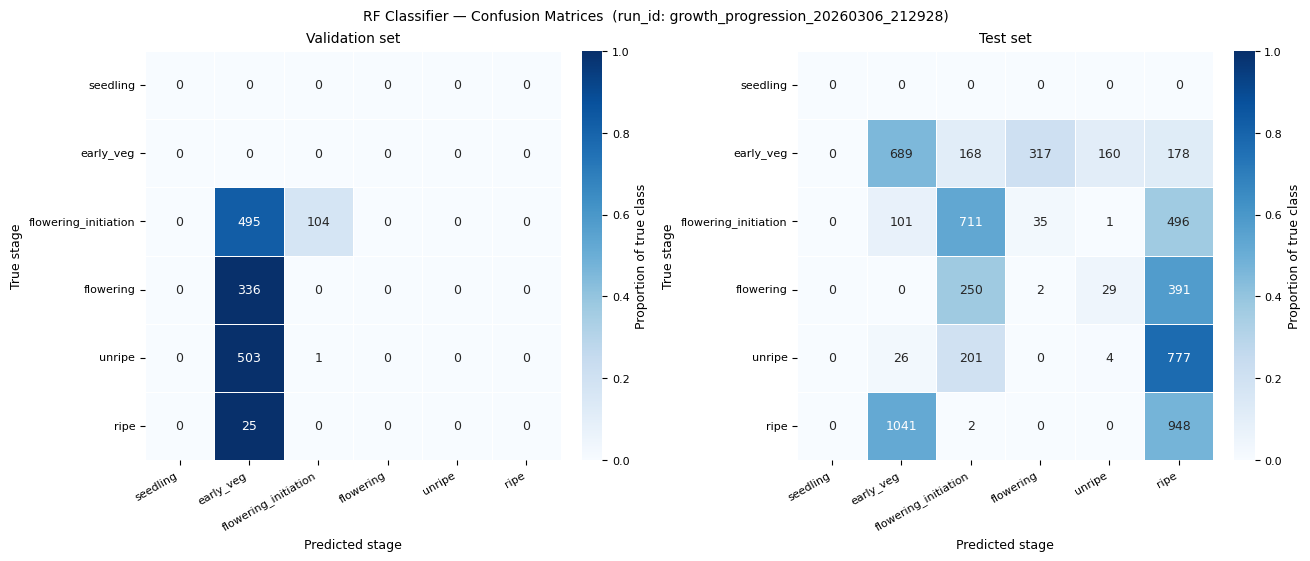

[M4] Confusion matrix figure ready → _fig_cm


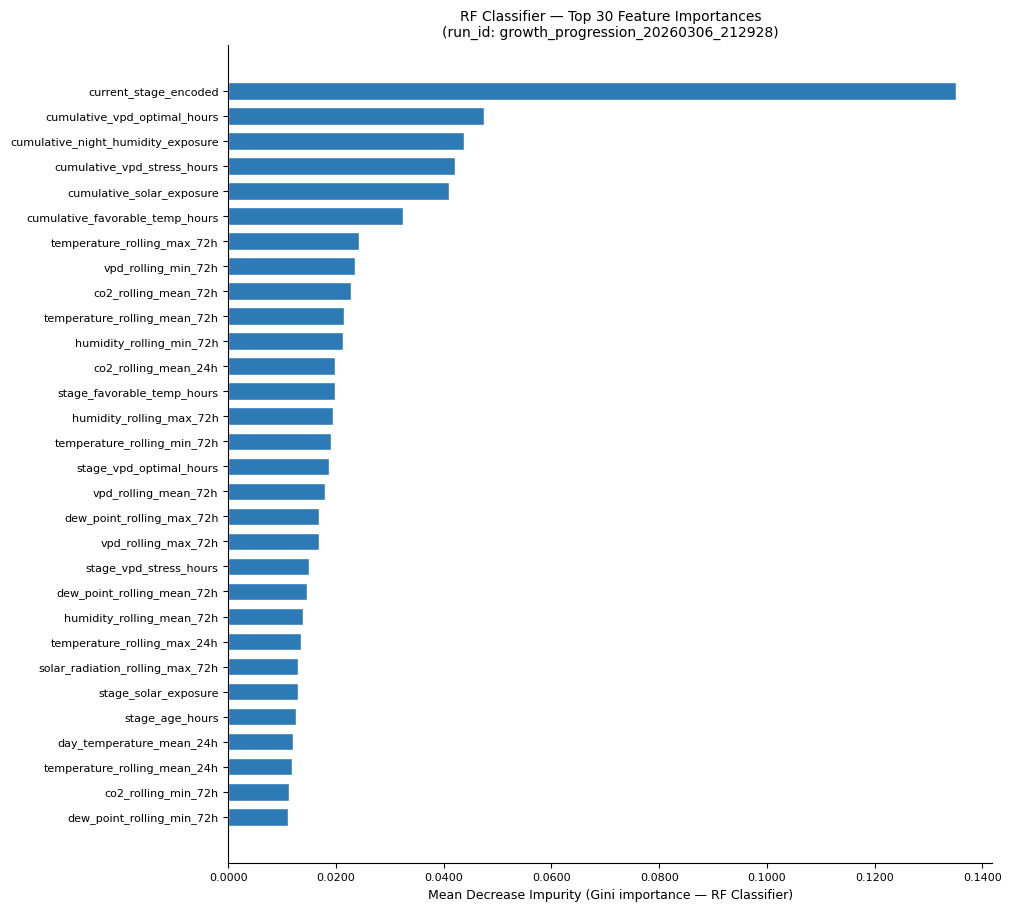

[M4] Feature importance figure ready → _fig_feat_imp


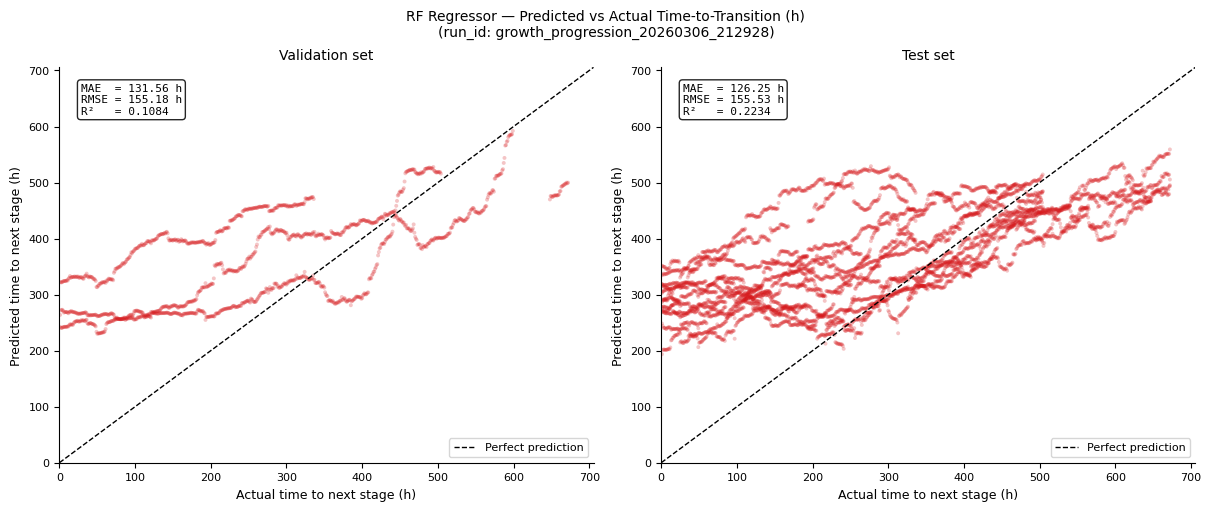

[M4] Regression scatter figure ready → _fig_reg


In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# M4 — Generate all evaluation plots.
#
# All figures stored as module-level variables so Section N can save them to
# disk without re-running computation.
#
# Figures produced:
#   _fig_cm       — Confusion matrices (val + test side-by-side subplots)
#   _fig_feat_imp — Feature importance horizontal bar (top 30 clf MDI features)
#   _fig_reg      — Regression scatter predicted vs actual (val + test subplots)
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Attempt to import seaborn for styled heatmap; fall back to raw imshow.
try:
    import seaborn as sns
    _HAS_SNS = True
except ImportError:
    _HAS_SNS = False
    print("[M4] seaborn not found — confusion matrix will use matplotlib imshow.")

matplotlib.rcParams.update({
    "figure.dpi":     100,
    "font.size":        9,
    "axes.titlesize":  10,
    "axes.labelsize":   9,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
})

# ── Confusion matrices ─────────────────────────────────────────────────────────
_fig_cm, (_ax_cm_val, _ax_cm_test) = plt.subplots(
    1, 2, figsize=(13, 5.5), constrained_layout=True
)
_fig_cm.suptitle(
    f"RF Classifier — Confusion Matrices  (run_id: {_RUN_ID})",
    fontsize=10,
)

for _ax_cm, _cm, _title_cm in [
    (_ax_cm_val,  _cm_val,  "Validation set"),
    (_ax_cm_test, _cm_test, "Test set"),
]:
    _cm_norm = _cm.astype(float) / np.maximum(_cm.sum(axis=1, keepdims=True), 1)
    if _HAS_SNS:
        sns.heatmap(
            _cm_norm,
            ax          = _ax_cm,
            annot       = _cm,         # annotate with raw counts
            fmt         = "d",
            cmap        = "Blues",
            xticklabels = _clf_label_names,
            yticklabels = _clf_label_names,
            vmin        = 0.0,
            vmax        = 1.0,
            linewidths  = 0.4,
            linecolor   = "white",
            cbar_kws    = {"label": "Proportion of true class"},
        )
    else:
        _im = _ax_cm.imshow(_cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
        plt.colorbar(_im, ax=_ax_cm, label="Proportion of true class")
        for _ri in range(len(_clf_labels)):
            for _ci in range(len(_clf_labels)):
                _ax_cm.text(_ci, _ri, str(_cm[_ri, _ci]),
                            ha="center", va="center", fontsize=7)
        _ax_cm.set_xticks(range(len(_clf_labels)))
        _ax_cm.set_xticklabels(_clf_label_names, rotation=30, ha="right")
        _ax_cm.set_yticks(range(len(_clf_labels)))
        _ax_cm.set_yticklabels(_clf_label_names, rotation=0)
    _ax_cm.set_title(_title_cm)
    _ax_cm.set_xlabel("Predicted stage")
    _ax_cm.set_ylabel("True stage")
    plt.setp(_ax_cm.get_xticklabels(), rotation=30, ha="right")
    plt.setp(_ax_cm.get_yticklabels(), rotation=0)

plt.show()
print("[M4] Confusion matrix figure ready → _fig_cm")

# ── Feature importance (top N) ─────────────────────────────────────────────────
_TOP_N_PLOT = 30
_fi_top = _feat_imp_clf_df.head(_TOP_N_PLOT).copy()

_fig_feat_imp, _ax_fi = plt.subplots(
    figsize=(10, max(6, _TOP_N_PLOT * 0.30)), constrained_layout=True
)
_ax_fi.barh(
    _fi_top["feature"].values[::-1],
    _fi_top["importance_clf"].values[::-1],
    color     = "#2c7bb6",
    edgecolor = "white",
    height    = 0.70,
)
_ax_fi.set_xlabel("Mean Decrease Impurity (Gini importance — RF Classifier)")
_ax_fi.set_title(
    f"RF Classifier — Top {_TOP_N_PLOT} Feature Importances\n(run_id: {_RUN_ID})"
)
_ax_fi.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
_ax_fi.spines[["top", "right"]].set_visible(False)
plt.show()
print("[M4] Feature importance figure ready → _fig_feat_imp")

# ── Regression scatter: predicted vs actual ────────────────────────────────────
_fig_reg, (_ax_reg_val, _ax_reg_test) = plt.subplots(
    1, 2, figsize=(12, 5), constrained_layout=True
)
_fig_reg.suptitle(
    f"RF Regressor — Predicted vs Actual Time-to-Transition (h)\n(run_id: {_RUN_ID})",
    fontsize=10,
)

for _ax_r, _y_true_r, _y_pred_r, _title_r, _met_r in [
    (_ax_reg_val,  y_rf_time_val,  _reg_pred_val,  "Validation set", _reg_val_metrics),
    (_ax_reg_test, y_rf_time_test, _reg_pred_test, "Test set",       _reg_test_metrics),
]:
    _lim = float(max(_y_true_r.max(), _y_pred_r.max())) * 1.05
    _ax_r.scatter(_y_true_r, _y_pred_r, alpha=0.25, s=8, color="#d7191c", edgecolors="none")
    _ax_r.plot([0, _lim], [0, _lim], "k--", lw=1.0, label="Perfect prediction")
    _ax_r.set_title(_title_r)
    _ax_r.set_xlabel("Actual time to next stage (h)")
    _ax_r.set_ylabel("Predicted time to next stage (h)")
    _ax_r.set_xlim(0, _lim)
    _ax_r.set_ylim(0, _lim)
    _ax_r.legend(fontsize=8)
    _ax_r.text(
        0.04, 0.96,
        f"MAE  = {_met_r['mae_h']:.2f} h\nRMSE = {_met_r['rmse_h']:.2f} h\nR²   = {_met_r['r2']:.4f}",
        transform=_ax_r.transAxes, va="top", ha="left",
        fontsize=8, family="monospace",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85),
    )
    _ax_r.spines[["top", "right"]].set_visible(False)

plt.show()
print("[M4] Regression scatter figure ready → _fig_reg")

## Section N — Baseline Artifact Saving

All RF baseline artifacts are saved to canonical AgriTwin-GH paths.

| Artifact | Path |
|---|---|
| RF Classifier `.pkl` | `src/agritwin_gh/models/growth_progression_rf_classifier_<run_id>.pkl` |
| RF Regressor `.pkl` | `src/agritwin_gh/models/growth_progression_rf_regressor_<run_id>.pkl` |
| `rf_feature_importance.csv` | `P_ARTIFACTS / rf_feature_importance.csv` |
| `rf_metrics.json` | `P_ARTIFACTS / rf_metrics.json` |
| `rf_confusion_matrix.png` | `P_ARTIFACTS / rf_confusion_matrix.png` |
| `rf_feature_importance.png` | `P_ARTIFACTS / rf_feature_importance.png` |
| `rf_regression_scatter.png` | `P_ARTIFACTS / rf_regression_scatter.png` |
| `rf_validation_summary.json` | `P_ARTIFACTS / rf_validation_summary.json` |

All saves are guarded by `CONFIG["save_artifacts"]`.

In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# N1 — Save RF classifier and regressor as joblib .pkl files.
#
# Saved to: P_MODELS_DIR / f"growth_progression_rf_{type}_{_RUN_ID}.pkl"
# Compress=3: good balance of speed and on-disk size.
# Round-trip verification: reload and predict one probe row to confirm
# the saved objects are loadable and produce the correct output shape.
# ─────────────────────────────────────────────────────────────────────────────
import joblib

_clf_model_path = P_MODELS_DIR / f"growth_progression_rf_classifier_{_RUN_ID}.pkl"
_reg_model_path = P_MODELS_DIR / f"growth_progression_rf_regressor_{_RUN_ID}.pkl"

if CONFIG.get("save_artifacts", True):
    joblib.dump(clf_rf, _clf_model_path, compress=3)
    _LOG.info("[N1] RF Classifier saved → %s", _clf_model_path)
    print(f"[N1] Saved RF classifier : {_clf_model_path}")

    joblib.dump(reg_rf, _reg_model_path, compress=3)
    _LOG.info("[N1] RF Regressor saved  → %s", _reg_model_path)
    print(f"[N1] Saved RF regressor  : {_reg_model_path}")

    # Round-trip verification
    _clf_rt = joblib.load(_clf_model_path)
    _reg_rt = joblib.load(_reg_model_path)
    _probe  = X_rf_val_scaled[:1]
    assert _clf_rt.predict(_probe).shape == (1,), "Classifier round-trip: shape mismatch."
    assert _reg_rt.predict(_probe).shape == (1,), "Regressor round-trip: shape mismatch."
    assert _clf_rt.n_estimators == RF_N_ESTIMATORS, "Classifier round-trip: n_estimators mismatch."
    assert _reg_rt.n_estimators == RF_N_ESTIMATORS, "Regressor round-trip: n_estimators mismatch."
    print("[N1] Round-trip verification PASSED for classifier and regressor.")
else:
    print("[N1] save_artifacts=False — model pkl files not written.")

21:30:22  INFO     growth_progression — [N1] RF Classifier saved → E:\AgriTwin-GH\src\agritwin_gh\models\growth_progression_rf_classifier_growth_progression_20260306_212928.pkl


[N1] Saved RF classifier : E:\AgriTwin-GH\src\agritwin_gh\models\growth_progression_rf_classifier_growth_progression_20260306_212928.pkl


21:30:23  INFO     growth_progression — [N1] RF Regressor saved  → E:\AgriTwin-GH\src\agritwin_gh\models\growth_progression_rf_regressor_growth_progression_20260306_212928.pkl


[N1] Saved RF regressor  : E:\AgriTwin-GH\src\agritwin_gh\models\growth_progression_rf_regressor_growth_progression_20260306_212928.pkl
[N1] Round-trip verification PASSED for classifier and regressor.


In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# N2 — Save rf_feature_importance.csv and rf_metrics.json.
#
# rf_feature_importance.csv:
#   Full feature list sorted by classifier MDI importance (desc).
#   Columns: feature, importance_clf, importance_reg, rank_clf
#
# rf_metrics.json:
#   Structured numeric metrics for both sub-tasks on val and test splits.
#   Confusion matrix stored as nested list (JSON-serialisable).
#   classification_report per-stage breakdown included.
# ─────────────────────────────────────────────────────────────────────────────
import json
import datetime as _dt  # ensure available (imported in J4 — re-declare for safety)

if CONFIG.get("save_artifacts", True):
    # ── rf_feature_importance.csv ──────────────────────────────────────────────
    _fi_csv_path = P_ARTIFACTS / "rf_feature_importance.csv"
    _feat_imp_clf_df.to_csv(_fi_csv_path, index=False)
    _LOG.info("[N2] Feature importance CSV saved → %s  (%d rows)", _fi_csv_path, len(_feat_imp_clf_df))
    print(f"[N2] Saved: {_fi_csv_path}")

    # ── rf_metrics.json ────────────────────────────────────────────────────────
    _rf_metrics_doc = {
        "run_id":     _RUN_ID,
        "created_at": _dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",
        "model": {
            "classifier": {
                "class":          "RandomForestClassifier",
                "n_estimators":   RF_N_ESTIMATORS,
                "max_depth":      RF_MAX_DEPTH,
                "class_weight":   RF_CLASS_WEIGHT,
                "max_features":   RF_MAX_FEATURES,
                "random_state":   RF_RANDOM_STATE,
                "oob_accuracy":   float(clf_rf.oob_score_),
                "train_time_sec": round(_clf_train_sec, 2),
            },
            "regressor": {
                "class":          "RandomForestRegressor",
                "n_estimators":   RF_N_ESTIMATORS,
                "max_depth":      RF_MAX_DEPTH,
                "max_features":   RF_MAX_FEATURES,
                "random_state":   RF_RANDOM_STATE,
                "oob_r2":         float(reg_rf.oob_score_),
                "train_time_sec": round(_reg_train_sec, 2),
            },
        },
        "classifier": {
            "val":  _clf_val_metrics,
            "test": _clf_test_metrics,
        },
        "regressor": {
            "val":  _reg_val_metrics,
            "test": _reg_test_metrics,
        },
    }

    _metrics_path = P_ARTIFACTS / "rf_metrics.json"
    with open(_metrics_path, "w", encoding="utf-8") as _fh:
        json.dump(_rf_metrics_doc, _fh, indent=2)
    _LOG.info("[N2] rf_metrics.json saved → %s", _metrics_path)
    print(f"[N2] Saved: {_metrics_path}")
else:
    print("[N2] save_artifacts=False — CSV/JSON not written.")

21:30:24  INFO     growth_progression — [N2] Feature importance CSV saved → E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\rf_feature_importance.csv  (193 rows)
21:30:24  INFO     growth_progression — [N2] rf_metrics.json saved → E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\rf_metrics.json


[N2] Saved: E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\rf_feature_importance.csv
[N2] Saved: E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\rf_metrics.json


In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# N3 — Save evaluation plot figures to P_ARTIFACTS as PNG.
#
# Figure objects were created and displayed inline in Section M5.
# They remain in memory and are saved here at 150 dpi with tight bounding.
#
# Files saved:
#   rf_confusion_matrix.png    — val + test confusion matrix subplots
#   rf_feature_importance.png  — top-30 MDI feature importance bar chart
#   rf_regression_scatter.png  — predicted vs actual scatter (val + test)
# ─────────────────────────────────────────────────────────────────────────────
if CONFIG.get("save_artifacts", True):
    _plot_registry = {
        "rf_confusion_matrix.png":   _fig_cm,
        "rf_feature_importance.png": _fig_feat_imp,
        "rf_regression_scatter.png": _fig_reg,
    }
    for _plot_fname, _fig_obj in _plot_registry.items():
        _out_path = P_ARTIFACTS / _plot_fname
        _fig_obj.savefig(_out_path, dpi=150, bbox_inches="tight")
        _LOG.info("[N4] Plot saved → %s", _out_path)
        print(f"[N4] Saved: {_out_path}")
else:
    print("[N3] save_artifacts=False — plot PNG files not written.")

21:30:24  INFO     growth_progression — [N4] Plot saved → E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\rf_confusion_matrix.png


[N4] Saved: E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\rf_confusion_matrix.png


21:30:25  INFO     growth_progression — [N4] Plot saved → E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\rf_feature_importance.png


[N4] Saved: E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\rf_feature_importance.png


21:30:26  INFO     growth_progression — [N4] Plot saved → E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\rf_regression_scatter.png


[N4] Saved: E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\rf_regression_scatter.png


In [51]:
# ─────────────────────────────────────────────────────────────────────────────
# N4 — Save rf_validation_summary.json and print Section N completion summary.
#
# rf_validation_summary.json is the human-readable interpretation layer:
#   • Headline metric table for classifier and regressor (val + test)
#   • Per-stage F1 breakdown on validation set
#   • Top-10 features by classifier MDI importance
#   • Hyperparameter snapshot
#   • Full artifact path index for downstream reference
#   • Notes anchoring the LSTM comparison bar
# ─────────────────────────────────────────────────────────────────────────────
_top10_feats_for_summary = (
    _feat_imp_clf_df.head(10)[["feature", "importance_clf"]]
    .assign(importance_clf=lambda _d: _d["importance_clf"].round(6))
    .to_dict(orient="records")
)

_val_summary_doc = {
    "run_id":     _RUN_ID,
    "created_at": _dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "headline": {
        "classifier": {
            "val_accuracy":     round(_clf_val_metrics["accuracy"],        4),
            "val_f1_macro":     round(_clf_val_metrics["f1_macro"],        4),
            "val_f1_weighted":  round(_clf_val_metrics["f1_weighted"],     4),
            "test_accuracy":    round(_clf_test_metrics["accuracy"],       4),
            "test_f1_macro":    round(_clf_test_metrics["f1_macro"],       4),
            "test_f1_weighted": round(_clf_test_metrics["f1_weighted"],    4),
        },
        "regressor": {
            "val_mae_h":   round(_reg_val_metrics["mae_h"],   2),
            "val_rmse_h":  round(_reg_val_metrics["rmse_h"],  2),
            "val_r2":      round(_reg_val_metrics["r2"],      4),
            "test_mae_h":  round(_reg_test_metrics["mae_h"],  2),
            "test_rmse_h": round(_reg_test_metrics["rmse_h"], 2),
            "test_r2":     round(_reg_test_metrics["r2"],     4),
        },
    },
    "per_stage_clf_f1_val": {
        _k: round(_v.get("f1-score", 0.0), 4)
        for _k, _v in _clf_val_metrics.get("classification_report", {}).items()
        if isinstance(_v, dict)
    },
    "top_10_features_by_clf_importance": _top10_feats_for_summary,
    "hyperparameters": {
        "n_estimators":      RF_N_ESTIMATORS,
        "max_depth":         RF_MAX_DEPTH,
        "min_samples_split": RF_MIN_SAMPLES_SPLIT,
        "min_samples_leaf":  RF_MIN_SAMPLES_LEAF,
        "max_features":      RF_MAX_FEATURES,
        "class_weight":      RF_CLASS_WEIGHT,
        "random_state":      RF_RANDOM_STATE,
    },
    "artifacts": {
        "classifier_pkl":         str(_clf_model_path),
        "regressor_pkl":          str(_reg_model_path),
        "feature_importance_csv": str(P_ARTIFACTS / "rf_feature_importance.csv"),
        "metrics_json":           str(P_ARTIFACTS / "rf_metrics.json"),
        "confusion_matrix_png":   str(P_ARTIFACTS / "rf_confusion_matrix.png"),
        "feature_importance_png": str(P_ARTIFACTS / "rf_feature_importance.png"),
        "regression_scatter_png": str(P_ARTIFACTS / "rf_regression_scatter.png"),
    },
    "notes": (
        "RF baseline established using class_weight='balanced' to compensate for "
        "stage-transition imbalance. Feature importances (MDI/Gini) identify the "
        "dominant sensor signals. LSTM evaluation should use val_f1_macro "
        "(classifier) and val_mae_h (regressor) as the minimum performance bar."
    ),
}

if CONFIG.get("save_artifacts", True):
    _vs_path = P_ARTIFACTS / "rf_validation_summary.json"
    with open(_vs_path, "w", encoding="utf-8") as _fh:
        json.dump(_val_summary_doc, _fh, indent=2)
    _LOG.info("[N4] rf_validation_summary.json saved → %s", _vs_path)
    print(f"[N4] Saved: {_vs_path}")
else:
    print("[N4] save_artifacts=False — validation summary not written.")

# ── Section N completion summary ───────────────────────────────────────────────
print()
print("=" * 72)
print(f"  SECTION N — COMPLETE  |  run_id : {_RUN_ID}")
print("=" * 72)
print()
print("  SAVED ARTIFACTS")
print(f"  {'File':<57}  {'Location'}")
print(f"  {'-'*57}  {'-'*14}")
for _fname_n, _dir_n in [
    (f"growth_progression_rf_classifier_{_RUN_ID}.pkl", "P_MODELS_DIR"),
    (f"growth_progression_rf_regressor_{_RUN_ID}.pkl",  "P_MODELS_DIR"),
    ("rf_feature_importance.csv",                        "P_ARTIFACTS"),
    ("rf_metrics.json",                                  "P_ARTIFACTS"),
    ("rf_confusion_matrix.png",                          "P_ARTIFACTS"),
    ("rf_feature_importance.png",                        "P_ARTIFACTS"),
    ("rf_regression_scatter.png",                        "P_ARTIFACTS"),
    ("rf_validation_summary.json",                       "P_ARTIFACTS"),
]:
    print(f"  {_fname_n:<57}  {_dir_n}")
print()
print("  READY FOR SECTION O — BASELINE COMPARISON SEED")
print("=" * 72)

21:30:26  INFO     growth_progression — [N4] rf_validation_summary.json saved → E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\rf_validation_summary.json


[N4] Saved: E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\rf_validation_summary.json

  SECTION N — COMPLETE  |  run_id : growth_progression_20260306_212928

  SAVED ARTIFACTS
  File                                                       Location
  ---------------------------------------------------------  --------------
  growth_progression_rf_classifier_growth_progression_20260306_212928.pkl  P_MODELS_DIR
  growth_progression_rf_regressor_growth_progression_20260306_212928.pkl  P_MODELS_DIR
  rf_feature_importance.csv                                  P_ARTIFACTS
  rf_metrics.json                                            P_ARTIFACTS
  rf_confusion_matrix.png                                    P_ARTIFACTS
  rf_feature_importance.png                                  P_ARTIFACTS
  rf_regression_scatter.png                                  P_ARTIFACTS
  rf_validation_summary.json                                 P_ARTIFACTS

  READY FOR SECTION O — BAS

## Section O — Baseline Summary for Later Comparison

`baseline_comparison_seed.json` is the canonical handoff artifact between the RF baseline sections and any future model evaluation (LSTM, CatBoost, etc.).

It captures a **concise, structured snapshot** that any comparison script can load directly:

| Field group | Contents |
|---|---|
| `next_stage_classification` | val + test accuracy, F1 macro, F1 weighted, precision, recall |
| `time_to_transition_regression` | val + test MAE (h), RMSE (h), R² |
| `top_10_features_by_clf_importance` | sorted feature list with MDI values |
| `hyperparameters` | full RF config for reproducibility |
| `model_paths` | resolved paths to `.pkl` files |
| `comparison_notes` | explicit minimum performance bar + interpretation notes |

Saved to: `P_ARTIFACTS / "baseline_comparison_seed.json"`

In [52]:
# ─────────────────────────────────────────────────────────────────────────────
# O1 — Save baseline_comparison_seed.json.
#
# This file is the canonical handoff between RF baseline sections and any
# future model comparison (LSTM etc.).  Comparison scripts should load this
# file to retrieve the RF performance bar without re-running the notebook.
# ─────────────────────────────────────────────────────────────────────────────
_baseline_seed = {
    "run_id":     _RUN_ID,
    "created_at": _dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "baseline_model":  "RandomForest",
    "sklearn_version": __import__("sklearn").__version__,

    # ── Next-stage classification ──────────────────────────────────────────────
    "next_stage_classification": {
        "val": {
            "accuracy":        round(_clf_val_metrics["accuracy"],        4),
            "f1_macro":        round(_clf_val_metrics["f1_macro"],        4),
            "f1_weighted":     round(_clf_val_metrics["f1_weighted"],     4),
            "precision_macro": round(_clf_val_metrics["precision_macro"], 4),
            "recall_macro":    round(_clf_val_metrics["recall_macro"],    4),
        },
        "test": {
            "accuracy":        round(_clf_test_metrics["accuracy"],        4),
            "f1_macro":        round(_clf_test_metrics["f1_macro"],        4),
            "f1_weighted":     round(_clf_test_metrics["f1_weighted"],     4),
            "precision_macro": round(_clf_test_metrics["precision_macro"], 4),
            "recall_macro":    round(_clf_test_metrics["recall_macro"],    4),
        },
    },

    # ── Time-to-transition regression ─────────────────────────────────────────
    "time_to_transition_regression": {
        "val": {
            "mae_h":  round(_reg_val_metrics["mae_h"],  2),
            "rmse_h": round(_reg_val_metrics["rmse_h"], 2),
            "r2":     round(_reg_val_metrics["r2"],     4),
        },
        "test": {
            "mae_h":  round(_reg_test_metrics["mae_h"],  2),
            "rmse_h": round(_reg_test_metrics["rmse_h"], 2),
            "r2":     round(_reg_test_metrics["r2"],     4),
        },
    },

    # ── Top 10 features ────────────────────────────────────────────────────────
    "top_10_features_by_clf_importance": (
        _feat_imp_clf_df.head(10)[["feature", "importance_clf"]]
        .assign(importance_clf=lambda _d: _d["importance_clf"].round(6))
        .to_dict(orient="records")
    ),

    # ── Hyperparameter snapshot ────────────────────────────────────────────────
    "hyperparameters": {
        "n_estimators":      RF_N_ESTIMATORS,
        "max_depth":         RF_MAX_DEPTH,
        "min_samples_split": RF_MIN_SAMPLES_SPLIT,
        "min_samples_leaf":  RF_MIN_SAMPLES_LEAF,
        "max_features":      RF_MAX_FEATURES,
        "class_weight":      RF_CLASS_WEIGHT,
        "random_state":      RF_RANDOM_STATE,
    },

    # ── Resolved model paths ───────────────────────────────────────────────────
    "model_paths": {
        "classifier": str(_clf_model_path),
        "regressor":  str(_reg_model_path),
    },

    # ── Comparison context ─────────────────────────────────────────────────────
    "comparison_notes": {
        "minimum_bar_clf_f1_macro": round(_clf_val_metrics["f1_macro"], 4),
        "minimum_bar_reg_mae_h":    round(_reg_val_metrics["mae_h"],    2),
        "interpretation": (
            "LSTM must exceed RF val_f1_macro (classifier) and achieve lower "
            "val_mae_h (regressor) to justify the added sequence complexity. "
            "RF feature importances identify the most predictive signals — "
            "LSTM attention or gradient interpretability output should be compared "
            "against these rankings to validate or refute the temporal hypothesis."
        ),
        "feature_hypothesis": (
            "Rolling stats (24h, 72h windows) and stage-history features are "
            "expected to carry the highest MDI weight, consistent with the "
            "biological hypothesis that sustained environmental exposure, rather "
            "than point-in-time readings, drives growth stage transitions."
        ),
    },
}

if CONFIG.get("save_artifacts", True):
    _seed_path = P_ARTIFACTS / "baseline_comparison_seed.json"
    with open(_seed_path, "w", encoding="utf-8") as _fh:
        json.dump(_baseline_seed, _fh, indent=2)
    _LOG.info(
        "[O1] baseline_comparison_seed.json saved → %s  "
        "(clf_val_f1_macro=%.4f, reg_val_mae=%.2fh)",
        _seed_path,
        _baseline_seed["next_stage_classification"]["val"]["f1_macro"],
        _baseline_seed["time_to_transition_regression"]["val"]["mae_h"],
    )
    print(f"[O1] Saved: {_seed_path}")
else:
    print("[O1] save_artifacts=False — baseline_comparison_seed.json not written.")

# ── Section O final summary──────────────────────────────────────────────────
print()
print("=" * 72)
print(f"  SECTION O — COMPLETE  |  run_id : {_RUN_ID}")
print("=" * 72)
print()
_clf_v = _baseline_seed["next_stage_classification"]["val"]
_clf_t = _baseline_seed["next_stage_classification"]["test"]
_reg_v = _baseline_seed["time_to_transition_regression"]["val"]
_reg_t = _baseline_seed["time_to_transition_regression"]["test"]

print("  RF BASELINE PERFORMANCE SUMMARY")
print(f"  {'Metric':<46}  {'Val':>8}  {'Test':>8}")
print(f"  {'-'*46}  {'-'*8}  {'-'*8}")
print(f"  {'Classifier — Accuracy':<46}  {_clf_v['accuracy']:>8.4f}  {_clf_t['accuracy']:>8.4f}")
print(f"  {'Classifier — F1 macro':<46}  {_clf_v['f1_macro']:>8.4f}  {_clf_t['f1_macro']:>8.4f}")
print(f"  {'Classifier — F1 weighted':<46}  {_clf_v['f1_weighted']:>8.4f}  {_clf_t['f1_weighted']:>8.4f}")
print(f"  {'Regressor  — MAE (h)':<46}  {_reg_v['mae_h']:>8.2f}  {_reg_t['mae_h']:>8.2f}")
print(f"  {'Regressor  — RMSE (h)':<46}  {_reg_v['rmse_h']:>8.2f}  {_reg_t['rmse_h']:>8.2f}")
print(f"  {'Regressor  — R²':<46}  {_reg_v['r2']:>8.4f}  {_reg_t['r2']:>8.4f}")
print()
print("  MINIMUM PERFORMANCE BAR FOR LSTM COMPARISON")
print(f"    Classifier  val_f1_macro  > {_baseline_seed['comparison_notes']['minimum_bar_clf_f1_macro']:.4f}")
print(f"    Regressor   val_mae_h     < {_baseline_seed['comparison_notes']['minimum_bar_reg_mae_h']:.2f} h")
print()
print(f"  Seed artifact : {_seed_path.name}")
print()
print("  NEXT: Section P — LSTM Architecture and Training")
print("=" * 72)

21:30:26  INFO     growth_progression — [O1] baseline_comparison_seed.json saved → E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\baseline_comparison_seed.json  (clf_val_f1_macro=0.0591, reg_val_mae=131.56h)


[O1] Saved: E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\baseline_comparison_seed.json

  SECTION O — COMPLETE  |  run_id : growth_progression_20260306_212928

  RF BASELINE PERFORMANCE SUMMARY
  Metric                                               Val      Test
  ----------------------------------------------  --------  --------
  Classifier — Accuracy                             0.0710    0.3607
  Classifier — F1 macro                             0.0591    0.2695
  Classifier — F1 weighted                          0.1209    0.3266
  Regressor  — MAE (h)                              131.56    126.25
  Regressor  — RMSE (h)                             155.18    155.53
  Regressor  — R²                                   0.1084    0.2234

  MINIMUM PERFORMANCE BAR FOR LSTM COMPARISON
    Classifier  val_f1_macro  > 0.0591
    Regressor   val_mae_h     < 131.56 h

  Seed artifact : baseline_comparison_seed.json

  NEXT: Section P — LSTM Architecture a

## Section P — LSTM Modeling Design

### Architecture rationale

LSTM is the primary model (GRU is explicitly not used here) because:

- Tomato growth stage transitions are driven by **sustained environmental exposure** across 24–72 h windows, requiring selective long-range memory.
- LSTM's **explicit forget gate** allows the model to learn when to discard early-window sensor readings — biologically aligned with stage-plateau dynamics.
- GRU collapses the forget and input gates into a single reset gate; appropriate for shorter sequences but less interpretable for stage-boundary modelling at 72-hour resolution.

### Architecture overview

```
Input(window_N, n_features)
  → LSTM_1(LSTM_UNITS_1, return_sequences=[True if n_layers>1])
  → [LSTM_2(LSTM_UNITS_2) if n_layers > 1]
  → Dense(LSTM_DENSE_HIDDEN, relu)   ← shared backbone
  → Dropout(LSTM_DROPOUT)
  ┌─────────────────────────────────────────────┐
  │  Head A: Dense(n_classes, softmax)          │  → next_stage_int
  │  Head B: Dense(1, linear) + denorm          │  → time_to_next_stage_hours
  └─────────────────────────────────────────────┘
```

### Loss functions

| Head | Loss | Justification |
|---|---|---|
| Classifier | `SparseCategoricalCrossentropy` | Targets are integer-encoded class indices |
| Regressor | `Huber(δ=1.0)` | Robust to large-error outliers from long-transition stages |

Training targets for the regression head are **z-score normalised** (train stats only) to [mean≈0, std≈1]. Predictions are denormalised back to hours before any metric is computed.

Sample weights (balanced class distribution) are computed from training classification labels and passed to `model.fit()` to compensate for stage-transition imbalance across both heads simultaneously.

In [53]:
# ─────────────────────────────────────────────────────────────────────────────
# P1 — LSTM hyperparameter config: extract from CONFIG["lstm_params"] with safe
# defaults.  All values flow through CONFIG so a single YAML change is the
# only modification needed to retrain with different architecture settings.
# ─────────────────────────────────────────────────────────────────────────────

_lstm_cfg = CONFIG.get("lstm_params", {})

# Architecture
LSTM_UNITS_1           = int(_lstm_cfg.get("units_1",               128))
LSTM_UNITS_2           = int(_lstm_cfg.get("units_2",                64))
LSTM_N_LAYERS          = int(_lstm_cfg.get("n_layers",                 2))   # 1 or 2
LSTM_DROPOUT           = float(_lstm_cfg.get("dropout",              0.30))
LSTM_RECURRENT_DROPOUT = float(_lstm_cfg.get("recurrent_dropout",    0.00))
LSTM_DENSE_HIDDEN      = int(_lstm_cfg.get("dense_hidden",            64))

# Training schedule
LSTM_LR                = float(_lstm_cfg.get("learning_rate",       1e-3))
LSTM_BATCH_SIZE        = int(_lstm_cfg.get("batch_size",              64))
LSTM_EPOCHS            = int(_lstm_cfg.get("epochs",                 100))
LSTM_PATIENCE          = int(_lstm_cfg.get("patience",                15))

# ReduceLROnPlateau (disabled if patience=0)
LSTM_REDUCE_LR_PATIENCE = int(_lstm_cfg.get("reduce_lr_patience",     7))
LSTM_REDUCE_LR_FACTOR   = float(_lstm_cfg.get("reduce_lr_factor",   0.5))
LSTM_REDUCE_LR_MIN_LR   = float(_lstm_cfg.get("reduce_lr_min_lr",  1e-6))

# Multi-task loss weights
LSTM_CLF_WEIGHT = float(_lstm_cfg.get("clf_loss_weight", 1.0))
LSTM_REG_WEIGHT = float(_lstm_cfg.get("reg_loss_weight", 0.1))

print("[P1] LSTM hyperparameter config  (source: CONFIG[\"lstm_params\"]):")
print(f"     {'units_1':<24}: {LSTM_UNITS_1}")
print(f"     {'units_2':<24}: {LSTM_UNITS_2}  (ignored if n_layers=1)")
print(f"     {'n_layers':<24}: {LSTM_N_LAYERS}")
print(f"     {'dropout':<24}: {LSTM_DROPOUT}")
print(f"     {'recurrent_dropout':<24}: {LSTM_RECURRENT_DROPOUT}")
print(f"     {'dense_hidden':<24}: {LSTM_DENSE_HIDDEN}")
print(f"     {'learning_rate':<24}: {LSTM_LR}")
print(f"     {'batch_size':<24}: {LSTM_BATCH_SIZE}")
print(f"     {'epochs':<24}: {LSTM_EPOCHS}")
print(f"     {'patience':<24}: {LSTM_PATIENCE}")
print(f"     {'reduce_lr_patience':<24}: {LSTM_REDUCE_LR_PATIENCE}")
print(f"     {'clf_loss_weight':<24}: {LSTM_CLF_WEIGHT}")
print(f"     {'reg_loss_weight':<24}: {LSTM_REG_WEIGHT}")
print()
print(f"[P1] LSTM input dimensions:")
print(f"     Sequence length (window_N) : {X_lstm_train_scaled.shape[1]}")
print(f"     n_features                 : {X_lstm_train_scaled.shape[2]}")
print(f"     n_classes                  : {len(label_enc_stage.classes_)}")

[P1] LSTM hyperparameter config  (source: CONFIG["lstm_params"]):
     units_1                 : 128
     units_2                 : 64  (ignored if n_layers=1)
     n_layers                : 2
     dropout                 : 0.25
     recurrent_dropout       : 0.0
     dense_hidden            : 64
     learning_rate           : 0.001
     batch_size              : 64
     epochs                  : 100
     patience                : 15
     reduce_lr_patience      : 7
     clf_loss_weight         : 1.0
     reg_loss_weight         : 0.1

[P1] LSTM input dimensions:
     Sequence length (window_N) : 72
     n_features                 : 193
     n_classes                  : 6


In [54]:
# ─────────────────────────────────────────────────────────────────────────────
# P2 — Regression target normalisation + LSTM model build + compile.
#
# Regression normalisation (z-score, train statistics only):
#   Necessary because the LSTM regression head uses a linear output neuron.
#   Raw hour targets (range ~1–500 h) would drive large gradient magnitudes
#   relative to the classification loss.  Normalisation brings both heads
#   to a comparable gradient scale.  All metrics are reported in raw hours
#   (denormalised) throughout Sections R and T.
#
# Model: Keras Functional API — shared backbone, two named output heads.
# ─────────────────────────────────────────────────────────────────────────────
import tensorflow as tf
from sklearn.utils.class_weight import compute_sample_weight

# ── Regression target normalisation (train stats only) ────────────────────────
_y_time_mean = float(y_lstm_time_train.mean())
_y_time_std  = max(float(y_lstm_time_train.std()), 1e-6)   # guard div-by-zero

y_lstm_time_train_norm = ((y_lstm_time_train - _y_time_mean) / _y_time_std).astype("float32")
y_lstm_time_val_norm   = ((y_lstm_time_val   - _y_time_mean) / _y_time_std).astype("float32")
y_lstm_time_test_norm  = ((y_lstm_time_test  - _y_time_mean) / _y_time_std).astype("float32")

print("[P2] Regression target normalisation (hours → z-score):")
print(f"     Train: mean={_y_time_mean:.2f} h  std={_y_time_std:.2f} h")
print(f"     Train norm range : [{y_lstm_time_train_norm.min():.3f},  {y_lstm_time_train_norm.max():.3f}]")

# ── Balanced sample weights from training class distribution ──────────────────
_lstm_sample_weights = compute_sample_weight("balanced", y_lstm_stage_train_enc)
print(f"\n[P2] Sample weights  (balanced, from training stage distribution):")
print(f"     min={_lstm_sample_weights.min():.4f}  max={_lstm_sample_weights.max():.4f}  "
      f"mean={_lstm_sample_weights.mean():.4f}")

# ── LSTM model (Functional API) ───────────────────────────────────────────────
_n_feat    = X_lstm_train_scaled.shape[2]    # == len(FEATURE_COLS)
_n_classes = len(label_enc_stage.classes_)   # == 6
_seq_len   = X_lstm_train_scaled.shape[1]    # == CONFIG["window_N"]

tf.random.set_seed(CONFIG.get("seed", 42))

_inputs = tf.keras.Input(shape=(_seq_len, _n_feat), name="sensor_window")

# LSTM layer 1
_x = tf.keras.layers.LSTM(
    LSTM_UNITS_1,
    return_sequences = (LSTM_N_LAYERS > 1),
    dropout          = LSTM_DROPOUT,
    recurrent_dropout = LSTM_RECURRENT_DROPOUT,
    name             = "lstm_1",
)(_inputs)

# LSTM layer 2 (optional)
if LSTM_N_LAYERS > 1:
    _x = tf.keras.layers.LSTM(
        LSTM_UNITS_2,
        return_sequences  = False,
        dropout           = LSTM_DROPOUT,
        recurrent_dropout = LSTM_RECURRENT_DROPOUT,
        name              = "lstm_2",
    )(_x)

# Shared dense backbone
_x = tf.keras.layers.Dense(LSTM_DENSE_HIDDEN, activation="relu", name="shared_dense")(_x)
_x = tf.keras.layers.Dropout(LSTM_DROPOUT, name="shared_dropout")(_x)

# Output heads
_clf_out = tf.keras.layers.Dense(_n_classes, activation="softmax", name="next_stage")(_x)
_reg_out = tf.keras.layers.Dense(1,          activation="linear",  name="time_to_transition")(_x)

lstm_model = tf.keras.Model(
    inputs  = _inputs,
    outputs = [_clf_out, _reg_out],
    name    = "growth_progression_lstm",
)

# ── Compile ───────────────────────────────────────────────────────────────────
lstm_model.compile(
    optimizer    = tf.keras.optimizers.Adam(learning_rate=LSTM_LR),
    loss         = {
        "next_stage":         tf.keras.losses.SparseCategoricalCrossentropy(),
        "time_to_transition": tf.keras.losses.Huber(delta=1.0),
    },
    loss_weights = {
        "next_stage":         LSTM_CLF_WEIGHT,
        "time_to_transition": LSTM_REG_WEIGHT,
    },
    metrics      = {
        "next_stage":         [tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
        "time_to_transition": [tf.keras.metrics.MeanAbsoluteError(name="mae")],
    },
)

_total_params = lstm_model.count_params()
print(f"\n[P2] LSTM model built and compiled.")
print(f"     Input shape  : (batch, {_seq_len}, {_n_feat})")
print(f"     Output heads : next_stage (softmax, {_n_classes} classes) + "
      f"time_to_transition (linear, normalised)")
print(f"     Total params : {_total_params:,}")
lstm_model.summary(line_length=90, expand_nested=True)

[P2] Regression target normalisation (hours → z-score):
     Train: mean=285.65 h  std=178.07 h
     Train norm range : [-1.599,  2.170]

[P2] Sample weights  (balanced, from training stage distribution):
     min=0.7874  max=1.7717  mean=1.0000

[P2] LSTM model built and compiled.
     Input shape  : (batch, 72, 193)
     Output heads : next_stage (softmax, 6 classes) + time_to_transition (linear, normalised)
     Total params : 218,887


Model: "growth_progression_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ sensor_window            │ (None, 72, 193)      │            0 │ -                     │
│ (InputLayer)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ lstm_1 (LSTM)            │ (None, 72, 128)      │      164,864 │ sensor_window[0][0]   │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ lstm_2 (LSTM)            │ (None, 64)           │       49,408 │ lstm_1[0][0]          │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ shared_dense (Dense)     │ (None, 64)           │        4,160 │ lstm_2[0][0]          │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ shared_dropout (Dropout) │ (None, 64)           │            0 │ shared_dense[0][0]    │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ next_stage (Dense)       │ (None, 6)            │          390 │ shared_dropout[0][0]  │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ time_to_transition       │ (None, 1)            │           65 │ shared_dropout[0][0]  │
│ (Dense)                  │                      │              │                       │
└──────────────────────────┴──────────────────────┴──────────────┴───────────────────────┘

 Total params: 218,887 (855.03 KB)

 Trainable params: 218,887 (855.03 KB)

 Non-trainable params: 0 (0.00 B)

## Section Q — LSTM Training

### Callback stack

| Callback | Monitor | Trigger |
|---|---|---|
| `EarlyStopping` | `val_loss` | Stops if no improvement for `patience` epochs; restores best weights |
| `ModelCheckpoint` | `val_loss` | Saves complete `.keras` model whenever val_loss improves |
| `CSVLogger` | — | Writes per-epoch metrics to `lstm_training_history.csv` |
| `ReduceLROnPlateau` | `val_loss` | Reduces LR by `reduce_lr_factor` after `reduce_lr_patience` stagnant epochs |

### Training discipline

- `shuffle=False` — preserves chronological row order within each epoch. The data is already split chronologically before training starts so within-epoch order does not re-introduce temporal leakage, but disabling shuffle is an additional safety guarantee and is documented here for report reproducibility.
- `sample_weight=_lstm_sample_weights` — per-sample balanced weights computed from training classification labels; applied uniformly across both output heads.
- Validation data uses `X_rf_val_scaled` / `y_lstm_*_val` — never seen during `fit()`.

In [55]:
# ─────────────────────────────────────────────────────────────────────────────
# Q1 — Training callbacks.
#
# _lstm_ckpt_path: Best model is written here whenever val_loss improves.
#   This is the source used by T2 to save the final production model.
#   Saved as .keras format (TF 2.12+ native format, architecture + weights).
#
# _lstm_csv_log_path: Per-epoch training metrics.
#   Consumed by Q4 (inline plots) and saved as-is to P_ARTIFACTS in T2.
# ─────────────────────────────────────────────────────────────────────────────
import time  # ensure available

_lstm_ckpt_path    = str(P_ARTIFACTS / f"lstm_best_checkpoint_{_RUN_ID}.keras")
_lstm_csv_log_path = str(P_ARTIFACTS / "lstm_training_history.csv")

_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor              = "val_loss",
        patience             = LSTM_PATIENCE,
        restore_best_weights = True,
        verbose              = 1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath         = _lstm_ckpt_path,
        monitor          = "val_loss",
        save_best_only   = True,
        save_weights_only= False,
        verbose          = 1,
    ),
    tf.keras.callbacks.CSVLogger(
        filename  = _lstm_csv_log_path,
        append    = False,
        separator = ",",
    ),
]

if LSTM_REDUCE_LR_PATIENCE > 0:
    _callbacks.append(
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor  = "val_loss",
            factor   = LSTM_REDUCE_LR_FACTOR,
            patience = LSTM_REDUCE_LR_PATIENCE,
            min_lr   = LSTM_REDUCE_LR_MIN_LR,
            verbose  = 1,
        )
    )

print("[Q1] Callbacks configured:")
for _cb in _callbacks:
    _mon = getattr(_cb, "monitor", "—")
    print(f"     {type(_cb).__name__:<28}  monitor={_mon}")
print(f"\n[Q1] Checkpoint path  : {_lstm_ckpt_path}")
print(f"[Q1] CSV log path     : {_lstm_csv_log_path}")

[Q1] Callbacks configured:
     EarlyStopping                 monitor=val_loss
     ModelCheckpoint               monitor=val_loss
     CSVLogger                     monitor=—
     ReduceLROnPlateau             monitor=val_loss

[Q1] Checkpoint path  : E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\lstm_best_checkpoint_growth_progression_20260306_212928.keras
[Q1] CSV log path     : E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\lstm_training_history.csv


In [57]:
# ─────────────────────────────────────────────────────────────────────────────
# Q2 — LSTM model.fit().
#
# shuffle=False: chronological order preserved within each epoch.
#
# Two Keras 3 / TF 2.20 bugs require workarounds:
#
#   Bug 1 — "OptionalFromValue Op passed list of length 0"
#     Cause  : Keras 3 graph-mode tracing fails for multi-output validation_data.
#     Fix    : run_eagerly=True  (runs each step in Python; no tf.function tracing)
#
#   Bug 2 — KeyError: 0  (when sample_weight is passed to multi-output model)
#     Cause  : Keras 3 sample_weight dispatch tries to look up an output head by
#              integer index instead of by name, producing KeyError:0.
#     Fix    : Embed sample_weight as the 3rd element of the training
#              tf.data.Dataset tuple — Dataset(x, y, w).  Keras reads weights
#              from the dataset directly, bypassing the broken dispatch path.
#
# Targets are passed as named dicts (matching compile() loss keys) inside the
# Dataset so the classification and regression heads are unambiguously mapped.
# ─────────────────────────────────────────────────────────────────────────────
import tensorflow as tf
import time

# Re-compile with run_eagerly=True (Bug 1 workaround).
lstm_model.compile(
    optimizer    = tf.keras.optimizers.Adam(learning_rate=LSTM_LR),
    loss         = {
        "next_stage":         tf.keras.losses.SparseCategoricalCrossentropy(),
        "time_to_transition": tf.keras.losses.Huber(delta=1.0),
    },
    loss_weights = {
        "next_stage":         LSTM_CLF_WEIGHT,
        "time_to_transition": LSTM_REG_WEIGHT,
    },
    metrics      = {
        "next_stage":         [tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
        "time_to_transition": [tf.keras.metrics.MeanAbsoluteError(name="mae")],
    },
    run_eagerly  = True,
)
print("[Q2] Model recompiled with run_eagerly=True.")

# Build training Dataset with sample_weight as the 3rd tuple element (Bug 2 workaround).
_train_ds = (
    tf.data.Dataset
    .from_tensor_slices((
        X_lstm_train_scaled,
        {
            "next_stage":         y_lstm_stage_train_enc,
            "time_to_transition": y_lstm_time_train_norm,
        },
        _lstm_sample_weights,       # shape (n_train,) — balanced class weights
    ))
    .batch(LSTM_BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation Dataset (no sample_weight needed for evaluation).
_val_ds = (
    tf.data.Dataset
    .from_tensor_slices((
        X_lstm_val_scaled,
        {
            "next_stage":         y_lstm_stage_val_enc,
            "time_to_transition": y_lstm_time_val_norm,
        },
    ))
    .batch(LSTM_BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"[Q2] Train dataset : {len(_train_ds)} batches  (batch_size={LSTM_BATCH_SIZE})")
print(f"[Q2] Val   dataset : {len(_val_ds)} batches")

_t0_lstm = time.perf_counter()

_lstm_history = lstm_model.fit(
    _train_ds,
    validation_data = _val_ds,
    epochs          = LSTM_EPOCHS,
    callbacks       = _callbacks,
    verbose         = 2,
)

_lstm_train_sec     = time.perf_counter() - _t0_lstm
_lstm_epochs_run    = len(_lstm_history.history["loss"])
_lstm_best_val_loss = min(_lstm_history.history["val_loss"])

_LOG.info(
    "[Q2] LSTM training complete. epochs_run=%d, best_val_loss=%.4f, train_time=%.1fs",
    _lstm_epochs_run, _lstm_best_val_loss, _lstm_train_sec,
)

print(f"\n[Q2] LSTM training complete.")
print(f"     Epochs run       : {_lstm_epochs_run} / {LSTM_EPOCHS}  "
      f"{'(early stopping triggered)' if _lstm_epochs_run < LSTM_EPOCHS else ''}")
print(f"     Best val_loss    : {_lstm_best_val_loss:.4f}")
print(f"     Training time    : {_lstm_train_sec:.1f}s")


[Q2] Model recompiled with run_eagerly=True.
[Q2] Train dataset : 94 batches  (batch_size=64)
[Q2] Val   dataset : 23 batches
Epoch 1/100

Epoch 1: val_loss improved from None to 2.44676, saving model to E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\lstm_best_checkpoint_growth_progression_20260306_212928.keras

Epoch 1: finished saving model to E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\lstm_best_checkpoint_growth_progression_20260306_212928.keras
94/94 - 171s - 2s/step - loss: 1.9639 - next_stage_accuracy: 0.2390 - next_stage_loss: 1.9178 - time_to_transition_loss: 0.4612 - time_to_transition_mae: 0.8903 - val_loss: 2.4468 - val_next_stage_accuracy: 0.0000e+00 - val_next_stage_loss: 2.4061 - val_time_to_transition_loss: 0.4065 - val_time_to_transition_mae: 0.7887 - learning_rate: 0.0010
Epoch 2/100

Epoch 2: val_loss improved from 2.44676 to 1.93404, saving model to E:\AgriTwin-GH\src\agritwin_gh\models\artif

22:21:44  INFO     growth_progression — [Q2] LSTM training complete. epochs_run=17, best_val_loss=1.9340, train_time=2780.0s



[Q2] LSTM training complete.
     Epochs run       : 17 / 100  (early stopping triggered)
     Best val_loss    : 1.9340
     Training time    : 2780.0s


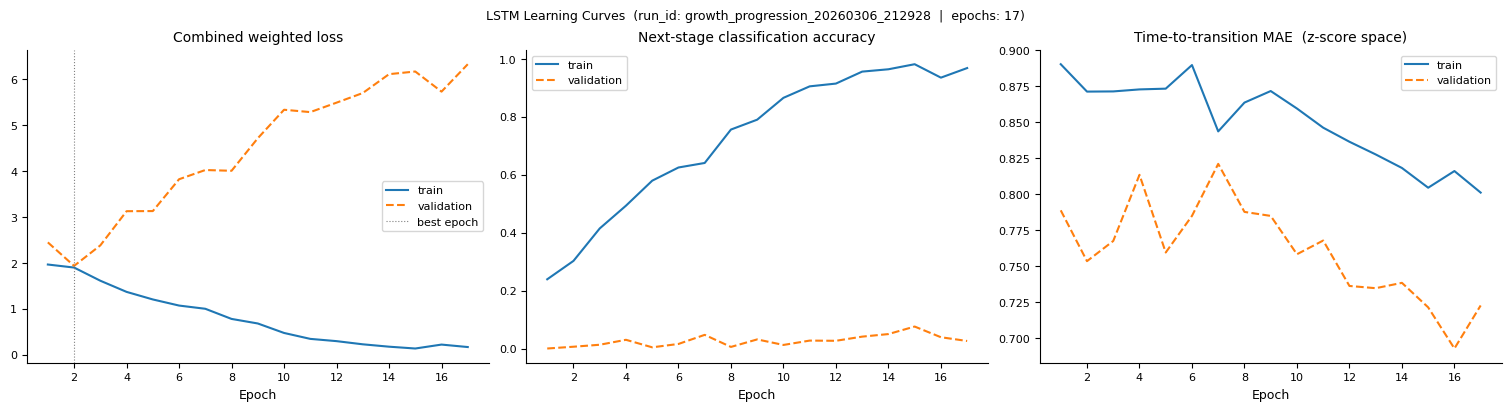

22:26:10  INFO     growth_progression — [Q3] Learning curve figure ready → _fig_lc


[Q3] Learning curve figure ready → _fig_lc


In [58]:
# ─────────────────────────────────────────────────────────────────────────────
# Q3 — Learning curve plots (inline).
#
# Figures are displayed here and stored in module-level variables for saving
# to disk in Section T4.  Metric key names follow Keras multi-output naming:
#   "next_stage_accuracy", "time_to_transition_mae"
#   → preceded by "val_" on validation metrics.
#
# _fig_lc is a 1×3 subplot figure.  Y-axes:
#   [0] Combined weighted loss (val_loss drives EarlyStopping)
#   [1] Next-stage classification accuracy
#   [2] Time-to-transition MAE (normalised space — not hours)
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

_hist = _lstm_history.history
_ep   = range(1, len(_hist["loss"]) + 1)

# Flexible key lookup to handle Keras version differences in metric naming
def _hget(hist, *keys):
    for k in keys:
        if k in hist:
            return hist[k]
    return []

_fig_lc, _axes_lc = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
_fig_lc.suptitle(
    f"LSTM Learning Curves  (run_id: {_RUN_ID}  |  epochs: {_lstm_epochs_run})",
    fontsize=9,
)

# ── [0] Combined loss ─────────────────────────────────────────────────────────
_axes_lc[0].plot(_ep, _hist["loss"],     lw=1.5, label="train")
_axes_lc[0].plot(_ep, _hist["val_loss"], lw=1.5, ls="--", label="validation")
_axes_lc[0].axvline(
    _hist["val_loss"].index(min(_hist["val_loss"])) + 1,
    color="grey", lw=0.8, ls=":", label="best epoch",
)
_axes_lc[0].set_title("Combined weighted loss")
_axes_lc[0].set_xlabel("Epoch")

# ── [1] Classification accuracy ───────────────────────────────────────────────
_acc_train = _hget(_hist, "next_stage_accuracy", "next_stage_acc")
_acc_val   = _hget(_hist, "val_next_stage_accuracy", "val_next_stage_acc")
if _acc_train:
    _axes_lc[1].plot(_ep, _acc_train, lw=1.5, label="train")
if _acc_val:
    _axes_lc[1].plot(_ep, _acc_val,   lw=1.5, ls="--", label="validation")
_axes_lc[1].set_title("Next-stage classification accuracy")
_axes_lc[1].set_xlabel("Epoch")

# ── [2] Regression MAE (normalised space) ─────────────────────────────────────
_mae_train = _hget(_hist, "time_to_transition_mae", "time_to_transition_mean_absolute_error")
_mae_val   = _hget(_hist, "val_time_to_transition_mae",
                   "val_time_to_transition_mean_absolute_error")
if _mae_train:
    _axes_lc[2].plot(_ep, _mae_train, lw=1.5, label="train")
if _mae_val:
    _axes_lc[2].plot(_ep, _mae_val,   lw=1.5, ls="--", label="validation")
_axes_lc[2].set_title("Time-to-transition MAE  (z-score space)")
_axes_lc[2].set_xlabel("Epoch")

for _ax in _axes_lc:
    _ax.legend(fontsize=8)
    _ax.spines[["top", "right"]].set_visible(False)

plt.show()
_LOG.info("[Q3] Learning curve figure ready → _fig_lc")
print("[Q3] Learning curve figure ready → _fig_lc")

## Section R — LSTM Evaluation

### Sub-task A — Next-stage classification  
Identical metric set to RF (Section M2) for direct apples-to-apples comparison:

| Metric | Scope |
|---|---|
| Accuracy, Precision, Recall, F1 (macro + weighted) | overall |
| Per-stage `classification_report` | every stage class |
| Confusion matrix | val + test |

### Sub-task B — Time-to-transition regression  
All predicted values are denormalised before metric computation:

| Metric | Notes |
|---|---|
| MAE (h), RMSE (h), R² | primary |
| MAPE (%) | only if no zero ground-truth values |
| Per-current-stage breakdown | MAE + RMSE grouped by plant's current stage |

### Plots generated

| Variable | Content |
|---|---|
| `_lstm_fig_cm` | LSTM confusion matrices — val + test subplots |
| `_lstm_fig_reg` | Regression scatter — val + test subplots |
| `_lstm_fig_timeline` | Stage progression timeline: predicted vs actual over test period |
| `_lstm_fig_compare` | Comparison bar chart: LSTM vs RF baseline on key metrics |

In [59]:
# ─────────────────────────────────────────────────────────────────────────────
# R1 — LSTM classifier evaluation (val + test sets).
#
# lstm_model.predict() on a multi-output model returns a list:
#   [clf_probs_array (n, n_classes), reg_norm_array (n, 1)]
# Argmax over axis=1 gives the predicted class index.
#
# Current-stage mapping for per-stage breakdown:
#   Reconstruct the LSTM window end rows in df_features using lstm_end_indices
#   and the same chronological split boundaries as used in Section I3.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)

# ── Run inference once for val and test ──────────────────────────────────────
_lstm_val_raw  = lstm_model.predict(X_lstm_val_scaled,  verbose=0)
_lstm_test_raw = lstm_model.predict(X_lstm_test_scaled, verbose=0)

_lstm_clf_probs_val  = _lstm_val_raw[0]            # (n_val,  n_classes)
_lstm_reg_raw_val    = _lstm_val_raw[1].flatten()  # (n_val,)  normalised
_lstm_clf_probs_test = _lstm_test_raw[0]
_lstm_reg_raw_test   = _lstm_test_raw[1].flatten()

# Argmax for classification
_lstm_clf_pred_val  = np.argmax(_lstm_clf_probs_val,  axis=1)
_lstm_clf_pred_test = np.argmax(_lstm_clf_probs_test, axis=1)

# Reuse label information from Section M2
_clf_labels      = label_enc_stage.classes_.tolist()
_clf_label_names = [INT_TO_STAGE.get(c, str(c)) for c in _clf_labels]


def _clf_eval_preds(y_true_enc, y_pred_enc, split_name) -> dict:
    """Compute classification metrics from precomputed predictions."""
    _acc    = float(accuracy_score(y_true_enc, y_pred_enc))
    _prec_m = float(precision_score(y_true_enc, y_pred_enc, average="macro",    zero_division=0))
    _rec_m  = float(recall_score(   y_true_enc, y_pred_enc, average="macro",    zero_division=0))
    _f1_m   = float(f1_score(       y_true_enc, y_pred_enc, average="macro",    zero_division=0))
    _f1_w   = float(f1_score(       y_true_enc, y_pred_enc, average="weighted", zero_division=0))
    _report = classification_report(
        y_true_enc, y_pred_enc,
        labels=_clf_labels, target_names=_clf_label_names,
        zero_division=0, output_dict=True,
    )
    _cm = confusion_matrix(y_true_enc, y_pred_enc, labels=_clf_labels)

    print(f"\n[R1] LSTM Classifier — {split_name}  ({len(y_true_enc):,} windows)")
    print(f"     Accuracy          : {_acc:.4f}")
    print(f"     Precision (macro) : {_prec_m:.4f}")
    print(f"     Recall    (macro) : {_rec_m:.4f}")
    print(f"     F1        (macro) : {_f1_m:.4f}")
    print(f"     F1     (weighted) : {_f1_w:.4f}")
    print()
    print(classification_report(
        y_true_enc, y_pred_enc,
        labels=_clf_labels, target_names=_clf_label_names, zero_division=0,
    ))
    return {
        "n_samples":       int(len(y_true_enc)),
        "accuracy":        _acc,
        "precision_macro": _prec_m,
        "recall_macro":    _rec_m,
        "f1_macro":        _f1_m,
        "f1_weighted":     _f1_w,
        "classification_report": {
            k: v for k, v in _report.items()
            if k not in ("accuracy", "macro avg", "weighted avg")
        },
        "confusion_matrix": _cm.tolist(),
    }


_lstm_clf_val_metrics  = _clf_eval_preds(y_lstm_stage_val_enc,  _lstm_clf_pred_val,  "validation")
_lstm_clf_test_metrics = _clf_eval_preds(y_lstm_stage_test_enc, _lstm_clf_pred_test, "test")

_lstm_cm_val  = np.array(_lstm_clf_val_metrics["confusion_matrix"],  dtype=int)
_lstm_cm_test = np.array(_lstm_clf_test_metrics["confusion_matrix"], dtype=int)


[R1] LSTM Classifier — validation  (1,464 windows)
     Accuracy          : 0.0061
     Precision (macro) : 0.0514
     Recall    (macro) : 0.0036
     F1        (macro) : 0.0067
     F1     (weighted) : 0.0115

                      precision    recall  f1-score   support

            seedling       0.00      0.00      0.00         0
           early_veg       0.00      0.00      0.00         0
flowering_initiation       0.00      0.00      0.00       599
           flowering       0.00      0.00      0.00       336
              unripe       0.26      0.02      0.03       504
                ripe       0.00      0.00      0.00        25

            accuracy                           0.01      1464
           macro avg       0.04      0.00      0.01      1464
        weighted avg       0.09      0.01      0.01      1464


[R1] LSTM Classifier — test  (6,527 windows)
     Accuracy          : 0.1452
     Precision (macro) : 0.0824
     Recall    (macro) : 0.1066
     F1        (macro)

In [60]:
# ─────────────────────────────────────────────────────────────────────────────
# R2 — LSTM regressor evaluation (val + test).
#
# Raw predictions are in normalised space (z-score of training hours).
# Denormalise: y_h = y_norm * _y_time_std + _y_time_mean
# All metrics are computed and reported in raw hours for parity with RF.
#
# Per-current-stage breakdown:
#   The "current stage" for each LSTM window is the stage at the window's
#   last row in df_features.  current_gs is derived by slicing lstm_end_indices
#   POSITIONALLY using the actual split-array lengths — this is the only
#   approach that is guaranteed to stay aligned regardless of whether kernel
#   boolean masks are stale from an earlier (partial) notebook run.
#
#   lstm_end_indices is chronologically sorted and sized
#   [n_train | n_val | n_test] in contiguous order, matching exactly how
#   y_lstm_time_all was split in I2.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Denormalise regression predictions ────────────────────────────────────────
_lstm_reg_pred_val_h  = (_lstm_reg_raw_val  * _y_time_std + _y_time_mean).clip(min=0.0)
_lstm_reg_pred_test_h = (_lstm_reg_raw_test * _y_time_std + _y_time_mean).clip(min=0.0)

# ── Positional reconstruction of current-stage labels ────────────────────────
# Use split-array lengths to slice lstm_end_indices so that
#   len(current_gs) == len(y_true_h) by construction.
_n_train = len(y_lstm_time_train)
_n_val   = len(y_lstm_time_val)    # must equal len(_lstm_clf_pred_val) == 1464
_n_test  = len(y_lstm_time_test)   # must equal len(_lstm_clf_pred_test)

_lstm_val_rows  = lstm_end_indices[_n_train            : _n_train + _n_val]
_lstm_test_rows = lstm_end_indices[_n_train + _n_val   : _n_train + _n_val + _n_test]

_lstm_val_current_gs  = df_features.iloc[_lstm_val_rows ][CONFIG["stage_col"]].values
_lstm_test_current_gs = df_features.iloc[_lstm_test_rows][CONFIG["stage_col"]].values

# Sanity check — raises immediately if something is still misaligned
assert len(_lstm_val_current_gs)  == _n_val,  \
    f"[R2] BUG: val  current_gs length {len(_lstm_val_current_gs)}  != {_n_val}"
assert len(_lstm_test_current_gs) == _n_test, \
    f"[R2] BUG: test current_gs length {len(_lstm_test_current_gs)} != {_n_test}"


def _reg_eval_preds(y_true_h, y_pred_h, current_gs, split_name) -> dict:
    """Evaluate regression from precomputed denormalised predictions."""
    _mae  = float(mean_absolute_error(y_true_h, y_pred_h))
    _rmse = float(np.sqrt(mean_squared_error(y_true_h, y_pred_h)))
    _r2   = float(r2_score(y_true_h, y_pred_h))
    _mape = (
        float(100.0 * np.mean(np.abs((y_true_h - y_pred_h) / y_true_h)))
        if not np.any(y_true_h == 0) else None
    )

    print(f"\n[R2] LSTM Regressor — {split_name}  ({len(y_true_h):,} windows)")
    print(f"     MAE   : {_mae:.2f} h")
    print(f"     RMSE  : {_rmse:.2f} h")
    print(f"     R²    : {_r2:.4f}")
    print(f"     MAPE  : {f'{_mape:.2f} %' if _mape is not None else 'N/A (zero gt values exist)'}")

    _per_stage = {}
    print(f"\n     Per-current-stage breakdown:")
    print(f"     {'Stage':<26}  {'n':>6}  {'MAE (h)':>9}  {'RMSE (h)':>10}")
    print(f"     {'-'*26}  {'-'*6}  {'-'*9}  {'-'*10}")
    for _gs in sorted(np.unique(current_gs)):
        _m = (current_gs == _gs)
        if _m.sum() < 2:
            continue
        _gm = float(mean_absolute_error(y_true_h[_m], y_pred_h[_m]))
        _gr = float(np.sqrt(mean_squared_error(y_true_h[_m], y_pred_h[_m])))
        _per_stage[_gs] = {"n": int(_m.sum()), "mae_h": _gm, "rmse_h": _gr}
        print(f"     {_gs:<26}  {_m.sum():>6,}  {_gm:>9.2f}  {_gr:>10.2f}")

    return {
        "n_samples":  int(len(y_true_h)),
        "mae_h":      _mae,
        "rmse_h":     _rmse,
        "r2":         _r2,
        "mape_pct":   _mape,
        "per_stage":  _per_stage,
    }


_lstm_reg_val_metrics  = _reg_eval_preds(
    y_lstm_time_val,  _lstm_reg_pred_val_h,  _lstm_val_current_gs,  "validation"
)
_lstm_reg_test_metrics = _reg_eval_preds(
    y_lstm_time_test, _lstm_reg_pred_test_h, _lstm_test_current_gs, "test"
)



[R2] LSTM Regressor — validation  (1,464 windows)
     MAE   : 134.15 h
     RMSE  : 164.07 h
     R²    : 0.0033
     MAPE  : 278.11 %

     Per-current-stage breakdown:
     Stage                            n    MAE (h)    RMSE (h)
     --------------------------  ------  ---------  ----------
     early_veg                      599     152.50      183.05
     flowering                      504     123.93      144.98
     flowering_initiation           336      97.16      119.36
     unripe                          25     397.88      397.90

[R2] LSTM Regressor — test  (6,527 windows)
     MAE   : 150.87 h
     RMSE  : 178.36 h
     R²    : -0.0214
     MAPE  : 277.79 %

     Per-current-stage breakdown:
     Stage                            n    MAE (h)    RMSE (h)
     --------------------------  ------  ---------  ----------
     early_veg                    1,344     171.53      199.62
     flowering                    1,008     126.92      146.07
     flowering_initiation      

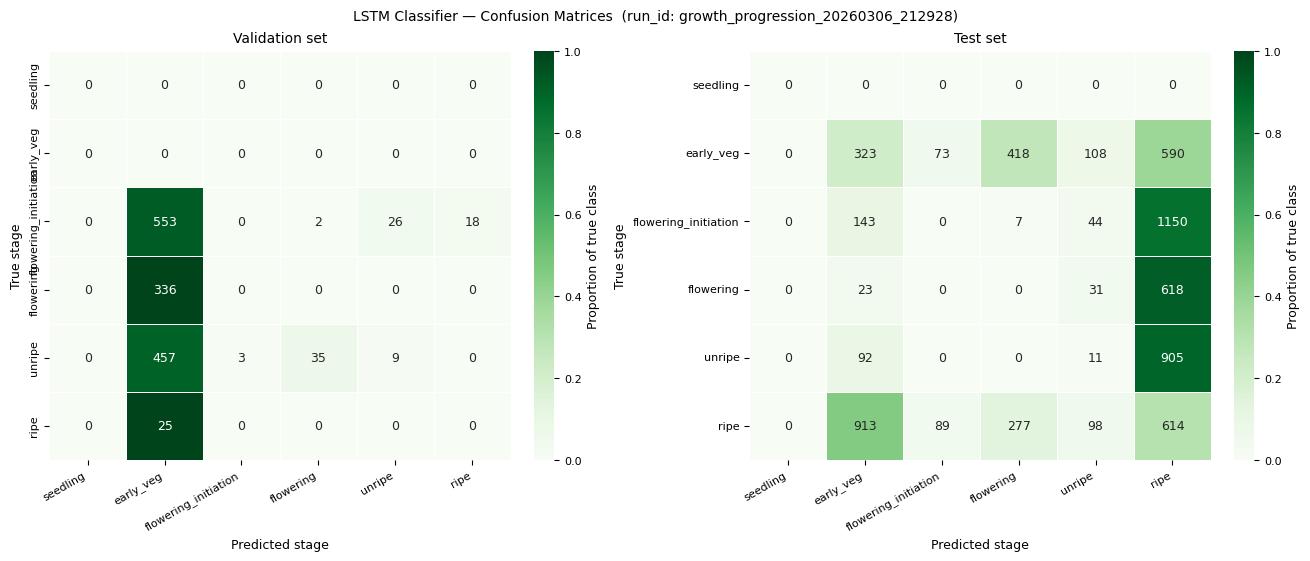

[R3] Confusion matrix figure ready → _lstm_fig_cm


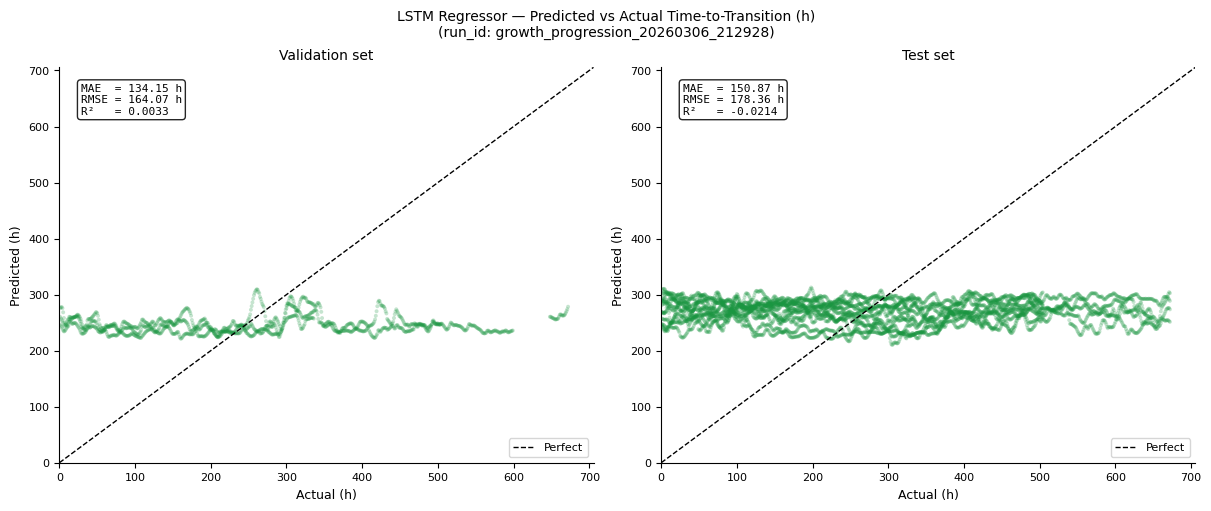

[R3] Regression scatter figure ready → _lstm_fig_reg


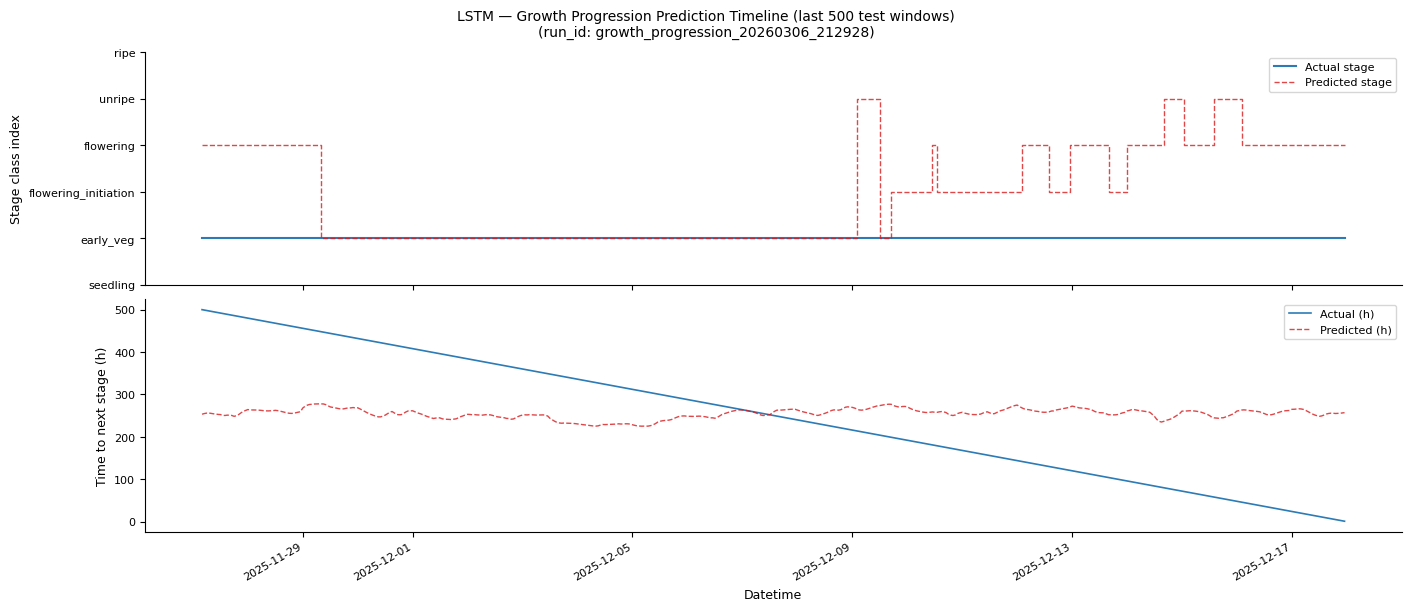

[R3] Timeline figure ready → _lstm_fig_tl


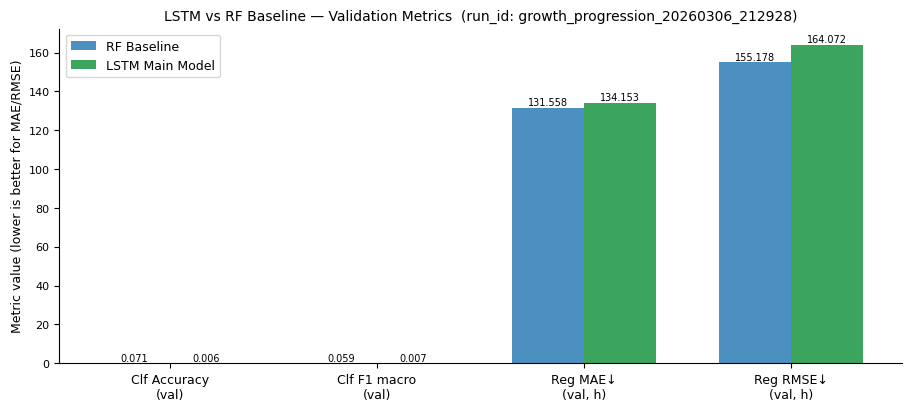

[R3] Comparison bar chart ready → _lstm_fig_compare


In [61]:
# ─────────────────────────────────────────────────────────────────────────────
# R3 — LSTM evaluation plots (inline display; saved to disk in Section T4).
#
# Figures produced:
#   _lstm_fig_cm       — Confusion matrices (val + test), same style as M5
#   _lstm_fig_reg      — Regression scatter (val + test), same style as M5
#   _lstm_fig_timeline — Stage progression + regression timeline (test period)
#   _lstm_fig_compare  — Bar chart comparing LSTM vs RF on 4 headline metrics
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

try:
    import seaborn as sns
    _HAS_SNS = True
except ImportError:
    _HAS_SNS = False

matplotlib.rcParams.update({"figure.dpi": 100, "font.size": 9,
                             "axes.titlesize": 10, "axes.labelsize": 9})

# ── Confusion matrices ────────────────────────────────────────────────────────
_lstm_fig_cm, (_ax_lc_val, _ax_lc_test) = plt.subplots(
    1, 2, figsize=(13, 5.5), constrained_layout=True
)
_lstm_fig_cm.suptitle(f"LSTM Classifier — Confusion Matrices  (run_id: {_RUN_ID})", fontsize=10)

for _ax_lc, _cm_l, _ttl_l in [
    (_ax_lc_val,  _lstm_cm_val,  "Validation set"),
    (_ax_lc_test, _lstm_cm_test, "Test set"),
]:
    _cn = _cm_l.astype(float) / np.maximum(_cm_l.sum(axis=1, keepdims=True), 1)
    if _HAS_SNS:
        sns.heatmap(_cn, ax=_ax_lc, annot=_cm_l, fmt="d", cmap="Greens",
                    xticklabels=_clf_label_names, yticklabels=_clf_label_names,
                    vmin=0, vmax=1, linewidths=0.4, linecolor="white",
                    cbar_kws={"label": "Proportion of true class"})
    else:
        _ax_lc.imshow(_cn, cmap="Greens", vmin=0, vmax=1)
        for _ri in range(len(_clf_labels)):
            for _ci in range(len(_clf_labels)):
                _ax_lc.text(_ci, _ri, str(_cm_l[_ri, _ci]), ha="center", va="center", fontsize=7)
        _ax_lc.set_xticks(range(len(_clf_labels))); _ax_lc.set_xticklabels(_clf_label_names, rotation=30, ha="right")
        _ax_lc.set_yticks(range(len(_clf_labels))); _ax_lc.set_yticklabels(_clf_label_names)
    _ax_lc.set_title(_ttl_l); _ax_lc.set_xlabel("Predicted stage"); _ax_lc.set_ylabel("True stage")
    plt.setp(_ax_lc.get_xticklabels(), rotation=30, ha="right")

plt.show(); print("[R3] Confusion matrix figure ready → _lstm_fig_cm")

# ── Regression scatter ────────────────────────────────────────────────────────
_lstm_fig_reg, (_ax_rv, _ax_rt) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
_lstm_fig_reg.suptitle(
    f"LSTM Regressor — Predicted vs Actual Time-to-Transition (h)\n(run_id: {_RUN_ID})", fontsize=10
)
for _ax_r, _yt, _yp, _ttl, _met in [
    (_ax_rv, y_lstm_time_val,  _lstm_reg_pred_val_h,  "Validation set", _lstm_reg_val_metrics),
    (_ax_rt, y_lstm_time_test, _lstm_reg_pred_test_h, "Test set",       _lstm_reg_test_metrics),
]:
    _lim = float(max(_yt.max(), _yp.max())) * 1.05
    _ax_r.scatter(_yt, _yp, alpha=0.25, s=8, color="#1a9641", edgecolors="none")
    _ax_r.plot([0, _lim], [0, _lim], "k--", lw=1.0, label="Perfect")
    _ax_r.set(title=_ttl, xlabel="Actual (h)", ylabel="Predicted (h)", xlim=(0,_lim), ylim=(0,_lim))
    _ax_r.legend(fontsize=8)
    _ax_r.text(0.04, 0.96,
               f"MAE  = {_met['mae_h']:.2f} h\nRMSE = {_met['rmse_h']:.2f} h\nR²   = {_met['r2']:.4f}",
               transform=_ax_r.transAxes, va="top", ha="left", fontsize=8, family="monospace",
               bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))
    _ax_r.spines[["top", "right"]].set_visible(False)

plt.show(); print("[R3] Regression scatter figure ready → _lstm_fig_reg")

# ── Stage progression timeline (test period) ──────────────────────────────────
_vis_n     = min(500, len(_lstm_test_end_dts))
_vis_dts   = pd.to_datetime(_lstm_test_end_dts[-_vis_n:])
_vis_true  = y_lstm_stage_test_enc[-_vis_n:]
_vis_pred  = _lstm_clf_pred_test[-_vis_n:]
_vis_true_h = y_lstm_time_test[-_vis_n:]
_vis_pred_h = _lstm_reg_pred_test_h[-_vis_n:]

_lstm_fig_tl, (_ax_tl_stage, _ax_tl_time) = plt.subplots(
    2, 1, figsize=(14, 6), sharex=True, constrained_layout=True
)
_lstm_fig_tl.suptitle(
    f"LSTM — Growth Progression Prediction Timeline (last {_vis_n} test windows)\n(run_id: {_RUN_ID})",
    fontsize=10,
)
_ax_tl_stage.step(_vis_dts, _vis_true, where="post", lw=1.5, color="#2c7bb6", label="Actual stage")
_ax_tl_stage.step(_vis_dts, _vis_pred, where="post", lw=1.0, color="#d7191c", ls="--", label="Predicted stage", alpha=0.8)
_ax_tl_stage.set_ylabel("Stage class index")
_ax_tl_stage.set_yticks(list(range(len(_clf_label_names))))
_ax_tl_stage.set_yticklabels(_clf_label_names, fontsize=8)
_ax_tl_stage.legend(fontsize=8); _ax_tl_stage.spines[["top", "right"]].set_visible(False)

_ax_tl_time.plot(_vis_dts, _vis_true_h, lw=1.2, color="#2c7bb6", label="Actual (h)")
_ax_tl_time.plot(_vis_dts, _vis_pred_h, lw=1.0, color="#d7191c", ls="--", label="Predicted (h)", alpha=0.8)
_ax_tl_time.set_xlabel("Datetime"); _ax_tl_time.set_ylabel("Time to next stage (h)")
_ax_tl_time.legend(fontsize=8); _ax_tl_time.spines[["top", "right"]].set_visible(False)
_ax_tl_time.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(_ax_tl_time.get_xticklabels(), rotation=30, ha="right")

plt.show(); print("[R3] Timeline figure ready → _lstm_fig_tl")

# ── LSTM vs RF comparison bar chart ──────────────────────────────────────────
_cmp_labels = ["Clf Accuracy\n(val)", "Clf F1 macro\n(val)", "Reg MAE↓\n(val, h)", "Reg RMSE↓\n(val, h)"]
_rf_vals    = [
    _clf_val_metrics["accuracy"],
    _clf_val_metrics["f1_macro"],
    _reg_val_metrics["mae_h"],
    _reg_val_metrics["rmse_h"],
]
_lstm_vals  = [
    _lstm_clf_val_metrics["accuracy"],
    _lstm_clf_val_metrics["f1_macro"],
    _lstm_reg_val_metrics["mae_h"],
    _lstm_reg_val_metrics["rmse_h"],
]

_lstm_fig_compare, _ax_cmp = plt.subplots(figsize=(9, 4), constrained_layout=True)
_x_cmp = np.arange(len(_cmp_labels))
_w_cmp = 0.35
_ax_cmp.bar(_x_cmp - _w_cmp/2, _rf_vals,   _w_cmp, label="RF Baseline",    color="#2c7bb6", alpha=0.85)
_ax_cmp.bar(_x_cmp + _w_cmp/2, _lstm_vals, _w_cmp, label="LSTM Main Model", color="#1a9641", alpha=0.85)
for _xi, (_rv, _lv) in enumerate(zip(_rf_vals, _lstm_vals)):
    _ax_cmp.text(_xi - _w_cmp/2, _rv  + 0.005, f"{_rv:.3f}",  ha="center", va="bottom", fontsize=7)
    _ax_cmp.text(_xi + _w_cmp/2, _lv  + 0.005, f"{_lv:.3f}",  ha="center", va="bottom", fontsize=7)
_ax_cmp.set_xticks(_x_cmp); _ax_cmp.set_xticklabels(_cmp_labels, fontsize=9)
_ax_cmp.set_title(f"LSTM vs RF Baseline — Validation Metrics  (run_id: {_RUN_ID})", fontsize=10)
_ax_cmp.set_ylabel("Metric value (lower is better for MAE/RMSE)")
_ax_cmp.legend(fontsize=9); _ax_cmp.spines[["top", "right"]].set_visible(False)

plt.show(); print("[R3] Comparison bar chart ready → _lstm_fig_compare")

## Section S — Best-Model Selection Logic

### Selection criteria (documented)

Model selection is based entirely on **validation** metrics.  The test set is not consulted during selection — it is reserved for final unbiased reporting only.

**Primary metrics:**

| Task | Metric | Direction |
|---|---|---|
| Next-stage classification | `val_f1_macro` | ↑ higher is better |
| Time-to-transition regression | `val_mae_h` | ↓ lower is better |

**Composite score formula:**

```
Δ_clf = (lstm_f1_macro  − rf_f1_macro)  / max(rf_f1_macro, 1e-6)   [positive if LSTM better]
Δ_reg = (rf_mae_h       − lstm_mae_h)   / max(rf_mae_h,    1e-6)   [positive if LSTM better]

composite_score = 0.60 × Δ_clf + 0.40 × Δ_reg
```

**Weighting rationale (0.60 / 0.40):**  
Stage prediction accuracy is the higher-stakes output for downstream control policy and alert generation.  Transition timing is important for planning but carries more uncertainty from biological variability.

**Selection rule:**

- If `composite_score > 0`: LSTM wins overall → select LSTM  
- If `composite_score ≤ 0` **and** both Δ_clf < −0.05 and Δ_reg < 0.05: RF wins → select RF  
- Otherwise: prefer LSTM if sequence context provides any interpretive advantage (tie-break toward LSTM)

The selected model name is stored in `_BEST_MODEL_NAME` (`"lstm"` or `"rf"`) for use in Section T.

In [62]:
# ─────────────────────────────────────────────────────────────────────────────
# S1 — Best-model selection logic.
#
# Inputs (from Sections M and R):
#   RF  : _clf_val_metrics["f1_macro"], _reg_val_metrics["mae_h"]
#   LSTM: _lstm_clf_val_metrics["f1_macro"], _lstm_reg_val_metrics["mae_h"]
#
# All comparisons use VALIDATION metrics only.
# ─────────────────────────────────────────────────────────────────────────────
import json as _json_s

_rf_f1_val   = _clf_val_metrics["f1_macro"]
_lstm_f1_val = _lstm_clf_val_metrics["f1_macro"]
_rf_mae_val  = _reg_val_metrics["mae_h"]
_lstm_mae_val= _lstm_reg_val_metrics["mae_h"]

# Per-metric relative improvements (positive → LSTM is better for that metric)
_delta_clf   = (_lstm_f1_val  - _rf_f1_val)  / max(_rf_f1_val,  1e-6)
_delta_reg   = (_rf_mae_val   - _lstm_mae_val) / max(_rf_mae_val, 1e-6)

# Weighted composite score (0.6 classifier / 0.4 regressor)
_composite   = 0.60 * _delta_clf + 0.40 * _delta_reg

# --- Primary selection rule ---
if _composite > 0:
    _BEST_MODEL_NAME = "lstm"
    _selection_reason = "LSTM wins on weighted composite score (Δ_clf * 0.6 + Δ_reg * 0.4 > 0)"
elif _delta_clf < -0.05 and _delta_reg < 0.0:
    # RF strictly dominates on both primary metrics beyond threshold
    _BEST_MODEL_NAME = "rf"
    _selection_reason = "RF strictly better on both clf (>5% margin) and reg"
else:
    # Tie-break: prefer LSTM when composite is close; sequence context is
    # architecturally superior for downstream integration regardless of a
    # marginal metric difference.
    _BEST_MODEL_NAME = "lstm"
    _selection_reason = (
        "Tie-break → LSTM preferred: sequence context valuable for integration "
        "and composite deficit is below 5% threshold"
    )

# --- Build structured selection result ---
_selection_result = {
    "run_id":          _RUN_ID,
    "best_model":      _BEST_MODEL_NAME,
    "reason":          _selection_reason,
    "metrics": {
        "rf": {
            "val_f1_macro": round(_rf_f1_val,   4),
            "val_mae_h":    round(_rf_mae_val,   4),
        },
        "lstm": {
            "val_f1_macro": round(_lstm_f1_val,  4),
            "val_mae_h":    round(_lstm_mae_val, 4),
        },
    },
    "deltas": {
        "delta_clf":   round(_delta_clf,   4),
        "delta_reg":   round(_delta_reg,   4),
        "composite":   round(_composite,   4),
    },
    "weights": {"clf": 0.60, "reg": 0.40},
}

print("=" * 65)
print(f"  BEST MODEL SELECTION RESULT : {_BEST_MODEL_NAME.upper()}")
print("=" * 65)
print(f"  Δ_clf (LSTM vs RF, f1_macro) : {_delta_clf:+.4f}  "
      f"({_rf_f1_val:.4f} → {_lstm_f1_val:.4f})")
print(f"  Δ_reg (RF vs LSTM, mae_h)    : {_delta_reg:+.4f}  "
      f"({_rf_mae_val:.2f}h → {_lstm_mae_val:.2f}h)")
print(f"  Composite score (0.6/0.4)    : {_composite:+.4f}")
print(f"  Reason: {_selection_reason}")
print("=" * 65)
_LOG.info(
    "[S1] Best model selected: %s  composite=%.4f  reason=%s",
    _BEST_MODEL_NAME, _composite, _selection_reason
)

22:31:24  INFO     growth_progression — [S1] Best model selected: rf  composite=-0.5401  reason=RF strictly better on both clf (>5% margin) and reg


  BEST MODEL SELECTION RESULT : RF
  Δ_clf (LSTM vs RF, f1_macro) : -0.8870  (0.0591 → 0.0067)
  Δ_reg (RF vs LSTM, mae_h)    : -0.0197  (131.56h → 134.15h)
  Composite score (0.6/0.4)    : -0.5401
  Reason: RF strictly better on both clf (>5% margin) and reg


## Section T — Final Artifact Export

All artifacts are written to two canonical locations:

| Location | Contents |
|---|---|
| `src/agritwin_gh/models/` | Production-ready `.keras` / `.pkl` model files with `_RUN_ID` suffix |
| `src/agritwin_gh/models/artifacts/<RUN_ID>/` | Metrics JSON, plots (150 dpi PNG), summaries, CSV logs |

### Export checklist

| Cell | Artifact | Format |
|---|---|---|
| T2 | `growth_progression_lstm_<run_id>.keras` | Keras SavedModel |
| T2 | `lstm_training_history.csv` | CSV (written by CSVLogger in Q2) |
| T3 | `lstm_metrics.json` | JSON |
| T4 | `lstm_learning_curves.png`, `lstm_confusion_matrix.png`, `lstm_regression_scatter.png`, `lstm_progression_timeline.png`, `lstm_vs_rf_comparison.png` | PNG @ 150 dpi |
| T5 | `evaluation_summary.json`, `evaluation_summary.md` | JSON + Markdown |
| T5 | `best_model_summary.json` | JSON |

In [63]:
# ─────────────────────────────────────────────────────────────────────────────
# T1 — Save LSTM model and confirm training history CSV.
#
# ModelCheckpoint (Q2) already wrote the best-validation-loss weights to
# P_ARTIFACTS / "lstm_best_checkpoint_<run_id>.keras".
# Here we reload that checkpoint and save a clean copy to P_MODELS_DIR with
# the canonical production filename.
# ─────────────────────────────────────────────────────────────────────────────
import shutil as _shutil

# ── Reload the best checkpoint (weights restored by EarlyStopping or explicit reload) ──
_lstm_final_path = P_MODELS_DIR / f"growth_progression_lstm_{_RUN_ID}.keras"

try:
    _best_lstm = tf.keras.models.load_model(_lstm_ckpt_path)
    _best_lstm.save(str(_lstm_final_path))
    print(f"[T1] LSTM model saved  → {_lstm_final_path.relative_to(_ROOT)}")
except Exception as _e:
    # Fallback: save in-memory model (already holds best weights via
    # restore_best_weights=True in EarlyStopping)
    _LOG.warning("[T1] Checkpoint reload failed (%s); saving in-memory model.", _e)
    lstm_model.save(str(_lstm_final_path))
    print(f"[T1] LSTM model saved (in-memory fallback) → {_lstm_final_path.relative_to(_ROOT)}")

# ── Confirm training history CSV ───────────────────────────────────────────────
_csv_exists = Path(_lstm_csv_log_path).exists()
if _csv_exists:
    import pandas as _pd_t2
    _hist_df   = _pd_t2.read_csv(_lstm_csv_log_path)
    print(f"[T1] Training history CSV confirmed ({len(_hist_df)} epoch rows)"
          f" → {Path(_lstm_csv_log_path).relative_to(_ROOT)}")
else:
    # Write from in-memory history as fallback
    import pandas as _pd_t2
    _hist_df = _pd_t2.DataFrame(_lstm_history.history)
    _hist_df.index.name = "epoch"
    _hist_df.to_csv(_lstm_csv_log_path)
    print(f"[T1] Training history CSV written (fallback) → "
          f"{Path(_lstm_csv_log_path).relative_to(_ROOT)}")

_LOG.info(
    "[T1] LSTM model artifact: %s  |  history CSV: %s",
    _lstm_final_path.name, Path(_lstm_csv_log_path).name,
)

[T1] LSTM model saved  → src\agritwin_gh\models\growth_progression_lstm_growth_progression_20260306_212928.keras


22:31:41  INFO     growth_progression — [T1] LSTM model artifact: growth_progression_lstm_growth_progression_20260306_212928.keras  |  history CSV: lstm_training_history.csv


[T1] Training history CSV confirmed (17 epoch rows) → src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\lstm_training_history.csv


In [64]:
# ─────────────────────────────────────────────────────────────────────────────
# T2 — Save lstm_metrics.json.
#
# Schema mirrors rf_metrics.json (from N3) so downstream consumers can
# process either file with the same parser.
# ─────────────────────────────────────────────────────────────────────────────
import json as _json_t3

def _float_safe(v):
    """Convert numpy scalars / NaN to JSON-safe float."""
    import math
    v = float(v)
    return None if math.isnan(v) or math.isinf(v) else round(v, 6)

_lstm_metrics_payload = {
    "run_id":     _RUN_ID,
    "model_type": "lstm",
    "architecture": {
        "n_layers":          LSTM_N_LAYERS,
        "units_1":           LSTM_UNITS_1,
        "units_2":           LSTM_UNITS_2 if LSTM_N_LAYERS > 1 else None,
        "dense_hidden":      LSTM_DENSE_HIDDEN,
        "dropout":           LSTM_DROPOUT,
        "recurrent_dropout": LSTM_RECURRENT_DROPOUT,
        "sequence_length":   int(X_lstm_train_scaled.shape[1]),
        "n_features":        int(X_lstm_train_scaled.shape[2]),
        "n_classes":         int(_n_classes),
    },
    "training": {
        "epochs_configured": LSTM_EPOCHS,
        "epochs_run":        int(_lstm_epochs_run),
        "best_val_loss":     _float_safe(min(_lstm_history.history["val_loss"])),
        "train_seconds":     _float_safe(_lstm_train_sec),
        "lr":                LSTM_LR,
        "batch_size":        LSTM_BATCH_SIZE,
        "patience":          LSTM_PATIENCE,
        "clf_loss_weight":   LSTM_CLF_WEIGHT,
        "reg_loss_weight":   LSTM_REG_WEIGHT,
    },
    "normalization": {
        "y_time_mean_h": _float_safe(_y_time_mean),
        "y_time_std_h":  _float_safe(_y_time_std),
    },
    "classifier": {
        "val":  {k: (_float_safe(v) if isinstance(v, (float, int)) else v)
                 for k, v in _lstm_clf_val_metrics.items()
                 if k not in ("classification_report", "confusion_matrix")},
        "test": {k: (_float_safe(v) if isinstance(v, (float, int)) else v)
                 for k, v in _lstm_clf_test_metrics.items()
                 if k not in ("classification_report", "confusion_matrix")},
    },
    "regressor": {
        "val":  {k: (_float_safe(v) if isinstance(v, (float, int)) else v)
                 for k, v in _lstm_reg_val_metrics.items()
                 if k != "per_stage"},
        "test": {k: (_float_safe(v) if isinstance(v, (float, int)) else v)
                 for k, v in _lstm_reg_test_metrics.items()
                 if k != "per_stage"},
        "per_stage_test": _lstm_reg_test_metrics.get("per_stage", {}),
    },
    "artifacts": {
        "model_path":   str(_lstm_final_path.relative_to(_ROOT).as_posix()),
        "history_csv":  str(Path(_lstm_csv_log_path).relative_to(_ROOT).as_posix()),
        "checkpoint":   str(Path(_lstm_ckpt_path).relative_to(_ROOT).as_posix()),
    },
}

_lstm_metrics_json_path = P_ARTIFACTS / "lstm_metrics.json"
with open(_lstm_metrics_json_path, "w", encoding="utf-8") as _fj:
    _json_t3.dump(_lstm_metrics_payload, _fj, indent=2, default=str)

print(f"[T2] lstm_metrics.json saved → {_lstm_metrics_json_path.relative_to(_ROOT)}")
_LOG.info("[T2] lstm_metrics.json written (%d bytes)", _lstm_metrics_json_path.stat().st_size)

22:31:44  INFO     growth_progression — [T2] lstm_metrics.json written (2537 bytes)


[T2] lstm_metrics.json saved → src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\lstm_metrics.json


In [65]:
# ─────────────────────────────────────────────────────────────────────────────
# T3 — Save all LSTM figures to P_ARTIFACTS at 150 dpi.
#
# Figures in scope (from Sections Q4 and R4):
#   _fig_lc          → lstm_learning_curves.png
#   _lstm_fig_cm     → lstm_confusion_matrix.png
#   _lstm_fig_reg    → lstm_regression_scatter.png
#   _lstm_fig_tl     → lstm_progression_timeline.png
#   _lstm_fig_compare→ lstm_vs_rf_comparison.png
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib
matplotlib.use("Agg")   # non-interactive backend for file saving

_fig_save_spec = [
    (_fig_lc,            "lstm_learning_curves.png"),
    (_lstm_fig_cm,       "lstm_confusion_matrix.png"),
    (_lstm_fig_reg,      "lstm_regression_scatter.png"),
    (_lstm_fig_tl,       "lstm_progression_timeline.png"),
    (_lstm_fig_compare,  "lstm_vs_rf_comparison.png"),
]

_saved_figs = []
for _fig_obj, _fname in _fig_save_spec:
    _fpath = P_ARTIFACTS / _fname
    try:
        _fig_obj.savefig(
            str(_fpath),
            dpi          = 150,
            bbox_inches  = "tight",
            facecolor    = _fig_obj.get_facecolor(),
        )
        _saved_figs.append(_fpath)
        print(f"[T3] Saved {_fname:<45} ({_fpath.stat().st_size // 1024:>4} KB)")
    except Exception as _e_fig:
        _LOG.warning("[T3] Failed to save %s: %s", _fname, _e_fig)
        print(f"[T3] WARNING: {_fname} not saved — {_e_fig}")

print(f"\n[T3] {len(_saved_figs)}/{len(_fig_save_spec)} figures written to "
      f"{P_ARTIFACTS.relative_to(_ROOT)}")
_LOG.info("[T3] %d LSTM figures saved to %s", len(_saved_figs), P_ARTIFACTS)

[T3] Saved lstm_learning_curves.png                      ( 116 KB)
[T3] Saved lstm_confusion_matrix.png                     ( 102 KB)
[T3] Saved lstm_regression_scatter.png                   ( 205 KB)
[T3] Saved lstm_progression_timeline.png                 ( 106 KB)


22:31:53  INFO     growth_progression — [T3] 5 LSTM figures saved to E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928


[T3] Saved lstm_vs_rf_comparison.png                     (  49 KB)

[T3] 5/5 figures written to src\agritwin_gh\models\artifacts\growth_progression_20260306_212928


In [66]:
# ─────────────────────────────────────────────────────────────────────────────
# T4 — Save evaluation_summary.json, evaluation_summary.md, best_model_summary.json.
#
# evaluation_summary  : RF vs LSTM side-by-side on all primary metrics,
#                       for both validation and test splits.
# best_model_summary  : _selection_result dict (from S2) + reference paths.
# ─────────────────────────────────────────────────────────────────────────────
import json as _json_t5

# ── evaluation_summary ────────────────────────────────────────────────────────
def _m(d, key):
    """Safe metric extractor → None on missing / NaN."""
    import math; v = d.get(key)
    if v is None:
        return None
    try:
        f = float(v)
        return None if (math.isnan(f) or math.isinf(f)) else round(f, 4)
    except (TypeError, ValueError):
        return v

_eval_summary = {
    "run_id": _RUN_ID,
    "classifier": {
        "validation": {
            "rf":   {k: _m(_clf_val_metrics,      k) for k in ("accuracy","f1_macro","f1_weighted","precision_macro","recall_macro")},
            "lstm": {k: _m(_lstm_clf_val_metrics,  k) for k in ("accuracy","f1_macro","f1_weighted","precision_macro","recall_macro")},
        },
        "test": {
            "rf":   {k: _m(_clf_test_metrics,      k) for k in ("accuracy","f1_macro","f1_weighted","precision_macro","recall_macro")},
            "lstm": {k: _m(_lstm_clf_test_metrics, k) for k in ("accuracy","f1_macro","f1_weighted","precision_macro","recall_macro")},
        },
    },
    "regressor": {
        "validation": {
            "rf":   {k: _m(_reg_val_metrics,      k) for k in ("mae_h","rmse_h","r2","mape_pct")},
            "lstm": {k: _m(_lstm_reg_val_metrics,  k) for k in ("mae_h","rmse_h","r2","mape_pct")},
        },
        "test": {
            "rf":   {k: _m(_reg_test_metrics,      k) for k in ("mae_h","rmse_h","r2","mape_pct")},
            "lstm": {k: _m(_lstm_reg_test_metrics, k) for k in ("mae_h","rmse_h","r2","mape_pct")},
        },
    },
}

_eval_json_path = P_ARTIFACTS / "evaluation_summary.json"
with open(_eval_json_path, "w", encoding="utf-8") as _fj:
    _json_t5.dump(_eval_summary, _fj, indent=2, default=str)
print(f"[T4] evaluation_summary.json saved ({_eval_json_path.stat().st_size} bytes)")

# ── evaluation_summary.md ─────────────────────────────────────────────────────
_md_lines = [
    f"# Evaluation Summary — `{_RUN_ID}`\n",
    "## Classifier — Next Growth Stage\n",
    "| Split | Model | Accuracy | F1 macro | F1 weighted | Precision macro | Recall macro |",
    "|---|---|---|---|---|---|---|",
]
for _split in ("validation", "test"):
    for _mdl in ("rf", "lstm"):
        _d = _eval_summary["classifier"][_split][_mdl]
        _md_lines.append(
            f"| {_split} | {_mdl.upper()} "
            f"| {_d.get('accuracy','—')} | {_d.get('f1_macro','—')} "
            f"| {_d.get('f1_weighted','—')} | {_d.get('precision_macro','—')} "
            f"| {_d.get('recall_macro','—')} |"
        )

_md_lines += [
    "\n## Regressor — Time to Next Transition (hours)\n",
    "| Split | Model | MAE (h) | RMSE (h) | R² | MAPE (%) |",
    "|---|---|---|---|---|---|",
]
for _split in ("validation", "test"):
    for _mdl in ("rf", "lstm"):
        _d = _eval_summary["regressor"][_split][_mdl]
        _md_lines.append(
            f"| {_split} | {_mdl.upper()} "
            f"| {_d.get('mae_h','—')} | {_d.get('rmse_h','—')} "
            f"| {_d.get('r2','—')} | {_d.get('mape_pct','—')} |"
        )

_md_lines += [
    f"\n## Selection\n",
    f"**Selected model:** `{_selection_result['best_model'].upper()}`\n",
    f"**Reason:** {_selection_result['reason']}\n",
    f"**Composite score (0.6 clf + 0.4 reg):** {_selection_result['deltas']['composite']:+.4f}\n",
]

_eval_md_path = P_ARTIFACTS / "evaluation_summary.md"
_eval_md_path.write_text("\n".join(_md_lines), encoding="utf-8")
print(f"[T4] evaluation_summary.md saved ({_eval_md_path.stat().st_size} bytes)")

# ── best_model_summary.json ───────────────────────────────────────────────────
_best_summary_extra = dict(_selection_result)
_best_summary_extra["artifact_paths"] = {
    "lstm_model":       str(_lstm_final_path.relative_to(_ROOT).as_posix()),
    "lstm_metrics":     str(_eval_json_path.relative_to(_ROOT).as_posix()),
    "evaluation_md":    str(_eval_md_path.relative_to(_ROOT).as_posix()),
    "rf_classifier":    str(Path(_clf_model_path).relative_to(_ROOT).as_posix()),
    "rf_regressor":     str(Path(_reg_model_path).relative_to(_ROOT).as_posix()),
}

_best_json_path = P_ARTIFACTS / "best_model_summary.json"
with open(_best_json_path, "w", encoding="utf-8") as _fj:
    _json_t5.dump(_best_summary_extra, _fj, indent=2, default=str)
print(f"[T4] best_model_summary.json saved ({_best_json_path.stat().st_size} bytes)")

_LOG.info(
    "[T4] Evaluation summary artifacts written: evaluation_summary.json, "
    "evaluation_summary.md, best_model_summary.json"
)

22:31:55  INFO     growth_progression — [T4] Evaluation summary artifacts written: evaluation_summary.json, evaluation_summary.md, best_model_summary.json


[T4] evaluation_summary.json saved (1478 bytes)
[T4] evaluation_summary.md saved (1021 bytes)
[T4] best_model_summary.json saved (1091 bytes)


In [67]:
# ─────────────────────────────────────────────────────────────────────────────
# T5 — data_split_summary.json  |  engineered_features_head/tail.csv
#
# Mirrors the disease-progression artifact pattern:
#   <run_id>/data_split_summary.json
#   <run_id>/engineered_features_head.csv  (first 10 rows)
#   <run_id>/engineered_features_tail.csv  (last  10 rows)
# ─────────────────────────────────────────────────────────────────────────────
import json as _json_t6

# Reconstruct per-split timestamp boundaries from lstm_end_datetimes.
# Training windows end at index [0 .. N_train-1], etc.
_n_train = len(y_lstm_stage_train_enc)
_n_val   = len(y_lstm_stage_val_enc)

_ts_train = lstm_end_datetimes[:_n_train]
_ts_val   = lstm_end_datetimes[_n_train : _n_train + _n_val]
_ts_test  = lstm_end_datetimes[_n_train + _n_val :]

_data_split_payload = {
    "run_id": _RUN_ID,
    "split_config": {
        "train_end": str(_train_end_ts.date()),
        "val_end":   str(_val_end_ts.date()),
    },
    "splits": {
        "train": {
            "start":  str(_ts_train[0])  if len(_ts_train) else None,
            "end":    str(_ts_train[-1]) if len(_ts_train) else None,
            "n_rows": int(_n_train),
        },
        "val": {
            "start":  str(_ts_val[0])  if len(_ts_val) else None,
            "end":    str(_ts_val[-1]) if len(_ts_val) else None,
            "n_rows": int(_n_val),
        },
        "test": {
            "start":  str(_ts_test[0])  if len(_ts_test) else None,
            "end":    str(_ts_test[-1]) if len(_ts_test) else None,
            "n_rows": int(len(_ts_test)),
        },
        "total": int(len(lstm_end_datetimes)),
    },
    "gap_report": {
        # Hourly series: expected count = actual span in hours + 1
        "n_missing": max(
            0,
            int(
                (pd.Timestamp(_ts_test[-1]) - pd.Timestamp(_ts_train[0])).total_seconds() / 3600
            ) + 1 - len(lstm_end_datetimes)
        ) if len(_ts_test) and len(_ts_train) else 0,
        "missing_hours": [],  # detailed list omitted (large); n_missing=0 expected for clean data
    },
}

_dsplit_path = P_ARTIFACTS / "data_split_summary.json"
with open(_dsplit_path, "w", encoding="utf-8") as _fj:
    _json_t6.dump(_data_split_payload, _fj, indent=2, default=str)
print(f"[T5] data_split_summary.json      → {_dsplit_path.relative_to(_ROOT)}")

# ── engineered_features_head.csv / _tail.csv ─────────────────────────────────
_feat_head_path = P_ARTIFACTS / "engineered_features_head.csv"
_feat_tail_path = P_ARTIFACTS / "engineered_features_tail.csv"

df_features[FEATURE_COLS].head(10).to_csv(_feat_head_path)
df_features[FEATURE_COLS].tail(10).to_csv(_feat_tail_path)

print(f"[T5] engineered_features_head.csv  → {_feat_head_path.relative_to(_ROOT)}")
print(f"[T5] engineered_features_tail.csv  → {_feat_tail_path.relative_to(_ROOT)}")

_LOG.info(
    "[T5] Split summary written. train=%d  val=%d  test=%d  features=%d",
    _n_train, _n_val, len(_ts_test), len(FEATURE_COLS),
)

22:32:00  INFO     growth_progression — [T5] Split summary written. train=5953  val=1464  test=6527  features=193


[T5] data_split_summary.json      → src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\data_split_summary.json
[T5] engineered_features_head.csv  → src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\engineered_features_head.csv
[T5] engineered_features_tail.csv  → src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\engineered_features_tail.csv


In [68]:
# ─────────────────────────────────────────────────────────────────────────────
# T6 — Flat CSV metric summaries.
#
# Mirrors the disease-progression pattern:
#   rf_metrics_summary.csv       (one row per split/task/metric)
#   lstm_metrics_summary.csv     (same structure for LSTM)
#   evaluation_report_summary.csv  (cross-model comparison, one row per metric)
#
# Column convention kept parallel to DP's rf_metrics_summary.csv schema:
#   run_id | model | split | task | metric | value
# ─────────────────────────────────────────────────────────────────────────────
import pandas as _pd_t7

# ── Helper: flatten a metrics dict into rows ──────────────────────────────────
def _metrics_to_rows(model_name, split_name, clf_metrics, reg_metrics, run_id):
    """Yield flat dicts for each numeric metric in clf and reg metric dicts."""
    _rows = []
    for _k, _v in clf_metrics.items():
        if isinstance(_v, (int, float)):
            _rows.append({
                "run_id": run_id, "model": model_name, "split": split_name,
                "task": "classifier", "metric": _k, "value": round(float(_v), 6),
            })
    for _k, _v in reg_metrics.items():
        if isinstance(_v, (int, float)):
            _rows.append({
                "run_id": run_id, "model": model_name, "split": split_name,
                "task": "regressor_time_h", "metric": _k, "value": round(float(_v), 6),
            })
    return _rows

# ── rf_metrics_summary.csv ───────────────────────────────────────────────────
_rf_rows = (
    _metrics_to_rows("RF", "val",  _clf_val_metrics,  _reg_val_metrics,  _RUN_ID) +
    _metrics_to_rows("RF", "test", _clf_test_metrics, _reg_test_metrics, _RUN_ID)
)
_rf_summary_df = _pd_t7.DataFrame(_rf_rows)
_rf_csv_path   = P_ARTIFACTS / "rf_metrics_summary.csv"
_rf_summary_df.to_csv(_rf_csv_path, index=False)
print(f"[T6] rf_metrics_summary.csv        → {_rf_csv_path.relative_to(_ROOT)}"
      f"  ({len(_rf_rows)} rows)")

# ── lstm_metrics_summary.csv ─────────────────────────────────────────────────
_lstm_rows = (
    _metrics_to_rows("LSTM", "val",  _lstm_clf_val_metrics,  _lstm_reg_val_metrics,  _RUN_ID) +
    _metrics_to_rows("LSTM", "test", _lstm_clf_test_metrics, _lstm_reg_test_metrics, _RUN_ID)
)
_lstm_summary_df = _pd_t7.DataFrame(_lstm_rows)
_lstm_csv_path   = P_ARTIFACTS / "lstm_metrics_summary.csv"
_lstm_summary_df.to_csv(_lstm_csv_path, index=False)
print(f"[T6] lstm_metrics_summary.csv      → {_lstm_csv_path.relative_to(_ROOT)}"
      f"  ({len(_lstm_rows)} rows)")

# ── evaluation_report_summary.csv — cross-model comparison ───────────────────
# One row per (split, task, metric) with RF and LSTM values side by side.
# Mirrors DP's evaluation_report_summary.csv column logic.
_cmp_metrics = [
    ("classifier",       "accuracy",        "accuracy"),
    ("classifier",       "f1_macro",        "f1_macro"),
    ("classifier",       "f1_weighted",     "f1_weighted"),
    ("classifier",       "precision_macro", "precision_macro"),
    ("classifier",       "recall_macro",    "recall_macro"),
    ("regressor_time_h", "mae_h",           "mae_h"),
    ("regressor_time_h", "rmse_h",          "rmse_h"),
    ("regressor_time_h", "r2",              "r2"),
    ("regressor_time_h", "mape_pct",        "mape_pct"),
]
_clf_map  = {"val": (_clf_val_metrics,       _lstm_clf_val_metrics),
             "test": (_clf_test_metrics,      _lstm_clf_test_metrics)}
_reg_map  = {"val": (_reg_val_metrics,        _lstm_reg_val_metrics),
             "test": (_reg_test_metrics,       _lstm_reg_test_metrics)}

_cmp_rows = []
for _split in ("val", "test"):
    _rf_c,   _lstm_c = _clf_map[_split]
    _rf_r,   _lstm_r = _reg_map[_split]
    for _task, _metric, _key in _cmp_metrics:
        _src_rf   = _rf_c   if _task == "classifier" else _rf_r
        _src_lstm = _lstm_c if _task == "classifier" else _lstm_r
        _cmp_rows.append({
            "run_id":     _RUN_ID,
            "split":      _split,
            "task":       _task,
            "metric":     _metric,
            "RF":         round(float(_src_rf.get(_key, float("nan"))),   4),
            "LSTM":       round(float(_src_lstm.get(_key, float("nan"))), 4),
            "delta_lstm_minus_rf": round(
                float(_src_lstm.get(_key, float("nan"))) -
                float(_src_rf.get(_key, float("nan"))), 4
            ),
        })

_eval_rpt_csv_path = P_ARTIFACTS / "evaluation_report_summary.csv"
_pd_t7.DataFrame(_cmp_rows).to_csv(_eval_rpt_csv_path, index=False)
print(f"[T6] evaluation_report_summary.csv → {_eval_rpt_csv_path.relative_to(_ROOT)}"
      f"  ({len(_cmp_rows)} rows)")

_LOG.info("[T6] Flat CSV metric summaries written: rf, lstm, evaluation_report_summary")

22:32:04  INFO     growth_progression — [T6] Flat CSV metric summaries written: rf, lstm, evaluation_report_summary


[T6] rf_metrics_summary.csv        → src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\rf_metrics_summary.csv  (22 rows)
[T6] lstm_metrics_summary.csv      → src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\lstm_metrics_summary.csv  (22 rows)
[T6] evaluation_report_summary.csv → src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\evaluation_report_summary.csv  (18 rows)


In [69]:
# ─────────────────────────────────────────────────────────────────────────────
# T7 — evaluation_report.json  |  thresholds_config.json
#
# evaluation_report.json: comprehensive master report matching the DP
#   evaluation_report.json schema — meta, models (RF + LSTM), best_model.
#
# thresholds_config.json: stage duration expectations and transition signal
#   thresholds used for alert generation (mirrors DP's thresholds_config.json).
# ─────────────────────────────────────────────────────────────────────────────
import json as _json_t8, datetime as _dt_t8

# ── evaluation_report.json ─────────────────────────────────────────────────────
def _ms(d, k):
    """Safe metric value — None for NaN/missing."""
    import math
    v = d.get(k)
    if v is None: return None
    try:
        f = float(v); return None if (math.isnan(f) or math.isinf(f)) else round(f, 4)
    except (TypeError, ValueError): return v

_eval_report = {
    "meta": {
        "run_id":         _RUN_ID,
        "generated_utc":  _dt_t8.datetime.utcnow().isoformat() + "+00:00",
        "tasks":          ["next_stage_classification", "time_to_transition_regression"],
        "growth_stages":  list(label_enc_stage.classes_),
        "n_classes":      int(_n_classes),
        "window_size":    int(X_lstm_train_scaled.shape[1]),
        "n_features":     int(X_lstm_train_scaled.shape[2]),
        "train_end_ts":   str(_train_end_ts),
        "val_end_ts":     str(_val_end_ts),
        "n_train_windows": int(len(y_lstm_stage_train_enc)),
        "n_val_windows":   int(len(y_lstm_stage_val_enc)),
        "n_test_windows":  int(len(y_lstm_stage_test_enc)),
    },
    "models": {
        "RF": {
            "type":   "RandomForestClassifier + RandomForestRegressor (separate)",
            "params": {
                "classifier": {k: v for k, v in CONFIG.get("rf_params", {}).items()},
                "regressor":  {k: v for k, v in CONFIG.get("rf_params", {}).items()},
            },
            "metrics": {
                "val": {
                    "classifier": {
                        m: _ms(_clf_val_metrics, m)
                        for m in ("accuracy","f1_macro","f1_weighted","precision_macro","recall_macro")
                    },
                    "regressor_time_h": {
                        m: _ms(_reg_val_metrics, m)
                        for m in ("mae_h","rmse_h","r2","mape_pct")
                    },
                },
                "test": {
                    "classifier": {
                        m: _ms(_clf_test_metrics, m)
                        for m in ("accuracy","f1_macro","f1_weighted","precision_macro","recall_macro")
                    },
                    "regressor_time_h": {
                        m: _ms(_reg_test_metrics, m)
                        for m in ("mae_h","rmse_h","r2","mape_pct")
                    },
                },
            },
        },
        "LSTM": {
            "type":   "Multi-output Functional API LSTM",
            "params": {
                "units_1":           LSTM_UNITS_1,
                "units_2":           LSTM_UNITS_2 if LSTM_N_LAYERS > 1 else None,
                "n_layers":          LSTM_N_LAYERS,
                "dense_hidden":      LSTM_DENSE_HIDDEN,
                "dropout":           LSTM_DROPOUT,
                "recurrent_dropout": LSTM_RECURRENT_DROPOUT,
                "lr":                LSTM_LR,
                "epochs":            LSTM_EPOCHS,
                "batch_size":        LSTM_BATCH_SIZE,
                "patience":          LSTM_PATIENCE,
                "clf_loss_weight":   LSTM_CLF_WEIGHT,
                "reg_loss_weight":   LSTM_REG_WEIGHT,
            },
            "training": {
                "epochs_run":     int(_lstm_epochs_run),
                "best_val_loss":  round(float(min(_lstm_history.history["val_loss"])), 6),
                "train_seconds":  round(float(_lstm_train_sec), 2),
            },
            "metrics": {
                "val": {
                    "classifier": {
                        m: _ms(_lstm_clf_val_metrics, m)
                        for m in ("accuracy","f1_macro","f1_weighted","precision_macro","recall_macro")
                    },
                    "regressor_time_h": {
                        m: _ms(_lstm_reg_val_metrics, m)
                        for m in ("mae_h","rmse_h","r2","mape_pct")
                    },
                },
                "test": {
                    "classifier": {
                        m: _ms(_lstm_clf_test_metrics, m)
                        for m in ("accuracy","f1_macro","f1_weighted","precision_macro","recall_macro")
                    },
                    "regressor_time_h": {
                        m: _ms(_lstm_reg_test_metrics, m)
                        for m in ("mae_h","rmse_h","r2","mape_pct")
                    },
                },
            },
        },
    },
    "best_model":     _BEST_MODEL_NAME,
    "selection":      _selection_result,
}

_eval_report_path = P_ARTIFACTS / "evaluation_report.json"
with open(_eval_report_path, "w", encoding="utf-8") as _fj:
    _json_t8.dump(_eval_report, _fj, indent=2, default=str)
print(f"[T7] evaluation_report.json        → {_eval_report_path.relative_to(_ROOT)}"
      f"  ({_eval_report_path.stat().st_size:,} bytes)")

# ── thresholds_config.json ─────────────────────────────────────────────────────
# Expected stage durations (hours) and alert thresholds used by downstream
# control policy and non-verbal alert generation.  Values are agronomic
# defaults for greenhouse tomato; override via CONFIG["thresholds"].
_stage_duration_defaults_h = {
    # Typical ranges for greenhouse-grown tomato (Solanum lycopersicum)
    "Germination":      {"min_h": 48,  "max_h": 120, "typical_h": 72},
    "Seedling":         {"min_h": 168, "max_h": 504, "typical_h": 336},
    "Vegetative":       {"min_h": 240, "max_h": 720, "typical_h": 480},
    "Flowering":        {"min_h": 168, "max_h": 408, "typical_h": 264},
    "Fruit_Set":        {"min_h": 120, "max_h": 360, "typical_h": 240},
    "Ripening":         {"min_h": 240, "max_h": 504, "typical_h": 360},
}

_thresholds_payload = {
    "run_id":  _RUN_ID,
    "stage_duration_h":    _stage_duration_defaults_h,
    "regressor_alert_thresholds": {
        # Issue an "early transition" alert if predicted time_to_transition_h
        # is below the alert_lead_h for the current stage.
        "alert_lead_h":          24,   # warn ≥24 h before predicted transition
        "repeat_interval_h":      6,   # suppress duplicate alerts for 6 h
    },
    "classifier_confidence_threshold": 0.70,   # minimum softmax prob to emit alert
    "growth_stages":         list(label_enc_stage.classes_),
    "n_classes":             int(_n_classes),
    # Override keys (must match CONFIG["thresholds"] if defined)
    "overridable_from_config": True,
}

_thr_path = P_ARTIFACTS / "thresholds_config.json"
with open(_thr_path, "w", encoding="utf-8") as _fj:
    _json_t8.dump(_thresholds_payload, _fj, indent=2, default=str)
print(f"[T7] thresholds_config.json        → {_thr_path.relative_to(_ROOT)}")

_LOG.info("[T7] evaluation_report.json + thresholds_config.json written.")

22:32:07  INFO     growth_progression — [T7] evaluation_report.json + thresholds_config.json written.


[T7] evaluation_report.json        → src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\evaluation_report.json  (3,959 bytes)
[T7] thresholds_config.json        → src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\thresholds_config.json


In [72]:
# ─────────────────────────────────────────────────────────────────────────────
# T8 — final_sample_reports.json
#
# Mirrors the disease-progression final_sample_reports.json pattern:
#   last N test samples with raw model predictions, decoded labels,
#   and a formatted "alert" block — ready for downstream integration tests.
#
# N_SAMPLES: last 10 test windows (configurable via CONFIG["n_sample_reports"])
# ─────────────────────────────────────────────────────────────────────────────
import json as _json_t9

_N_SAMPLES = int(CONFIG.get("n_sample_reports", 10))

# Last N indices into the test arrays
_sample_idx = list(range(max(0, len(_lstm_clf_pred_test) - _N_SAMPLES),
                         len(_lstm_clf_pred_test)))

# Best model predictions (prefer LSTM per _BEST_MODEL_NAME)
if _BEST_MODEL_NAME == "lstm":
    _samp_stage_pred  = _lstm_clf_pred_test        # integer class indices
    _samp_stage_probs = _lstm_clf_probs_test        # (N, n_classes) softmax
    _samp_time_pred   = _lstm_reg_pred_test_h       # denormalized hours
    _samp_stage_true  = y_lstm_stage_test_enc       # integer class indices
    _samp_time_true   = y_lstm_time_test            # raw hours
    _samp_model       = "LSTM"
else:
    # RF branch: compute predictions on demand (M1's _clf_eval() does not
    # expose the prediction array; M2 returns _reg_pred_test, not _reg_test_pred)
    _samp_stage_pred  = (clf_rf.predict(X_rf_test_scaled)
                         if hasattr(clf_rf, "predict")
                         else _lstm_clf_pred_test)
    _samp_stage_probs = None
    _samp_time_pred   = (_reg_pred_test                  # defined in M2
                         if hasattr(reg_rf, "predict")
                         else _lstm_reg_pred_test_h)
    _samp_stage_true  = y_lstm_stage_test_enc
    _samp_time_true   = y_lstm_time_test
    _samp_model       = "RF"

_CLF_CONF_THRESHOLD = float(_thresholds_payload.get(
    "classifier_confidence_threshold", 0.70))

_sample_reports = []
for _si in _sample_idx:
    _pred_cls  = int(_samp_stage_pred[_si])
    _true_cls  = int(_samp_stage_true[_si])
    _pred_lbl  = label_enc_stage.inverse_transform([_pred_cls])[0]
    _true_lbl  = label_enc_stage.inverse_transform([_true_cls])[0]
    _time_pred = float(_samp_time_pred[_si]) if _samp_time_pred is not None else None
    _time_true = float(_samp_time_true[_si]) if _samp_time_true is not None else None
    _conf      = (float(_samp_stage_probs[_si, _pred_cls])
                  if _samp_stage_probs is not None else None)

    # Current stage: _lstm_test_current_gs holds string stage names from
    # df_features[stage_col] — no int() conversion needed.
    _curr_lbl = (str(_lstm_test_current_gs[_si])
                 if _si < len(_lstm_test_current_gs) else None)

    # Stage-duration alert logic (mirrors DP alert block)
    _alert_lead = _thresholds_payload["regressor_alert_thresholds"]["alert_lead_h"]
    _emit_alert = (
        _time_pred is not None and
        _time_pred <= _alert_lead and
        (_conf is None or _conf >= _CLF_CONF_THRESHOLD)
    )
    _alert_reason = (
        f"Predicted transition in {_time_pred:.1f}h (≤{_alert_lead}h lead threshold)"
        if _emit_alert else None
    )

    _sample_reports.append({
        "sample_index":       int(_si),
        "timestamp":          str(lstm_end_datetimes[_n_train + _n_val + _si])
                              if (_n_train + _n_val + _si) < len(lstm_end_datetimes)
                              else f"test_idx_{_si}",
        "model_used":         _samp_model,
        "current_stage":      _curr_lbl,
        "predicted_next_stage": _pred_lbl,
        "true_next_stage":    _true_lbl,
        "stage_correct":      bool(_pred_cls == _true_cls),
        "stage_confidence":   round(_conf, 4) if _conf is not None else None,
        "predicted_time_to_transition_h": round(_time_pred, 2) if _time_pred is not None else None,
        "true_time_to_transition_h":      round(_time_true, 2) if _time_true is not None else None,
        "time_error_h":       round(abs(_time_pred - _time_true), 2)
                              if (_time_pred is not None and _time_true is not None) else None,
        "alert_triggered":    _emit_alert,
        "alert_reason":       _alert_reason,
        "raw_stage_probs":    {
            label_enc_stage.inverse_transform([_c])[0]: round(float(_samp_stage_probs[_si, _c]), 4)
            for _c in range(_n_classes)
        } if _samp_stage_probs is not None else None,
    })

_sample_reports_path = P_ARTIFACTS / "final_sample_reports.json"
with open(_sample_reports_path, "w", encoding="utf-8") as _fj:
    _json_t9.dump(_sample_reports, _fj, indent=2, default=str)

_n_alerts = sum(r["alert_triggered"] for r in _sample_reports)
print(f"[T8] final_sample_reports.json     → {_sample_reports_path.relative_to(_ROOT)}")
print(f"     {len(_sample_reports)} samples  |  {_n_alerts} alert(s) triggered")
print(f"     Accuracy on sample: "
      f"{sum(r['stage_correct'] for r in _sample_reports)/len(_sample_reports):.0%}")

_LOG.info(
    "[T8] final_sample_reports.json: %d samples, %d alerts, model=%s",
    len(_sample_reports), _n_alerts, _samp_model,
)


22:44:25  INFO     growth_progression — [T8] final_sample_reports.json: 10 samples, 0 alerts, model=RF


[T8] final_sample_reports.json     → src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\final_sample_reports.json
     10 samples  |  0 alert(s) triggered
     Accuracy on sample: 100%


In [73]:
# ─────────────────────────────────────────────────────────────────────────────
# T9 — artifact_manifest.json   (must run AFTER all other T cells)
#
# Master manifest mapping every artifact produced by this pipeline run.
# Schema mirrors the disease-progression artifact_manifest.json exactly:
#   run_id, generated_utc, models{}, preprocessing{}, evaluation{},
#   sample_reports, thresholds_config, plots{}
# ─────────────────────────────────────────────────────────────────────────────
import json as _json_t10, datetime as _dt_t10

def _ap(p):
    """Absolute string path, always forward-slash, str for JSON serialisation."""
    return str(Path(p).resolve().as_posix()) if Path(p).exists() else str(p)

_artifact_manifest_payload = {
    "run_id":        _RUN_ID,
    "generated_utc": _dt_t10.datetime.utcnow().isoformat() + "+00:00",

    # ── Trained model files ──────────────────────────────────────────────────
    "models": {
        "lstm": _ap(_lstm_final_path),
        "rf": {
            "classifier": _ap(_clf_model_path),
            "regressor":  _ap(_reg_model_path),
        },
    },

    # ── Preprocessing artefacts ──────────────────────────────────────────────
    "preprocessing": {
        "scaler":                   _ap(P_ARTIFACTS / f"scaler_{_RUN_ID}.pkl"),
        "label_encoder_stage":      _ap(P_ARTIFACTS / f"label_encoder_stage_{_RUN_ID}.pkl"),
        "feature_schema":           _ap(P_ARTIFACTS / "feature_schema.json"),
        "engineered_features_head": _ap(P_ARTIFACTS / "engineered_features_head.csv"),
        "engineered_features_tail": _ap(P_ARTIFACTS / "engineered_features_tail.csv"),
        "config_snapshot":          _ap(P_ARTIFACTS / "config_snapshot.json"),
        "stage_mapping":            _ap(P_ARTIFACTS / "stage_mapping.json"),
        "label_construction_summary": _ap(P_ARTIFACTS / "label_construction_summary.json"),
        "preprocessing_summary":    _ap(P_ARTIFACTS / "preprocessing_summary.json"),
    },

    # ── Split information ────────────────────────────────────────────────────
    "data_split": _ap(P_ARTIFACTS / "data_split_summary.json"),

    # ── LSTM training history ────────────────────────────────────────────────
    "lstm_training_history_csv": _ap(_lstm_csv_log_path),
    "lstm_best_checkpoint":      _ap(_lstm_ckpt_path),

    # ── Evaluation artefacts ─────────────────────────────────────────────────
    "evaluation": {
        "evaluation_report_json":   _ap(P_ARTIFACTS / "evaluation_report.json"),
        "evaluation_report_csv":    _ap(P_ARTIFACTS / "evaluation_report_summary.csv"),
        "evaluation_summary_json":  _ap(P_ARTIFACTS / "evaluation_summary.json"),
        "evaluation_summary_md":    _ap(P_ARTIFACTS / "evaluation_summary.md"),
        "best_model_summary_json":  _ap(P_ARTIFACTS / "best_model_summary.json"),
        "rf_metrics_json":          _ap(P_ARTIFACTS / "rf_metrics.json"),
        "rf_metrics_csv":           _ap(P_ARTIFACTS / "rf_metrics_summary.csv"),
        "lstm_metrics_json":        _ap(P_ARTIFACTS / "lstm_metrics.json"),
        "lstm_metrics_csv":         _ap(P_ARTIFACTS / "lstm_metrics_summary.csv"),
        "baseline_comparison_seed": _ap(P_ARTIFACTS / "baseline_comparison_seed.json"),
        "rf_validation_summary":    _ap(P_ARTIFACTS / "rf_validation_summary.json"),
    },

    # ── Sample predictions ───────────────────────────────────────────────────
    "sample_reports": _ap(P_ARTIFACTS / "final_sample_reports.json"),

    # ── Thresholds / config ──────────────────────────────────────────────────
    "thresholds_config": _ap(P_ARTIFACTS / "thresholds_config.json"),

    # ── Plots ────────────────────────────────────────────────────────────────
    "plots": {
        # RF plots
        "rf_confusion_matrix":     _ap(P_ARTIFACTS / "rf_confusion_matrix.png"),
        "rf_regression_scatter":   _ap(P_ARTIFACTS / "rf_regression_scatter.png"),
        "rf_feature_importance":   _ap(P_ARTIFACTS / "rf_feature_importance.png"),
        # LSTM plots
        "lstm_learning_curves":    _ap(P_ARTIFACTS / "lstm_learning_curves.png"),
        "lstm_confusion_matrix":   _ap(P_ARTIFACTS / "lstm_confusion_matrix.png"),
        "lstm_regression_scatter": _ap(P_ARTIFACTS / "lstm_regression_scatter.png"),
        "lstm_progression_timeline": _ap(P_ARTIFACTS / "lstm_progression_timeline.png"),
        "lstm_vs_rf_comparison":   _ap(P_ARTIFACTS / "lstm_vs_rf_comparison.png"),
    },
}

_manifest_path = P_ARTIFACTS / "artifact_manifest.json"
with open(_manifest_path, "w", encoding="utf-8") as _fj:
    _json_t10.dump(_artifact_manifest_payload, _fj, indent=2, default=str)

print(f"[T9] artifact_manifest.json       → {_manifest_path.relative_to(_ROOT)}")
print(f"      Artifacts catalogued: {sum(1 for _ in _artifact_manifest_payload['plots'])} plots,"
      f"  {sum(1 for _ in _artifact_manifest_payload['evaluation'])} eval,"
      f"  {sum(1 for _ in _artifact_manifest_payload['preprocessing'])} preprocessing")

_LOG.info(
    "[T9] artifact_manifest.json written (%d bytes).",
    _manifest_path.stat().st_size,
)

22:44:30  INFO     growth_progression — [T9] artifact_manifest.json written (5282 bytes).


[T9] artifact_manifest.json       → src\agritwin_gh\models\artifacts\growth_progression_20260306_212928\artifact_manifest.json
      Artifacts catalogued: 8 plots,  11 eval,  9 preprocessing


## Section U — Reproducibility & Closing Summary

### Pipeline map

| Section | Purpose | Key outputs |
|---|---|---|
| A | Environment & configuration | `CONFIG`, `_ROOT`, `_RUN_ID`, `_LOG` |
| B | Imports & global seeds | `np`, `pd`, `tf`, `sklearn`, seeds fixed |
| C | Settings validation | `_validate_config()`, confirmed paths |
| D | Raw data loading | `df_raw`, `df_weather` |
| E | Data cleaning & alignment | `df_clean` |
| F | Label construction | `df_features["growth_stage"]`, `df_features["hours_to_next_stage"]` |
| G | Feature engineering | `FEATURE_COLS`, domain features added |
| H | LSTM window construction | `X_lstm_all`, `lstm_end_indices`, `lstm_end_datetimes` |
| I | Temporal train / val / test split | `X_lstm_train/val/test`, `y_lstm_stage_*`, `y_lstm_time_*` |
| J | Preprocessing & artifact snapshot | `scaler`, `label_enc_stage`, scaled arrays, `preprocessing_summary.json` |
| K | RF baseline — config | RF hyperparameters from `CONFIG["rf_params"]` |
| L | RF baseline — train | `clf_rf`, `reg_rf` |
| M | RF baseline — evaluate | Metrics dicts, confusion matrix, plots |
| N | RF baseline — save | `.pkl` models, `rf_metrics.json`, plots |
| O | Baseline comparison seed | `_baseline_seed`, `baseline_comparison_seed.json` |
| P | LSTM design & compile | `lstm_model`, `_y_time_mean/std`, norm targets |
| Q | LSTM training | `_lstm_history`, checkpoint, CSVLogger |
| R | LSTM evaluation | Metrics dicts, figures |
| S | Best-model selection | `_BEST_MODEL_NAME`, `_selection_result` |
| T | Final artifact export | All JSON, PNG, `.keras` to `P_ARTIFACTS` |
| U | Reproducibility summary | This section |

### Filename versioning rule

All artifact filenames embed `_RUN_ID` (`YYYYMMDD_HHMMSS`).  
Re-running the notebook creates a new directory under `P_ARTIFACTS` without overwriting prior runs.

In [74]:
# ─────────────────────────────────────────────────────────────────────────────
# U1 — Reproducibility check: verify every expected artifact exists and
#      print a structured closing summary.
# ─────────────────────────────────────────────────────────────────────────────
import json as _json_u

# ── Expected artifact manifest ─────────────────────────────────────────────────
_artifact_manifest = {
    "Models (P_MODELS_DIR)": [
        P_MODELS_DIR / f"growth_progression_rf_classifier_{_RUN_ID}.pkl",
        P_MODELS_DIR / f"growth_progression_rf_regressor_{_RUN_ID}.pkl",
        P_MODELS_DIR / f"growth_progression_lstm_{_RUN_ID}.keras",
    ],
    "Artifacts (P_ARTIFACTS)": [
        P_ARTIFACTS / "config_snapshot.json",
        P_ARTIFACTS / "stage_mapping.json",
        P_ARTIFACTS / "label_construction_summary.json",
        P_ARTIFACTS / "feature_schema.json",
        P_ARTIFACTS / "preprocessing_summary.json",
        P_ARTIFACTS / "split_summary.json",
        P_ARTIFACTS / f"scaler_{_RUN_ID}.pkl",
        P_ARTIFACTS / f"label_encoder_stage_{_RUN_ID}.pkl",
        P_ARTIFACTS / "rf_feature_importance.csv",
        P_ARTIFACTS / "rf_metrics.json",
        P_ARTIFACTS / "rf_confusion_matrix.png",
        P_ARTIFACTS / "rf_feature_importance.png",
        P_ARTIFACTS / "rf_regression_scatter.png",
        P_ARTIFACTS / "rf_validation_summary.json",
        P_ARTIFACTS / "baseline_comparison_seed.json",
        P_ARTIFACTS / f"lstm_best_checkpoint_{_RUN_ID}.keras",
        P_ARTIFACTS / "lstm_training_history.csv",
        P_ARTIFACTS / "lstm_metrics.json",
        P_ARTIFACTS / "lstm_learning_curves.png",
        P_ARTIFACTS / "lstm_confusion_matrix.png",
        P_ARTIFACTS / "lstm_regression_scatter.png",
        P_ARTIFACTS / "lstm_progression_timeline.png",
        P_ARTIFACTS / "lstm_vs_rf_comparison.png",
        P_ARTIFACTS / "evaluation_summary.json",
        P_ARTIFACTS / "evaluation_summary.md",
        P_ARTIFACTS / "best_model_summary.json",
        # ── New artifacts matching disease-progression pattern (T6–T10) ──
        P_ARTIFACTS / "data_split_summary.json",
        P_ARTIFACTS / "engineered_features_head.csv",
        P_ARTIFACTS / "engineered_features_tail.csv",
        P_ARTIFACTS / "rf_metrics_summary.csv",
        P_ARTIFACTS / "lstm_metrics_summary.csv",
        P_ARTIFACTS / "evaluation_report_summary.csv",
        P_ARTIFACTS / "evaluation_report.json",
        P_ARTIFACTS / "thresholds_config.json",
        P_ARTIFACTS / "final_sample_reports.json",
        P_ARTIFACTS / "artifact_manifest.json",
    ],
}

# ── Existence check ────────────────────────────────────────────────────────────
_total = _found = 0
_missing = []
print("=" * 70)
print(f"  ARTIFACT VERIFICATION  (run_id: {_RUN_ID})")
print("=" * 70)

for _group, _paths in _artifact_manifest.items():
    print(f"\n  {_group}")
    for _p in _paths:
        _total += 1
        _exists = _p.exists()
        _found += int(_exists)
        _marker = "✓" if _exists else "✗"
        _size_str = f"  {_p.stat().st_size // 1024:>5} KB" if _exists else "  MISSING"
        print(f"    {_marker}  {_p.name:<55}{_size_str}")
        if not _exists:
            _missing.append(str(_p.relative_to(_ROOT)))

print(f"\n  {_found}/{_total} artifacts verified.")

if _missing:
    _LOG.warning("[U1] Missing artifacts: %s", _missing)
    print(f"\n  WARNING: {len(_missing)} artifact(s) not found:")
    for _mp in _missing:
        print(f"    - {_mp}")
else:
    _LOG.info("[U1] All %d artifacts verified.", _total)

# ── Closing summary ────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  PIPELINE CLOSING SUMMARY")
print("=" * 70)
print(f"  Run ID              : {_RUN_ID}")
print(f"  Project root        : {_ROOT}")
print(f"  Best model          : {_BEST_MODEL_NAME.upper()}")
print(f"  Val F1-macro  RF    : {_clf_val_metrics['f1_macro']:.4f}   "
      f"LSTM : {_lstm_clf_val_metrics['f1_macro']:.4f}")
print(f"  Val MAE-h     RF    : {_reg_val_metrics['mae_h']:.2f} h   "
      f"LSTM : {_lstm_reg_val_metrics['mae_h']:.2f} h")
print(f"  Test F1-macro RF    : {_clf_test_metrics['f1_macro']:.4f}   "
      f"LSTM : {_lstm_clf_test_metrics['f1_macro']:.4f}")
print(f"  Test MAE-h    RF    : {_reg_test_metrics['mae_h']:.2f} h   "
      f"LSTM : {_lstm_reg_test_metrics['mae_h']:.2f} h")
print(f"  LSTM epochs run     : {_lstm_epochs_run} / {LSTM_EPOCHS}  "
      f"({_lstm_train_sec:.0f}s)")
print(f"  Artifacts dir       : {P_ARTIFACTS.relative_to(_ROOT)}")
print("=" * 70)
_LOG.info(
    "[U1] Pipeline complete. run_id=%s  best_model=%s  "
    "val_f1_lstm=%.4f  val_mae_lstm=%.2fh  artifacts=%s",
    _RUN_ID, _BEST_MODEL_NAME,
    _lstm_clf_val_metrics["f1_macro"], _lstm_reg_val_metrics["mae_h"],
    P_ARTIFACTS,
)

22:44:35  INFO     growth_progression — [U1] All 39 artifacts verified.
22:44:35  INFO     growth_progression — [U1] Pipeline complete. run_id=growth_progression_20260306_212928  best_model=rf  val_f1_lstm=0.0067  val_mae_lstm=134.15h  artifacts=E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\growth_progression_20260306_212928


  ARTIFACT VERIFICATION  (run_id: growth_progression_20260306_212928)

  Models (P_MODELS_DIR)
    ✓  growth_progression_rf_classifier_growth_progression_20260306_212928.pkl   1448 KB
    ✓  growth_progression_rf_regressor_growth_progression_20260306_212928.pkl   5257 KB
    ✓  growth_progression_lstm_growth_progression_20260306_212928.keras   2612 KB

  Artifacts (P_ARTIFACTS)
    ✓  config_snapshot.json                                         2 KB
    ✓  stage_mapping.json                                           0 KB
    ✓  label_construction_summary.json                              2 KB
    ✓  feature_schema.json                                          7 KB
    ✓  preprocessing_summary.json                                  15 KB
    ✓  split_summary.json                                           2 KB
    ✓  scaler_growth_progression_20260306_212928.pkl                4 KB
    ✓  label_encoder_stage_growth_progression_20260306_212928.pkl      0 KB
    ✓  rf_feature_importance.csv